# Handwritten Digit Recognition Using CNN

## Project Objective

The objective of this project is to develop and deploy a lightweight Convolutional Neural Network (CNN) capable of recognizing handwritten digits from 0 to 9.

The project follows a complete computer vision pipeline:

Raw Image Collection → Quality Control → Image Preprocessing → Dataset Splitting → Data Augmentation → CNN Training → Evaluation → Deployment

The dataset contains photographs of handwritten digits organized into 10 folders, where each folder represents one digit from 0 to 9.
## Steps :
0. Project Setup
1. Dataset Audit
2. Dataset Visual Inspection
3. Image Preprocessing
4. Dataset Splitting
5. Data Augmentation
6. CNN Architecture
7. Model Training
8. Model Evaluation
9. Error Analysis
10. Model Saving
11. Deployment Preparation

#  Project Setup

## Import Libraries

In [41]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


# STEP 2 — Define Dataset Path

In [42]:
# ============================================
# 2. DATASET CONFIGURATION
# ============================================

DATASET_DIR = Path("dataset")

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

print("Dataset path:", DATASET_DIR.resolve())
print("Dataset exists:", DATASET_DIR.exists())

Dataset path: C:\Users\USER\Desktop\dataset
Dataset exists: True


# STEP 3 — Dataset Structure Audit

In [43]:
# ============================================
# 3. CHECK DIGIT FOLDERS
# ============================================

expected_classes = [str(i) for i in range(10)]

print("Checking dataset structure...\n")

missing_classes = []

for digit in expected_classes:
    folder = DATASET_DIR / digit

    if folder.exists() and folder.is_dir():
        print(f"✓ Digit {digit}: folder found")
    else:
        print(f"✗ Digit {digit}: folder MISSING")
        missing_classes.append(digit)

print("\n--------------------------------")

if len(missing_classes) == 0:
    print("✓ All 10 digit folders are present.")
else:
    print("✗ Missing folders:", missing_classes)

Checking dataset structure...

✓ Digit 0: folder found
✓ Digit 1: folder found
✓ Digit 2: folder found
✓ Digit 3: folder found
✓ Digit 4: folder found
✓ Digit 5: folder found
✓ Digit 6: folder found
✓ Digit 7: folder found
✓ Digit 8: folder found
✓ Digit 9: folder found

--------------------------------
✓ All 10 digit folders are present.


# STEP 4 — Count Images

In [44]:
# ============================================
# 4. COUNT IMAGES PER CLASS
# ============================================

class_counts = {}

for digit in expected_classes:

    folder = DATASET_DIR / digit

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_counts[int(digit)] = len(files)

counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Digit", "Number of Images"]
)

print(counts_df.to_string(index=False))

print("\n--------------------------------")
print("Total images:", counts_df["Number of Images"].sum())

 Digit  Number of Images
     0                90
     1                50
     2                80
     3                56
     4                80
     5                80
     6                69
     7                51
     8                51
     9                50

--------------------------------
Total images: 657


# STEP 5 — Verify Assignment Requirement

In [45]:
# ============================================
# 5. VERIFY ASSIGNMENT REQUIREMENT
# ============================================

MIN_IMAGES = 50
MAX_IMAGES = 100

print("Checking 50–100 images per digit requirement...\n")

requirement_passed = True

for digit, count in class_counts.items():

    if MIN_IMAGES <= count <= MAX_IMAGES:
        print(f"✓ Digit {digit}: {count} images — PASS")
    else:
        print(f"✗ Digit {digit}: {count} images — FAIL")
        requirement_passed = False

print("\n--------------------------------")

if requirement_passed:
    print("✓ DATASET REQUIREMENT PASSED")
else:
    print("✗ DATASET REQUIREMENT NOT PASSED")

Checking 50–100 images per digit requirement...

✓ Digit 0: 90 images — PASS
✓ Digit 1: 50 images — PASS
✓ Digit 2: 80 images — PASS
✓ Digit 3: 56 images — PASS
✓ Digit 4: 80 images — PASS
✓ Digit 5: 80 images — PASS
✓ Digit 6: 69 images — PASS
✓ Digit 7: 51 images — PASS
✓ Digit 8: 51 images — PASS
✓ Digit 9: 50 images — PASS

--------------------------------
✓ DATASET REQUIREMENT PASSED


# STEP 6 — Check for Corrupted Images

In [46]:
# ============================================
# 6. IMAGE QUALITY CONTROL
#    Check for corrupted/unreadable images
# ============================================

valid_images = []
corrupted_images = []

for digit in expected_classes:

    folder = DATASET_DIR / digit

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for file in files:

        try:
            with Image.open(file) as img:
                img.verify()

            valid_images.append(file)

        except Exception as error:
            corrupted_images.append({
                "file": str(file),
                "error": str(error)
            })

print("Total image files:", len(valid_images) + len(corrupted_images))
print("Valid images:", len(valid_images))
print("Corrupted images:", len(corrupted_images))

Total image files: 657
Valid images: 657
Corrupted images: 0


# STEP 7 — Inspect Image Dimensions

In [47]:
# ============================================
# 7. IMAGE DIMENSION ANALYSIS
# ============================================

image_records = []

for digit in expected_classes:

    folder = DATASET_DIR / digit

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for file in files:

        try:
            with Image.open(file) as img:

                width, height = img.size

                image_records.append({
                    "digit": int(digit),
                    "filename": file.name,
                    "width": width,
                    "height": height,
                    "channels": len(img.getbands()),
                    "mode": img.mode
                })

        except:
            pass

image_info_df = pd.DataFrame(image_records)

print(image_info_df.head())

print("\nImage dimensions:")
print(
    image_info_df[
        ["width", "height"]
    ].value_counts().head(20)
)

   digit   filename  width  height  channels mode
0      0  0_001.jpg    757     707         3  RGB
1      0  0_002.jpg    734     708         3  RGB
2      0  0_003.jpg    762     701         3  RGB
3      0  0_004.jpg    757     699         3  RGB
4      0  0_005.jpg    758     692         3  RGB

Image dimensions:
width  height
776    776       52
720    1280      40
960    1280      36
4000   3000      34
4080   1884      20
96     96        12
3072   4096      11
96     128        9
4096   3072       6
1280   1280       5
       960        4
776    688        3
       697        3
       704        2
       693        2
770    691        2
776    699        2
105    105        2
102    102        2
757    707        1
Name: count, dtype: int64


# STEP 8 — Visual Inspection

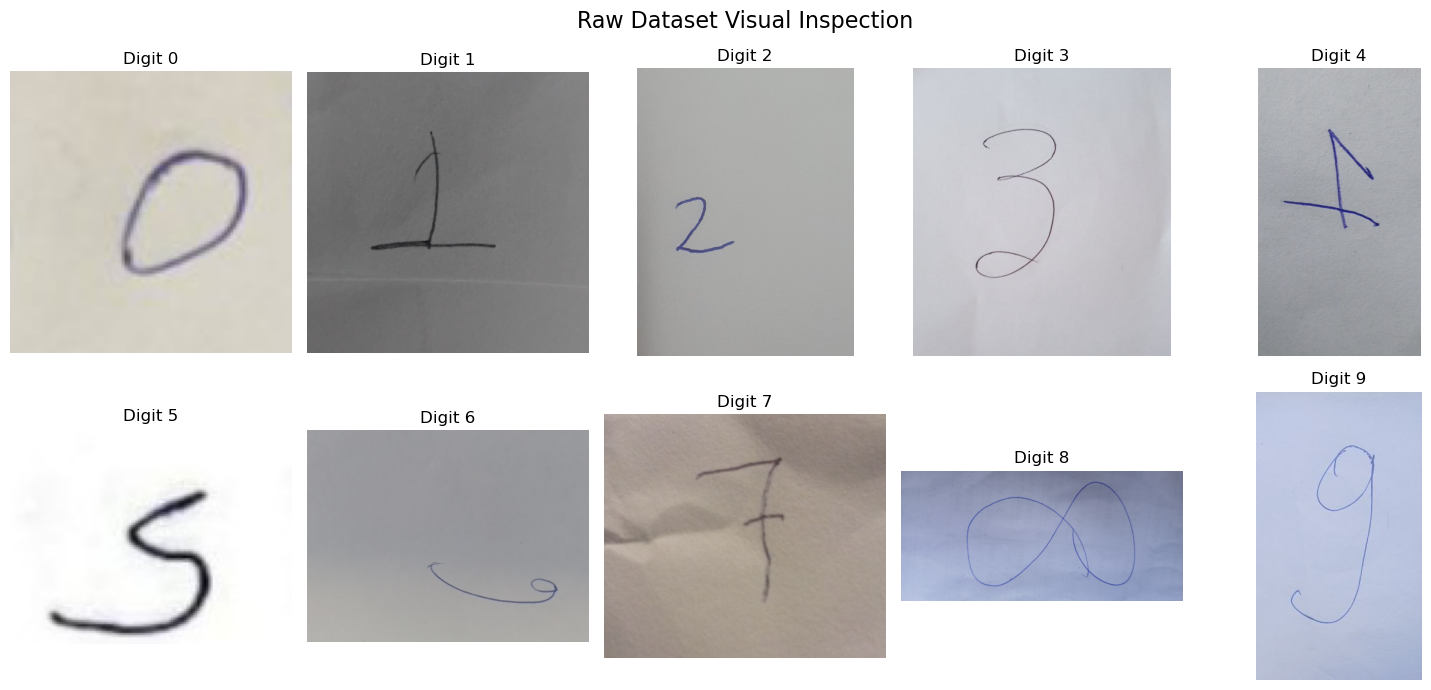

In [48]:
# ============================================
# 8. VISUAL INSPECTION
#    One example from each digit
# ============================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

for digit, ax in enumerate(axes.flat):

    folder = DATASET_DIR / str(digit)

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_file = random.choice(files)

    img = Image.open(image_file)

    ax.imshow(img)
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.suptitle(
    "Raw Dataset Visual Inspection",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [49]:
# ============================================
# 8A. CHECK EXTREME IMAGE SIZES
# ============================================

print("Smallest images:\n")

smallest_images = (
    image_info_df
    .sort_values(["width", "height"])
    [["digit", "filename", "width", "height", "mode"]]
    .head(20)
)

print(smallest_images.to_string(index=False))

print("\n" + "=" * 60)

print("Largest images:\n")

largest_images = (
    image_info_df
    .assign(pixel_count=lambda df: df["width"] * df["height"])
    .sort_values("pixel_count", ascending=False)
    [["digit", "filename", "width", "height", "mode"]]
    .head(20)
)

print(largest_images.to_string(index=False))

Smallest images:

 digit  filename  width  height mode
     5 5_007.jpg     86      66  RGB
     5 5_017.jpg     86      83  RGB
     5 5_029.jpg     86      89  RGB
     5 5_014.jpg     86      91  RGB
     5 5_011.jpg     86      99  RGB
     5 5_020.jpg     86     100  RGB
     5 5_016.jpg     86     101  RGB
     5 5_019.jpg     86     102  RGB
     5 5_018.jpg     86     112  RGB
     5 5_012.jpg     86     115  RGB
     5 5_077.jpg     89     105  RGB
     5 5_010.jpg     94      66  RGB
     5 5_078.jpg     95      80  RGB
     5 5_023.jpg     95      93  RGB
     5 5_028.jpg     96      85  RGB
     5 5_022.jpg     96      86  RGB
     0 0_050.jpg     96      96  RGB
     0 0_058.jpg     96      96  RGB
     0 0_059.jpg     96      96  RGB
     0 0_060.jpg     96      96  RGB

Largest images:

 digit  filename  width  height mode
     1 1_010.jpg   4096    3072  RGB
     1 1_009.jpg   4096    3072  RGB
     1 1_011.jpg   4096    3072  RGB
     1 1_015.jpg   3072    4096  RGB
  

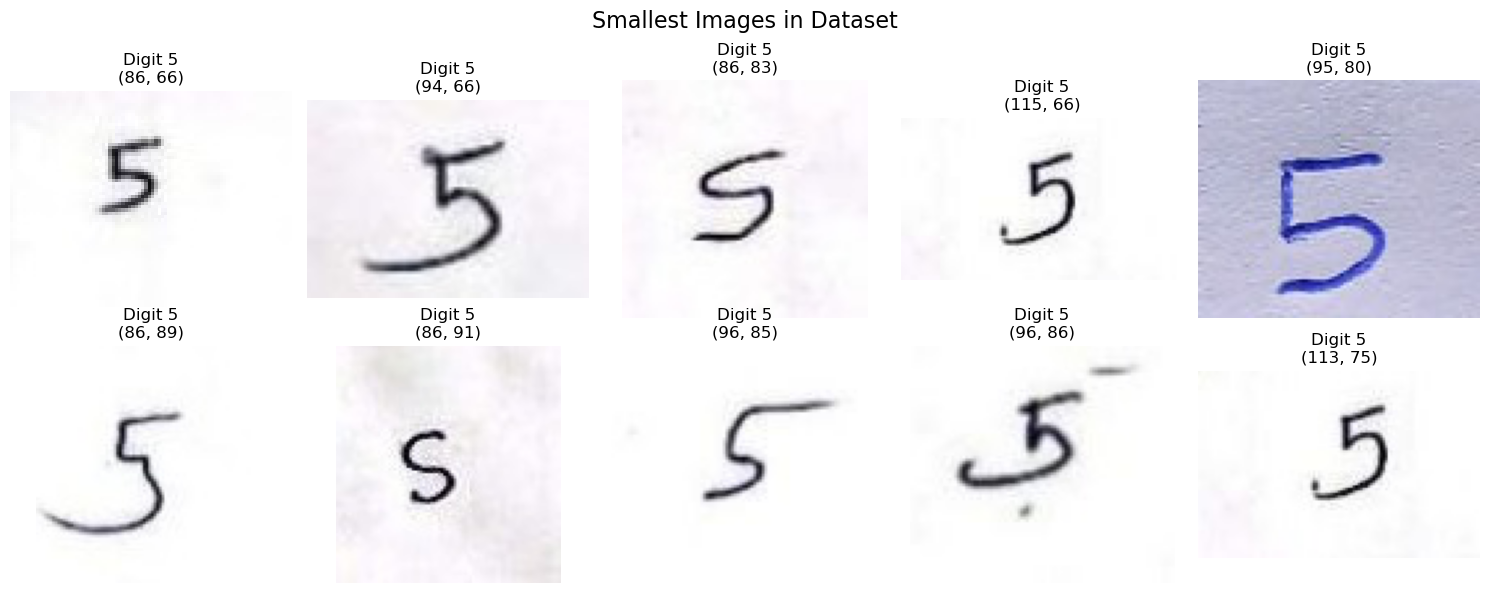

In [50]:
# ============================================
# 8B. VISUALIZE SMALLEST IMAGES
# ============================================

smallest_files = []

for digit in range(10):

    folder = DATASET_DIR / str(digit)

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for file in files:

        try:
            with Image.open(file) as img:

                width, height = img.size

                smallest_files.append(
                    (width * height, digit, file)
                )

        except:
            pass


smallest_files = sorted(smallest_files)[:10]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for ax, (pixels, digit, file) in zip(
    axes.flat,
    smallest_files
):

    img = Image.open(file)

    ax.imshow(img)
    ax.set_title(
        f"Digit {digit}\n{img.size}"
    )
    ax.axis("off")

plt.suptitle(
    "Smallest Images in Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

# STEP 9 — Inspect Multiple Images Per Class

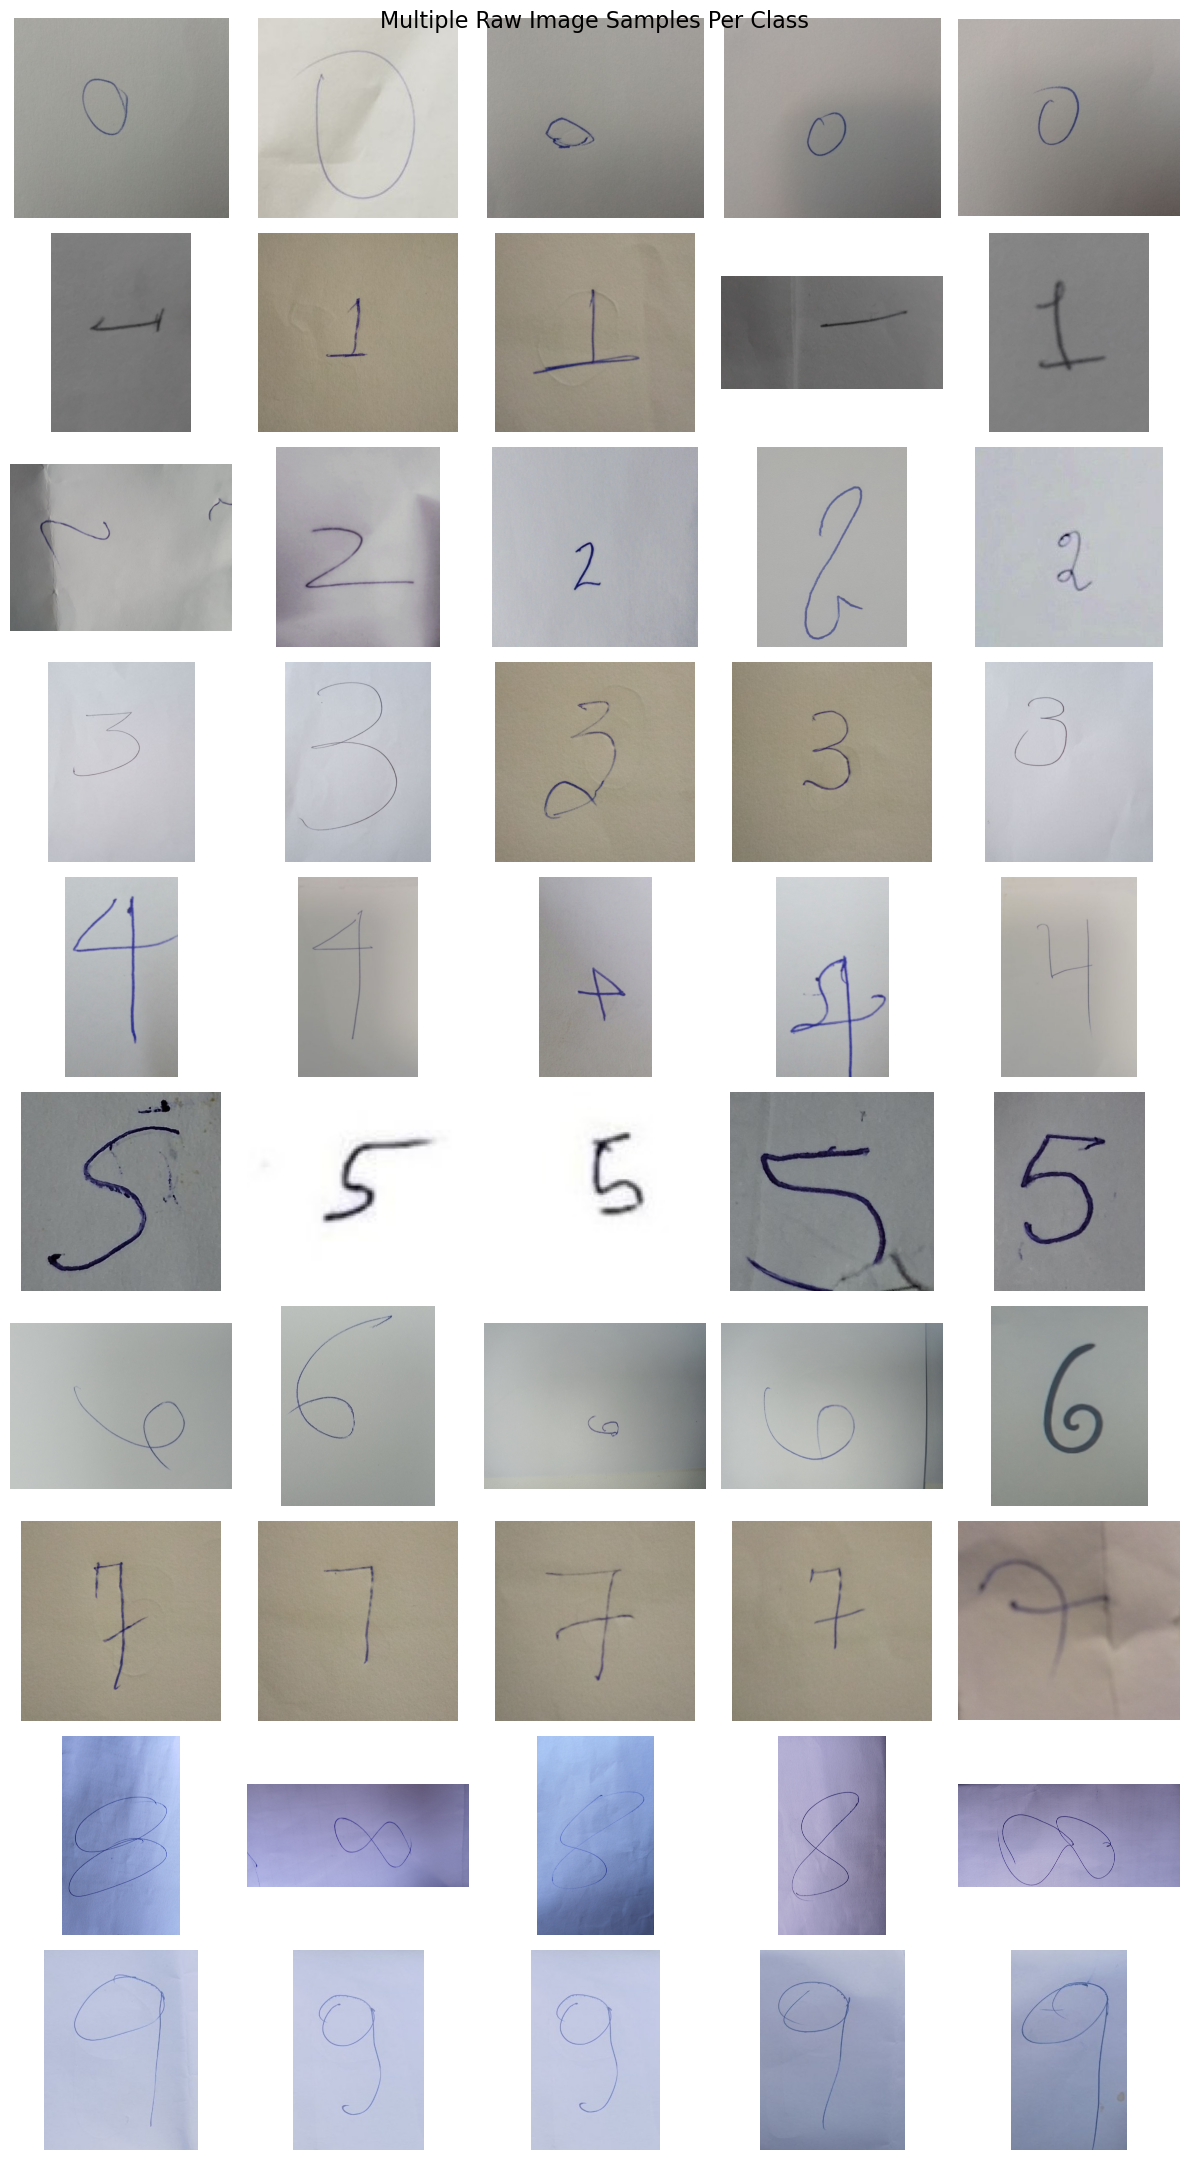

In [51]:
# ============================================
# 9. MULTI-IMAGE VISUAL INSPECTION
# ============================================

SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    10,
    SAMPLES_PER_CLASS,
    figsize=(12, 22)
)

for digit in range(10):

    folder = DATASET_DIR / str(digit)

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected_files = random.sample(
        files,
        min(SAMPLES_PER_CLASS, len(files))
    )

    for column, image_file in enumerate(selected_files):

        img = Image.open(image_file)

        axes[digit, column].imshow(img)
        axes[digit, column].axis("off")

        if column == 0:
            axes[digit, column].set_ylabel(
                f"Digit {digit}",
                fontsize=12
            )

plt.suptitle(
    "Multiple Raw Image Samples Per Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

# STEP 10 — Class Distribution Visualization

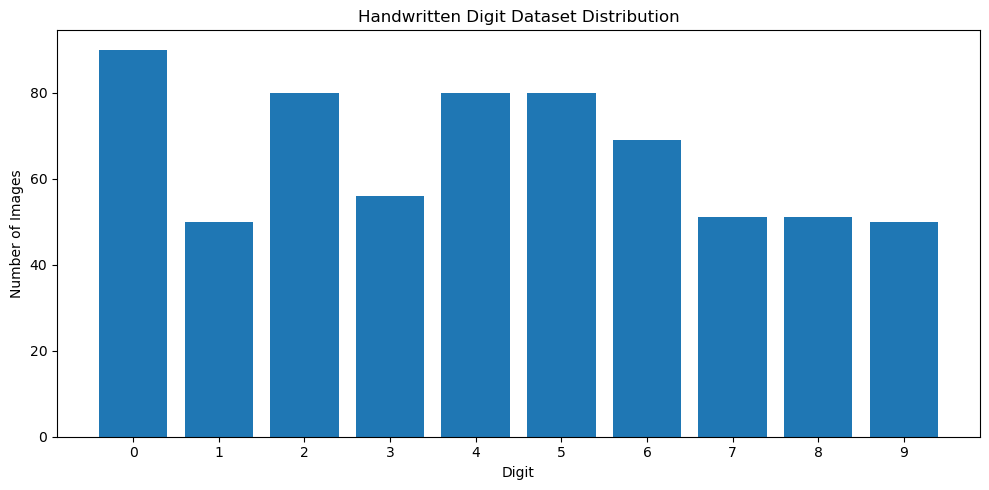

In [52]:
# ============================================
# 10. CLASS DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 5))

plt.bar(
    counts_df["Digit"].astype(str),
    counts_df["Number of Images"]
)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Handwritten Digit Dataset Distribution")

plt.tight_layout()
plt.show()

# PHASE 2 — IMAGE PREPROCESSING

## Step 11 — Create Processed Dataset Directory

##  Image Preprocessing

### The raw photographs have different resolutions and are stored in RGB format. To make them suitable for CNN training, the images will be converted to grayscale, cropped around the digit, centered, resized while preserving the aspect ratio, padded to 32×32 pixels, and normalized to the range [0,1].

In [53]:
# ============================================
# 11. PREPROCESSING CONFIGURATION
# ============================================

PROCESSED_DIR = Path("processed_dataset")

TARGET_SIZE = 32

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for digit in range(10):
    (PROCESSED_DIR / str(digit)).mkdir(
        parents=True,
        exist_ok=True
    )

print("Processed dataset directory created:")
print(PROCESSED_DIR.resolve())

Processed dataset directory created:
C:\Users\USER\Desktop\processed_dataset


## Step 12 — Understand the Preprocessing Strategy

### Before writing the function, let's define exactly what we're doing.
RAW
 ↓
GRAYSCALE
 ↓
CROP
 ↓
CENTER
 ↓
PRESERVE ASPECT RATIO
 ↓
PAD
 ↓
32 × 32

## Step 13 — Create the Preprocessing Function

In [54]:
# ============================================
# 13. IMPROVED IMAGE PREPROCESSING FUNCTION
# ============================================

import cv2
import numpy as np
from PIL import Image


def preprocess_image(image_path, target_size=32):
    """
    Preprocess a handwritten digit photograph.

    Pipeline:
        RGB
        ↓
        Grayscale
        ↓
        Contrast normalization
        ↓
        Adaptive threshold
        ↓
        Remove border-connected background
        ↓
        Locate digit
        ↓
        Crop
        ↓
        Preserve aspect ratio
        ↓
        Center
        ↓
        32x32
        ↓
        Normalize [0,1]

    Returns:
        normalized_image: float32 array of shape (32, 32)
    """

    # ----------------------------------------
    # 1. Load image
    # ----------------------------------------

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # ----------------------------------------
    # 2. Convert to grayscale
    # ----------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # ----------------------------------------
    # 3. Normalize image contrast
    # ----------------------------------------

    # CLAHE helps with mild lighting variation
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    gray = clahe.apply(gray)

    # ----------------------------------------
    # 4. Light smoothing
    # ----------------------------------------

    blurred = cv2.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    # ----------------------------------------
    # 5. Adaptive threshold
    # ----------------------------------------

    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        8
    )

    # ----------------------------------------
    # 6. Remove small noise
    # ----------------------------------------

    kernel = np.ones(
        (2, 2),
        np.uint8
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    # ----------------------------------------
    # 7. Remove objects touching image border
    # ----------------------------------------

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    cleaned = np.zeros_like(binary)

    height, width = binary.shape

    for label in range(1, num_labels):

        x, y, w, h, area = stats[label]

        touches_border = (
            x == 0 or
            y == 0 or
            x + w >= width or
            y + h >= height
        )

        # Keep reasonably sized components
        if not touches_border and area >= 8:

            cleaned[labels == label] = 255

    # ----------------------------------------
    # 8. If border removal removed everything,
    #    use original threshold
    # ----------------------------------------

    if cv2.countNonZero(cleaned) < 20:
        cleaned = binary

    # ----------------------------------------
    # 9. Find foreground coordinates
    # ----------------------------------------

    ys, xs = np.where(cleaned > 0)

    if len(xs) > 0:

        x_min = xs.min()
        x_max = xs.max()

        y_min = ys.min()
        y_max = ys.max()

        # Add small margin
        margin = 4

        x_min = max(0, x_min - margin)
        y_min = max(0, y_min - margin)

        x_max = min(
            width - 1,
            x_max + margin
        )

        y_max = min(
            height - 1,
            y_max + margin
        )

        cropped = gray[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]

    else:

        # Fallback: use original grayscale image
        cropped = gray

    # ----------------------------------------
    # 10. Resize while preserving aspect ratio
    # ----------------------------------------

    h, w = cropped.shape

    available_size = target_size - 6

    scale = min(
        available_size / w,
        available_size / h
    )

    new_w = max(
        1,
        int(round(w * scale))
    )

    new_h = max(
        1,
        int(round(h * scale))
    )

    resized = cv2.resize(
        cropped,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # ----------------------------------------
    # 11. Create white 32×32 canvas
    # ----------------------------------------

    canvas = np.full(
        (target_size, target_size),
        255,
        dtype=np.uint8
    )

    # ----------------------------------------
    # 12. Center resized digit
    # ----------------------------------------

    start_x = (
        target_size - new_w
    ) // 2

    start_y = (
        target_size - new_h
    ) // 2

    canvas[
        start_y:start_y + new_h,
        start_x:start_x + new_w
    ] = resized

    # ----------------------------------------
    # 13. Normalize to [0,1]
    # ----------------------------------------

    normalized_image = (
        canvas.astype(np.float32) / 255.0
    )

    return normalized_image

## Step 14 — Test the Preprocessing Function

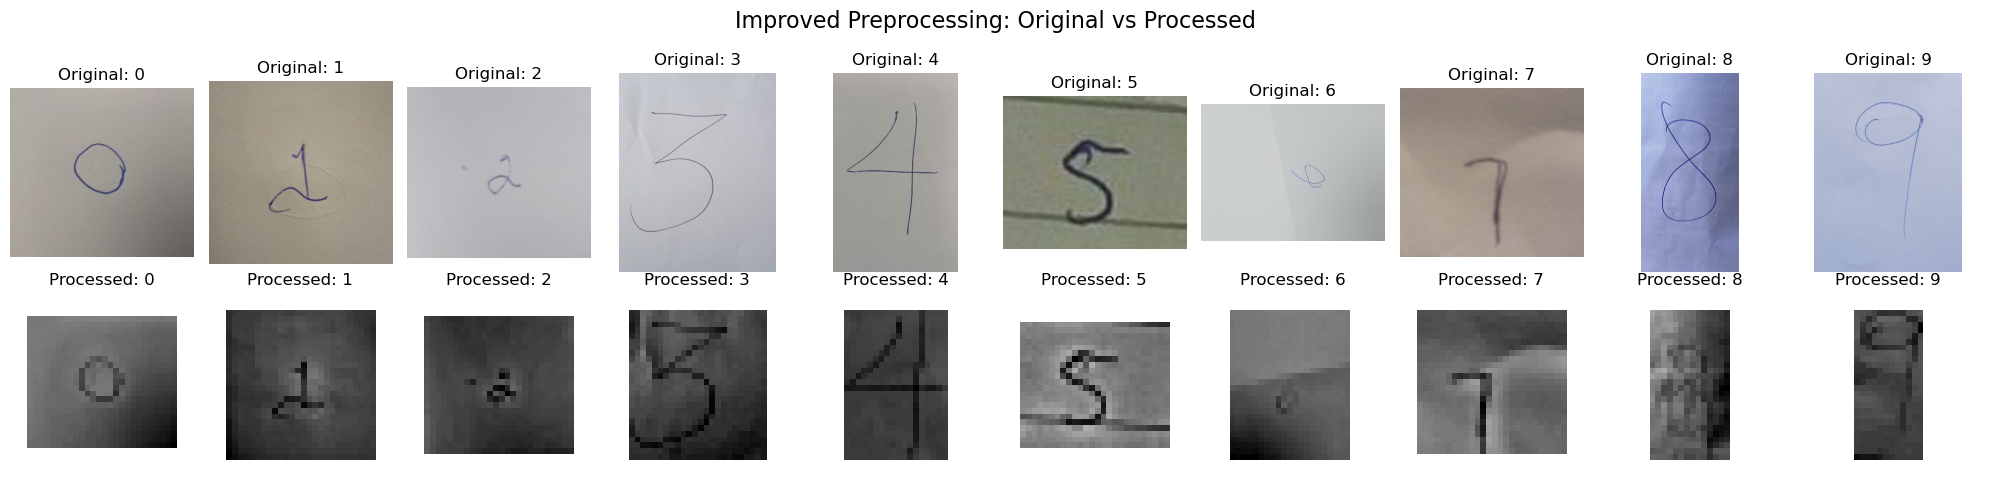

In [55]:
# ============================================
# 14. TEST IMPROVED PREPROCESSING
# ============================================

fig, axes = plt.subplots(
    2,
    10,
    figsize=(20, 5)
)

for digit in range(10):

    folder = DATASET_DIR / str(digit)

    files = [
        file for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_file = random.choice(files)

    # Original
    original = Image.open(image_file)

    axes[0, digit].imshow(original)
    axes[0, digit].set_title(
        f"Original: {digit}"
    )
    axes[0, digit].axis("off")

    # Processed
    processed = preprocess_image(
        image_file,
        TARGET_SIZE
    )

    axes[1, digit].imshow(
        processed,
        cmap="gray"
    )

    axes[1, digit].set_title(
        f"Processed: {digit}"
    )

    axes[1, digit].axis("off")

plt.suptitle(
    "Improved Preprocessing: Original vs Processed",
    fontsize=16
)

plt.tight_layout()
plt.show()

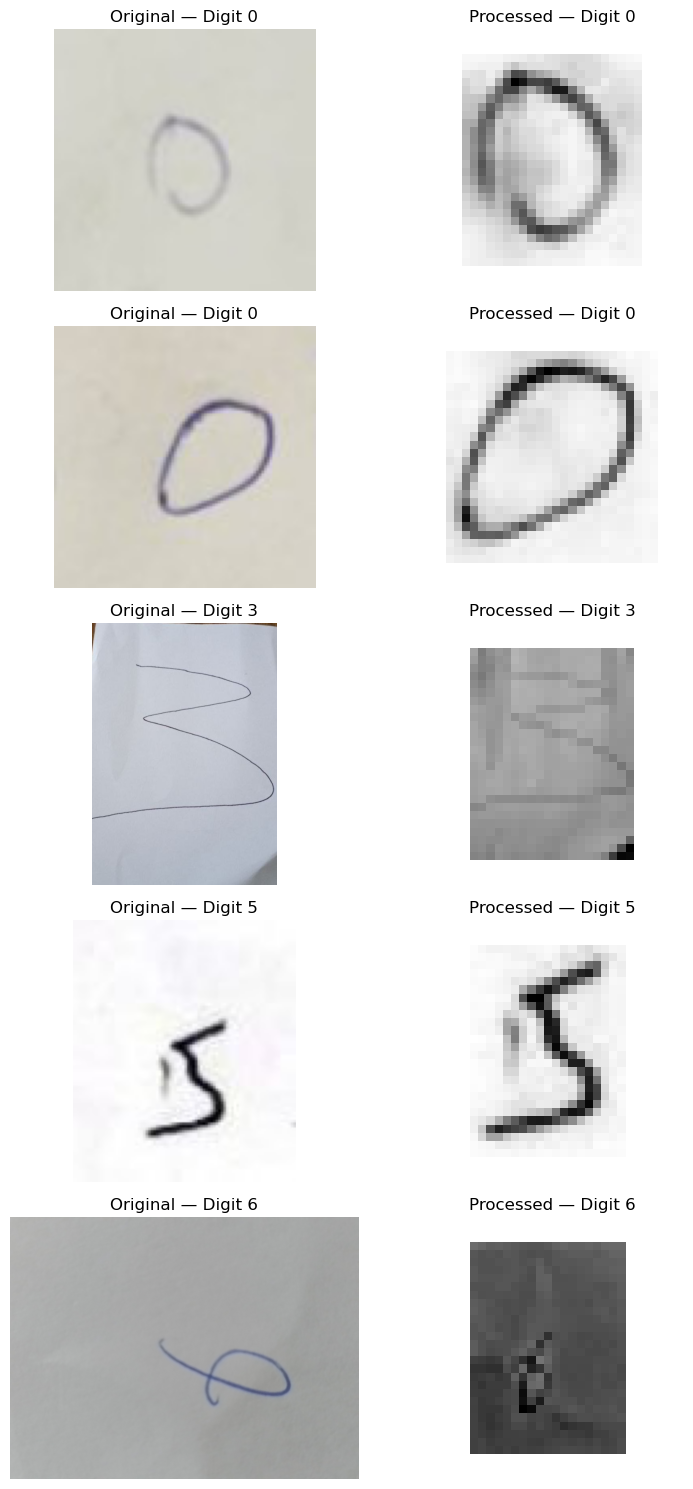

In [56]:
# ============================================
# 15. TEST DIFFICULT / EXTREME IMAGES
# ============================================

test_cases = [
    ("0", "0_050.jpg"),
    ("0", "0_090.jpg"),
    ("3", "3_001.jpg"),
    ("5", "5_016.jpg"),
    ("6", "6_003.jpg"),
]

fig, axes = plt.subplots(
    len(test_cases),
    2,
    figsize=(8, 15)
)

for row, (digit, filename) in enumerate(test_cases):

    image_path = DATASET_DIR / digit / filename

    if not image_path.exists():
        print(
            f"File not found: {image_path}"
        )
        continue

    original = Image.open(image_path)

    processed = preprocess_image(
        image_path,
        TARGET_SIZE
    )

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(
        f"Original — Digit {digit}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        processed,
        cmap="gray"
    )
    axes[row, 1].set_title(
        f"Processed — Digit {digit}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

# Step 15 — Process All Images

## 15. Apply Preprocessing to the Complete Dataset

The validated preprocessing pipeline is now applied consistently to all 657 handwritten digit photographs.

The processed images are stored as 32×32 grayscale PNG images. PNG is used to avoid additional JPEG compression artifacts during the preprocessing stage.

In [57]:
# ============================================
# 15. PREPROCESS ALL 657 IMAGES
# ============================================

processed_records = []
processing_errors = []

total_images = sum(class_counts.values())
processed_count = 0

print(f"Starting preprocessing of {total_images} images...\n")

for digit in range(10):

    input_folder = DATASET_DIR / str(digit)
    output_folder = PROCESSED_DIR / str(digit)

    files = sorted([
        file for file in input_folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in files:

        try:

            # Apply validated preprocessing
            processed_image = preprocess_image(
                image_path,
                TARGET_SIZE
            )

            # Convert [0,1] → [0,255] for PNG storage
            processed_uint8 = (
                processed_image * 255
            ).astype(np.uint8)

            # Save as PNG
            output_path = (
                output_folder /
                f"{image_path.stem}.png"
            )

            Image.fromarray(
                processed_uint8,
                mode="L"
            ).save(output_path)

            # Store metadata
            processed_records.append({
                "digit": digit,
                "original_filename": image_path.name,
                "processed_filename": output_path.name,
                "original_path": str(image_path),
                "processed_path": str(output_path),
                "width": TARGET_SIZE,
                "height": TARGET_SIZE
            })

            processed_count += 1

        except Exception as error:

            processing_errors.append({
                "digit": digit,
                "filename": image_path.name,
                "error": str(error)
            })

print("============================================")
print("PREPROCESSING COMPLETE")
print("============================================")
print(f"Original images : {total_images}")
print(f"Processed images: {processed_count}")
print(f"Errors          : {len(processing_errors)}")

Starting preprocessing of 657 images...

PREPROCESSING COMPLETE
Original images : 657
Processed images: 657
Errors          : 0


# Step 16 — Create Processing Metadata

In [59]:
# Now we save information about every processed image.

In [60]:
# ============================================
# 16. CREATE PROCESSING METADATA
# ============================================

processed_df = pd.DataFrame(
    processed_records
)

print("Processed dataset shape:")
print(processed_df.shape)

print("\nFirst five records:")
print(
    processed_df.head().to_string(index=False)
)

Processed dataset shape:
(657, 7)

First five records:
 digit original_filename processed_filename       original_path                processed_path  width  height
     0         0_001.jpg          0_001.png dataset\0\0_001.jpg processed_dataset\0\0_001.png     32      32
     0         0_002.jpg          0_002.png dataset\0\0_002.jpg processed_dataset\0\0_002.png     32      32
     0         0_003.jpg          0_003.png dataset\0\0_003.jpg processed_dataset\0\0_003.png     32      32
     0         0_004.jpg          0_004.png dataset\0\0_004.jpg processed_dataset\0\0_004.png     32      32
     0         0_005.jpg          0_005.png dataset\0\0_005.jpg processed_dataset\0\0_005.png     32      32


In [61]:
# Save preprocessing metadata
metadata_path = PROCESSED_DIR / "metadata.csv"

processed_df.to_csv(
    metadata_path,
    index=False
)

print(f"\nMetadata saved to: {metadata_path}")


Metadata saved to: processed_dataset\metadata.csv


# Step 17 — Verify Processed Image Dimensions

In [62]:
# Now we independently verify that every single processed image is 32×32

In [63]:
# ============================================
# 17. VERIFY PROCESSED IMAGE DIMENSIONS
# ============================================

processed_sizes = []
processed_modes = []
verification_errors = []

for _, row in processed_df.iterrows():

    image_path = Path(
        row["processed_path"]
    )

    try:

        with Image.open(image_path) as img:

            processed_sizes.append(img.size)
            processed_modes.append(img.mode)

    except Exception as error:

        verification_errors.append({
            "file": str(image_path),
            "error": str(error)
        })

size_counts = pd.Series(
    processed_sizes
).value_counts()

mode_counts = pd.Series(
    processed_modes
).value_counts()

print("Processed image dimensions:")
print(size_counts)

print("\nProcessed image modes:")
print(mode_counts)

print("\nVerification errors:")
print(len(verification_errors))

Processed image dimensions:
(32, 32)    657
Name: count, dtype: int64

Processed image modes:
L    657
Name: count, dtype: int64

Verification errors:
0


# Step 18 — Verify Class Counts After Processing

In [64]:
# We need to make sure preprocessing didn't accidentally lose any class

In [65]:
# ============================================
# 18. VERIFY PROCESSED CLASS DISTRIBUTION
# ============================================

processed_class_counts = (
    processed_df["digit"]
    .value_counts()
    .sort_index()
)

verification_table = pd.DataFrame({
    "Original": [
        class_counts[digit]
        for digit in range(10)
    ],
    "Processed": [
        processed_class_counts.get(
            digit,
            0
        )
        for digit in range(10)
    ]
})

verification_table.index.name = "Digit"

print(verification_table)

print("\nTotal original:",
      verification_table["Original"].sum())

print("Total processed:",
      verification_table["Processed"].sum())

       Original  Processed
Digit                     
0            90         90
1            50         50
2            80         80
3            56         56
4            80         80
5            80         80
6            69         69
7            51         51
8            51         51
9            50         50

Total original: 657
Total processed: 657


# Step 19 — Visual Quality Check of Processed Dataset

In [66]:
# Now we need to visually inspect the actual saved processed images, not just the images returned by the preprocessing function

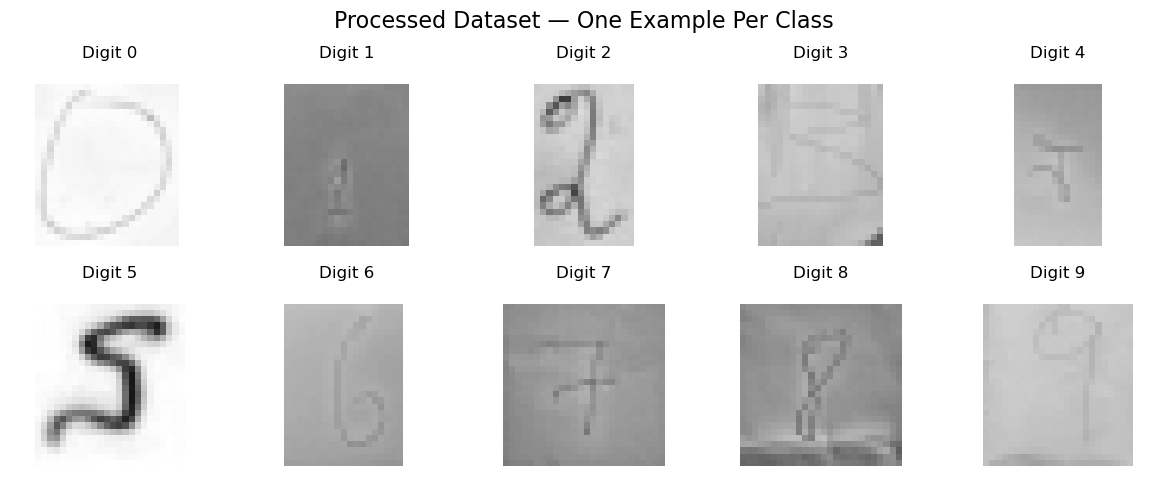

In [67]:
# ============================================
# 19. VISUALIZE PROCESSED DATASET
# ============================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for digit, ax in enumerate(axes.flat):

    class_images = processed_df[
        processed_df["digit"] == digit
    ]

    selected_row = class_images.sample(
        n=1,
        random_state=42
    ).iloc[0]

    image_path = Path(
        selected_row["processed_path"]
    )

    img = Image.open(image_path)

    ax.imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f"Digit {digit}"
    )

    ax.axis("off")

plt.suptitle(
    "Processed Dataset — One Example Per Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Step 20 — Inspect 50 Processed Images

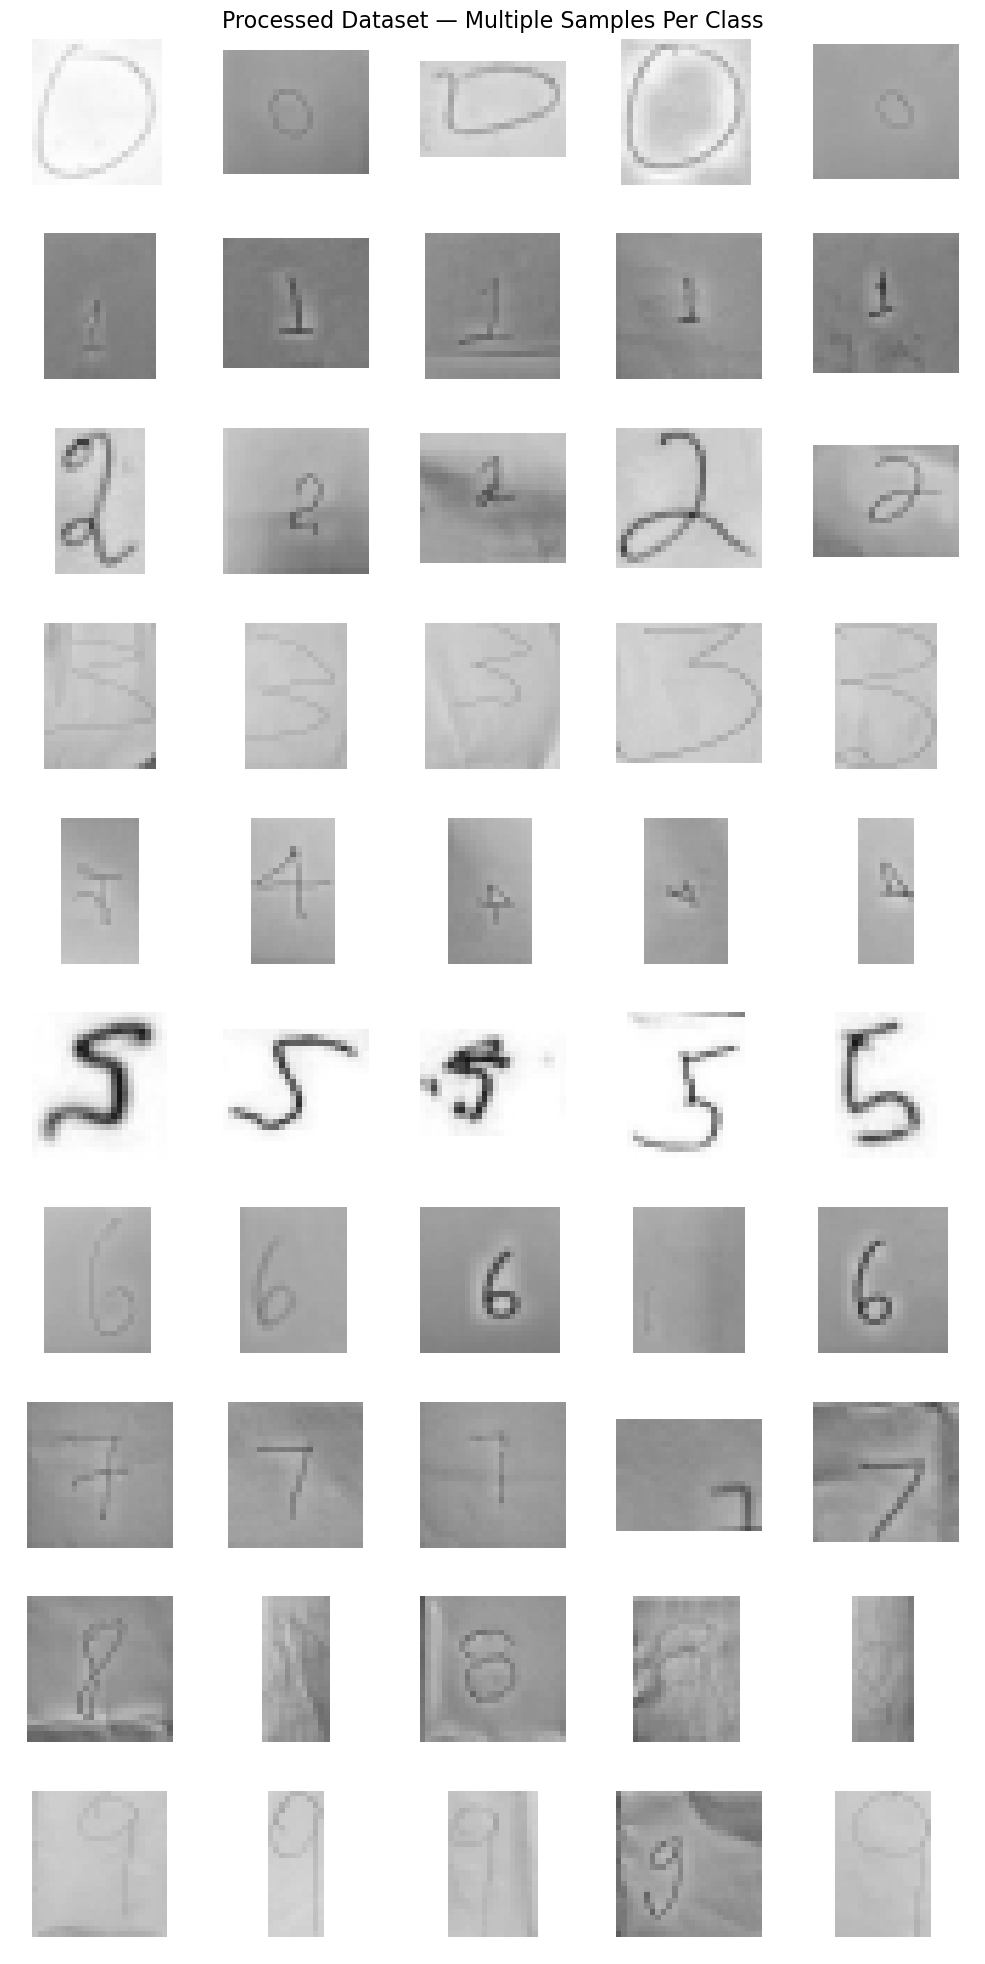

In [68]:
# ============================================
# 20. MULTI-IMAGE PROCESSED DATASET CHECK
# ============================================

SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    10,
    SAMPLES_PER_CLASS,
    figsize=(10, 20)
)

for digit in range(10):

    class_images = processed_df[
        processed_df["digit"] == digit
    ]

    selected_rows = class_images.sample(
        n=min(
            SAMPLES_PER_CLASS,
            len(class_images)
        ),
        random_state=42
    )

    for column, (_, row) in enumerate(
        selected_rows.iterrows()
    ):

        image_path = Path(
            row["processed_path"]
        )

        img = Image.open(image_path)

        axes[digit, column].imshow(
            img,
            cmap="gray",
            vmin=0,
            vmax=255
        )

        axes[digit, column].axis("off")

        if column == 0:
            axes[digit, column].set_ylabel(
                f"Digit {digit}",
                fontsize=12
            )

plt.suptitle(
    "Processed Dataset — Multiple Samples Per Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Step 21 — Load Processed Images Into X and y

### Now we move from image files to the actual machine-learning dataset.
We will create:
    X = image data
    y = digit labels

In [69]:
# ============================================
# 21. LOAD PROCESSED DATA INTO X AND y
# ============================================

X = []
y = []

for _, row in processed_df.iterrows():

    image_path = Path(
        row["processed_path"]
    )

    image = np.array(
        Image.open(image_path)
    )

    # Normalize pixel values [0,255] → [0,1]
    image = image.astype(
        np.float32
    ) / 255.0

    X.append(image)
    y.append(row["digit"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPixel minimum:", X.min())
print("Pixel maximum:", X.max())
print("Data type:", X.dtype)

X shape: (657, 32, 32)
y shape: (657,)

Pixel minimum: 0.05490196
Pixel maximum: 1.0
Data type: float32


# Step 22 — Add CNN Channel Dimension

### A CNN expects an image shape like: height × width × channels
### Since these are grayscale images: 32 × 32 × 1

In [70]:
# ============================================
# 22. ADD GRAYSCALE CHANNEL DIMENSION
# ============================================

X = np.expand_dims(
    X,
    axis=-1
)

print("X shape:", X.shape)

X shape: (657, 32, 32, 1)


# PHASE 3 — Train / Validation / Test Split

## STEP 23 — Stratified Train / Validation / Test Split

### 23. Train / Validation / Test Split

#### The processed dataset will be divided into training, validation, and test sets using stratified sampling.

#### Stratification ensures that all ten digit classes are represented proportionally in each subset.

#### The test set will remain completely untouched during model development and training.

In [71]:
# ============================================
# 24. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split


RANDOM_STATE = 42


# --------------------------------------------
# First split:
# 80% Training
# 20% Temporary
# --------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)


# --------------------------------------------
# Second split:
# 10% Validation
# 10% Test
#
# Split the temporary 20% equally.
# --------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)


print("Dataset split completed.")
print()
print(f"Training   : {len(X_train)} images")
print(f"Validation : {len(X_val)} images")
print(f"Test       : {len(X_test)} images")
print()
print(f"Total      : {len(X_train) + len(X_val) + len(X_test)} images")

Dataset split completed.

Training   : 525 images
Validation : 66 images
Test       : 66 images

Total      : 657 images


## STEP 25 — Verify Class Distribution

In [72]:
# ============================================
# 25. VERIFY CLASS DISTRIBUTION
# ============================================

train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

split_distribution.index.name = "Digit"

print(split_distribution)

print("\nColumn totals:")
print(split_distribution.sum())

       Train  Validation  Test
Digit                         
0         72           9     9
1         40           5     5
2         64           8     8
3         44           6     6
4         64           8     8
5         64           8     8
6         55           7     7
7         41           5     5
8         41           5     5
9         40           5     5

Column totals:
Train         525
Validation     66
Test           66
dtype: int64


## STEP 26 — Verify Shapes

In [73]:
# ============================================
# 26. VERIFY SPLIT SHAPES
# ============================================

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print()

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print()

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (525, 32, 32, 1)
y_train: (525,)

X_val: (66, 32, 32, 1)
y_val: (66,)

X_test: (66, 32, 32, 1)
y_test: (66,)


## STEP 27 — Visualize the Three Splits

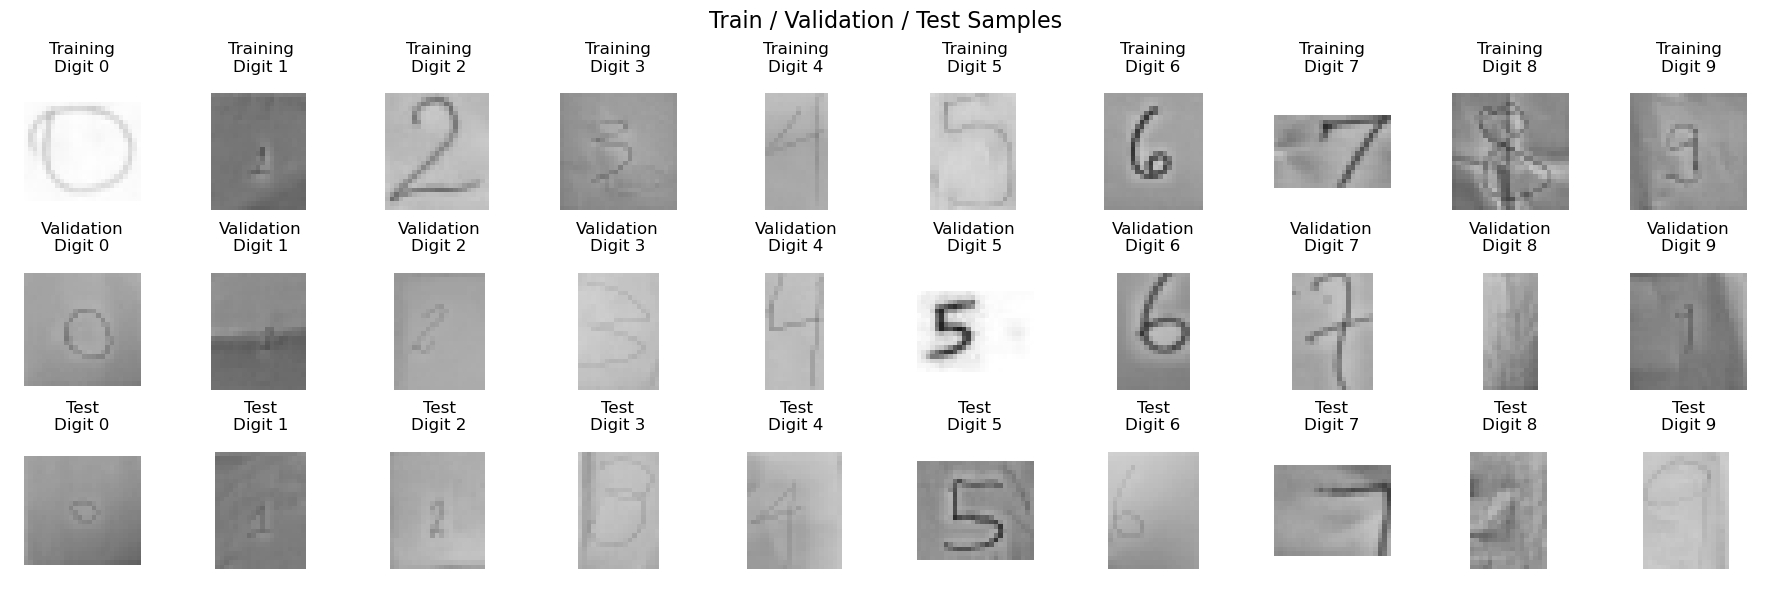

In [74]:
# ============================================
# 27. VISUALIZE TRAIN / VALIDATION / TEST
# ============================================

fig, axes = plt.subplots(
    3,
    10,
    figsize=(18, 6)
)

datasets = [
    ("Training", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]

for row, (name, X_subset, y_subset) in enumerate(datasets):

    for digit in range(10):

        indices = np.where(
            y_subset == digit
        )[0]

        selected_index = indices[0]

        axes[row, digit].imshow(
            X_subset[selected_index].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row, digit].set_title(
            f"{name}\nDigit {digit}"
        )

        axes[row, digit].axis("off")

plt.suptitle(
    "Train / Validation / Test Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

## STEP 28 — Check for Data Leakage

In [75]:
# ============================================
# 28. CHECK FOR EXACT IMAGE DUPLICATES
# ============================================

def image_hashes(images):
    """
    Create a hash for every image.
    """
    import hashlib

    hashes = []

    for image in images:
        image_bytes = image.tobytes()

        image_hash = hashlib.md5(
            image_bytes
        ).hexdigest()

        hashes.append(image_hash)

    return set(hashes)


train_hashes = image_hashes(X_train)
val_hashes = image_hashes(X_val)
test_hashes = image_hashes(X_test)


train_val_overlap = (
    train_hashes &
    val_hashes
)

train_test_overlap = (
    train_hashes &
    test_hashes
)

val_test_overlap = (
    val_hashes &
    test_hashes
)


print("Train ↔ Validation duplicates:",
      len(train_val_overlap))

print("Train ↔ Test duplicates:",
      len(train_test_overlap))

print("Validation ↔ Test duplicates:",
      len(val_test_overlap))

Train ↔ Validation duplicates: 1
Train ↔ Test duplicates: 1
Validation ↔ Test duplicates: 0


## Step 29 — Identify the Duplicate Images

In [76]:
# ============================================
# 29. IDENTIFY CROSS-SPLIT DUPLICATES
# ============================================

import hashlib


def create_hash_map(X_data, y_data):
    """
    Create a mapping:
        image_hash -> list of indices
    """

    hash_map = {}

    for index, image in enumerate(X_data):

        image_hash = hashlib.md5(
            image.tobytes()
        ).hexdigest()

        if image_hash not in hash_map:
            hash_map[image_hash] = []

        hash_map[image_hash].append(index)

    return hash_map


train_hash_map = create_hash_map(
    X_train,
    y_train
)

val_hash_map = create_hash_map(
    X_val,
    y_val
)

test_hash_map = create_hash_map(
    X_test,
    y_test
)


# --------------------------------------------
# Find Train ↔ Validation duplicates
# --------------------------------------------

train_val_duplicates = (
    set(train_hash_map.keys())
    &
    set(val_hash_map.keys())
)


# --------------------------------------------
# Find Train ↔ Test duplicates
# --------------------------------------------

train_test_duplicates = (
    set(train_hash_map.keys())
    &
    set(test_hash_map.keys())
)


# --------------------------------------------
# Print results
# --------------------------------------------

print("Train ↔ Validation duplicate hashes:")
print(train_val_duplicates)

print("\nTrain ↔ Test duplicate hashes:")
print(train_test_duplicates)

Train ↔ Validation duplicate hashes:
{'806b078afc6276ee18d2c5a793698b07'}

Train ↔ Test duplicate hashes:
{'e02bac41bb3ddeb62253d7b0a97ff5ce'}


## Step 30 — Find the Original Filenames

In [77]:
# Because X_train, X_val, and X_test were created from processed_df, we can trace those duplicates back to their original photographs.

In [78]:
# ============================================
# 30. TRACE DUPLICATES BACK TO ORIGINAL FILES
# ============================================

# Recreate the same indices used during the split
# using the original dataset indices.

all_indices = np.arange(len(X))

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y[temp_indices]
)


def get_hash(image):
    return hashlib.md5(
        image.tobytes()
    ).hexdigest()


# --------------------------------------------
# Create detailed records
# --------------------------------------------

train_hash_records = {}

for local_idx, original_idx in enumerate(train_indices):

    image_hash = get_hash(
        X_train[local_idx]
    )

    train_hash_records[image_hash] = {
        "split": "Train",
        "original_index": original_idx,
        "digit": y_train[local_idx],
        "filename": processed_df.iloc[
            original_idx
        ]["original_filename"],
        "processed_filename": processed_df.iloc[
            original_idx
        ]["processed_filename"]
    }


val_hash_records = {}

for local_idx, original_idx in enumerate(val_indices):

    image_hash = get_hash(
        X_val[local_idx]
    )

    val_hash_records[image_hash] = {
        "split": "Validation",
        "original_index": original_idx,
        "digit": y_val[local_idx],
        "filename": processed_df.iloc[
            original_idx
        ]["original_filename"],
        "processed_filename": processed_df.iloc[
            original_idx
        ]["processed_filename"]
    }


test_hash_records = {}

for local_idx, original_idx in enumerate(test_indices):

    image_hash = get_hash(
        X_test[local_idx]
    )

    test_hash_records[image_hash] = {
        "split": "Test",
        "original_index": original_idx,
        "digit": y_test[local_idx],
        "filename": processed_df.iloc[
            original_idx
        ]["original_filename"],
        "processed_filename": processed_df.iloc[
            original_idx
        ]["processed_filename"]
    }


# --------------------------------------------
# Print Train ↔ Validation duplicates
# --------------------------------------------

print("=" * 60)
print("TRAIN ↔ VALIDATION DUPLICATES")
print("=" * 60)

for image_hash in train_val_duplicates:

    print("\nTrain:")
    print(train_hash_records[image_hash])

    print("\nValidation:")
    print(val_hash_records[image_hash])


# --------------------------------------------
# Print Train ↔ Test duplicates
# --------------------------------------------

print("\n" + "=" * 60)
print("TRAIN ↔ TEST DUPLICATES")
print("=" * 60)

for image_hash in train_test_duplicates:

    print("\nTrain:")
    print(train_hash_records[image_hash])

    print("\nTest:")
    print(test_hash_records[image_hash])

TRAIN ↔ VALIDATION DUPLICATES

Train:
{'split': 'Train', 'original_index': np.int64(180), 'digit': np.int64(2), 'filename': '2_041.jpg', 'processed_filename': '2_041.png'}

Validation:
{'split': 'Validation', 'original_index': np.int64(201), 'digit': np.int64(2), 'filename': '2_062.jpg', 'processed_filename': '2_062.png'}

TRAIN ↔ TEST DUPLICATES

Train:
{'split': 'Train', 'original_index': np.int64(134), 'digit': np.int64(1), 'filename': '1_045.jpg', 'processed_filename': '1_045.png'}

Test:
{'split': 'Test', 'original_index': np.int64(133), 'digit': np.int64(1), 'filename': '1_044.jpg', 'processed_filename': '1_044.png'}


### Step 31 — Visualize the Duplicate Pairs

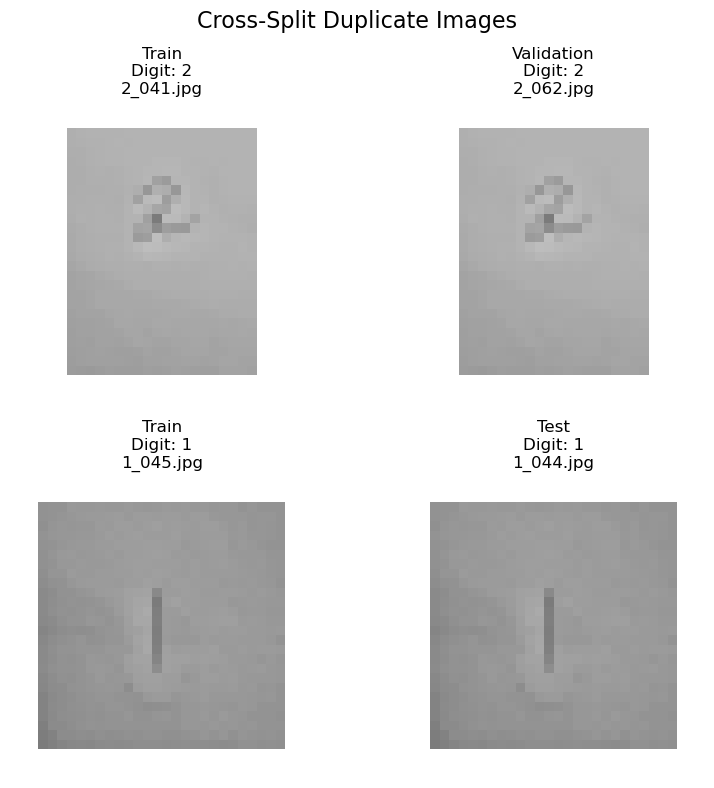

In [79]:
# ============================================
# 31. VISUALIZE CROSS-SPLIT DUPLICATES
# ============================================

duplicate_pairs = []

for image_hash in train_val_duplicates:

    duplicate_pairs.append(
        (
            "Train",
            train_hash_records[image_hash],
            "Validation",
            val_hash_records[image_hash]
        )
    )

for image_hash in train_test_duplicates:

    duplicate_pairs.append(
        (
            "Train",
            train_hash_records[image_hash],
            "Test",
            test_hash_records[image_hash]
        )
    )


fig, axes = plt.subplots(
    len(duplicate_pairs),
    2,
    figsize=(8, 4 * len(duplicate_pairs))
)

if len(duplicate_pairs) == 1:
    axes = np.array([axes])

for row, (
    split_a,
    record_a,
    split_b,
    record_b
) in enumerate(duplicate_pairs):

    idx_a = record_a["original_index"]
    idx_b = record_b["original_index"]

    image_a = X[idx_a].squeeze()
    image_b = X[idx_b].squeeze()

    axes[row, 0].imshow(
        image_a,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 0].set_title(
        f"{split_a}\n"
        f"Digit: {record_a['digit']}\n"
        f"{record_a['filename']}"
    )

    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        image_b,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        f"{split_b}\n"
        f"Digit: {record_b['digit']}\n"
        f"{record_b['filename']}"
    )

    axes[row, 1].axis("off")

plt.suptitle(
    "Cross-Split Duplicate Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

# STEP 32 — Repair the Data Split

## 32. Repair Cross-Split Duplicate Leakage

### Exact duplicate representations were detected across the training, validation, and test sets after preprocessing.

### Instead of deleting valid images, the affected samples are reassigned within their digit class so that duplicate representations cannot occur across different subsets.

### The total dataset size and class distribution are preserved.

In [80]:
# ============================================
# 32. REPAIR CROSS-SPLIT DUPLICATE LEAKAGE
# ============================================

import hashlib
import numpy as np


# --------------------------------------------
# Helper function
# --------------------------------------------

def get_image_hash(image):
    return hashlib.md5(
        image.tobytes()
    ).hexdigest()


# --------------------------------------------
# Recreate global indices for the split
# --------------------------------------------

all_indices = np.arange(len(X))

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y[temp_indices]
)


# Convert to lists so we can swap elements
train_indices = list(train_indices)
val_indices = list(val_indices)
test_indices = list(test_indices)


# --------------------------------------------
# Calculate hash for every image
# --------------------------------------------

global_hashes = {}

for index in range(len(X)):

    image_hash = get_image_hash(X[index])

    if image_hash not in global_hashes:
        global_hashes[image_hash] = []

    global_hashes[image_hash].append(index)


# --------------------------------------------
# Find duplicate groups
# --------------------------------------------

duplicate_groups = {
    image_hash: indices
    for image_hash, indices in global_hashes.items()
    if len(indices) > 1
}


print("Duplicate groups found:")
print(len(duplicate_groups))

for image_hash, indices in duplicate_groups.items():

    print(
        "\nHash:",
        image_hash
    )

    for index in indices:

        print(
            "Index:",
            index,
            "| Digit:",
            y[index],
            "| File:",
            processed_df.iloc[index]["original_filename"]
        )


# --------------------------------------------
# Repair function
# --------------------------------------------

def repair_split(
    source_indices,
    destination_indices,
    source_name,
    destination_name
):

    for group_hash, group_indices in duplicate_groups.items():

        source_members = [
            index
            for index in group_indices
            if index in source_indices
        ]

        destination_members = [
            index
            for index in group_indices
            if index in destination_indices
        ]

        # No cross-split duplicate
        if not source_members or not destination_members:
            continue

        destination_index = destination_members[0]

        digit = y[destination_index]

        # Find a source sample from the SAME digit
        # whose representation is globally unique.
        candidates = [
            index
            for index in source_indices
            if y[index] == digit
            and len(global_hashes[
                get_image_hash(X[index])
            ]) == 1
        ]

        if len(candidates) == 0:

            raise RuntimeError(
                f"Could not find a safe replacement "
                f"for digit {digit}."
            )

        replacement_index = candidates[0]

        # Replace destination sample with
        # the safe source sample
        destination_position = destination_indices.index(
            destination_index
        )

        source_position = source_indices.index(
            replacement_index
        )

        destination_indices[destination_position] = (
            replacement_index
        )

        # Put the problematic destination sample
        # into the source split.
        source_indices[source_position] = (
            destination_index
        )

        print(
            f"\nRepaired {source_name} ↔ "
            f"{destination_name}"
        )

        print(
            f"Moved {processed_df.iloc[destination_index]['original_filename']} "
            f"from {destination_name} → {source_name}"
        )

        print(
            f"Moved {processed_df.iloc[replacement_index]['original_filename']} "
            f"from {source_name} → {destination_name}"
        )


# --------------------------------------------
# Repair Train ↔ Validation
# --------------------------------------------

repair_split(
    train_indices,
    val_indices,
    "Train",
    "Validation"
)


# --------------------------------------------
# Repair Train ↔ Test
# --------------------------------------------

repair_split(
    train_indices,
    test_indices,
    "Train",
    "Test"
)


print("\n============================================")
print("DUPLICATE LEAKAGE REPAIR COMPLETE")
print("============================================")

Duplicate groups found:
3

Hash: e02bac41bb3ddeb62253d7b0a97ff5ce
Index: 133 | Digit: 1 | File: 1_044.jpg
Index: 134 | Digit: 1 | File: 1_045.jpg

Hash: 806b078afc6276ee18d2c5a793698b07
Index: 180 | Digit: 2 | File: 2_041.jpg
Index: 201 | Digit: 2 | File: 2_062.jpg

Hash: 5f225bcbcc57656f8d5d3b899de1ce2a
Index: 603 | Digit: 8 | File: 8_048.jpg
Index: 604 | Digit: 8 | File: 8_049.jpg

Repaired Train ↔ Validation
Moved 2_062.jpg from Validation → Train
Moved 2_038.jpg from Train → Validation

Repaired Train ↔ Test
Moved 1_044.jpg from Test → Train
Moved 1_026.jpg from Train → Test

DUPLICATE LEAKAGE REPAIR COMPLETE


# STEP 33 — Rebuild X/y From the Repaired Split

In [81]:
# ============================================
# 33. REBUILD TRAIN / VALIDATION / TEST SETS
# ============================================

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[val_indices]
y_val = y[val_indices]

X_test = X[test_indices]
y_test = y[test_indices]


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print()

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print()

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print()

print(
    "Total:",
    len(X_train) +
    len(X_val) +
    len(X_test)
)

X_train: (525, 32, 32, 1)
y_train: (525,)

X_val: (66, 32, 32, 1)
y_val: (66,)

X_test: (66, 32, 32, 1)
y_test: (66,)

Total: 657


# Step 34 — Verify Class Distribution Again

In [82]:
# ============================================
# 34. VERIFY CLASS DISTRIBUTION AFTER REPAIR
# ============================================

train_counts = pd.Series(
    y_train
).value_counts().sort_index()

val_counts = pd.Series(
    y_val
).value_counts().sort_index()

test_counts = pd.Series(
    y_test
).value_counts().sort_index()


split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

split_distribution.index.name = "Digit"

print(split_distribution)

print("\nColumn totals:")
print(split_distribution.sum())

       Train  Validation  Test
Digit                         
0         72           9     9
1         40           5     5
2         64           8     8
3         44           6     6
4         64           8     8
5         64           8     8
6         55           7     7
7         41           5     5
8         41           5     5
9         40           5     5

Column totals:
Train         525
Validation     66
Test           66
dtype: int64


# Step 35 — Run the Duplicate Check Again

In [83]:
# ============================================
# 35. FINAL CROSS-SPLIT DUPLICATE CHECK
# ============================================

def get_hash_set(images):

    hashes = set()

    for image in images:

        hashes.add(
            get_image_hash(image)
        )

    return hashes


train_hashes = get_hash_set(X_train)
val_hashes = get_hash_set(X_val)
test_hashes = get_hash_set(X_test)


train_val_overlap = (
    train_hashes &
    val_hashes
)

train_test_overlap = (
    train_hashes &
    test_hashes
)

val_test_overlap = (
    val_hashes &
    test_hashes
)


print(
    "Train ↔ Validation duplicates:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test duplicates:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test duplicates:",
    len(val_test_overlap)
)

Train ↔ Validation duplicates: 0
Train ↔ Test duplicates: 0
Validation ↔ Test duplicates: 0


# Step 36 — Verify Dataset Integrity

In [84]:
# ============================================
# 36. FINAL SPLIT INTEGRITY CHECK
# ============================================

print("============================================")
print("FINAL DATASET INTEGRITY CHECK")
print("============================================")

print(
    "Training images   :",
    len(X_train)
)

print(
    "Validation images :",
    len(X_val)
)

print(
    "Test images       :",
    len(X_test)
)

print(
    "Total images      :",
    len(X_train) +
    len(X_val) +
    len(X_test)
)

print()

print(
    "Training shape    :",
    X_train.shape
)

print(
    "Validation shape  :",
    X_val.shape
)

print(
    "Test shape        :",
    X_test.shape
)

print()

print(
    "Number of classes :",
    len(np.unique(y))
)

print(
    "Class labels      :",
    np.unique(y)
)

FINAL DATASET INTEGRITY CHECK
Training images   : 525
Validation images : 66
Test images       : 66
Total images      : 657

Training shape    : (525, 32, 32, 1)
Validation shape  : (66, 32, 32, 1)
Test shape        : (66, 32, 32, 1)

Number of classes : 10
Class labels      : [0 1 2 3 4 5 6 7 8 9]


# PHASE 4 — DATA AUGMENTATION

## Step 37 — Define the Augmentation Strategy

## 37. Data Augmentation Strategy

#### Data augmentation is applied only to the training dataset.

#### Because the dataset contains handwritten digits, augmentation will simulate realistic variations in handwriting and image capture while preserving the digit's identity.

#### The following transformations are used conservatively:

- Small rotations
- Small horizontal and vertical shifts
- Small zoom variations
- Small shear transformations
- Mild brightness variation

#### Horizontal and vertical flipping are NOT used because flipping a handwritten digit can change its meaning or create unrealistic samples.

#### Validation and test images remain completely untouched.

## Step 38 — Import TensorFlow / Keras

In [88]:
# ============================================
# 38. IMPORT TENSORFLOW / KERAS
# ============================================

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 39 — Create Training Augmentation Generator

In [89]:
# ============================================
# 39. TRAINING DATA AUGMENTATION
# ============================================

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.05,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)

print("Training augmentation pipeline created.")

Training augmentation pipeline created.


## Step 40 — Create Training Generator

In [90]:
# Now we connect the augmentation pipeline to our training data.

In [91]:
# ============================================
# 40. CREATE AUGMENTED TRAINING GENERATOR
# ============================================

BATCH_SIZE = 32

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE
)

print("Training generator created.")
print("Batch size:", BATCH_SIZE)

Training generator created.
Batch size: 32


## Step 41 — Verify the Generator

In [92]:
# ============================================
# 41. VERIFY AUGMENTED BATCH
# ============================================

augmented_images, augmented_labels = next(
    train_generator
)

print("Augmented image batch shape:")
print(augmented_images.shape)

print()

print("Augmented label batch shape:")
print(augmented_labels.shape)

print()

print("Pixel minimum:",
      augmented_images.min())

print("Pixel maximum:",
      augmented_images.max())

Augmented image batch shape:
(32, 32, 32, 1)

Augmented label batch shape:
(32,)

Pixel minimum: 0.0
Pixel maximum: 1.0


## Step 42 — Visualize Augmented Images

In [93]:
# Before training the CNN, we need to make sure augmentation isn't destroying the handwriting.

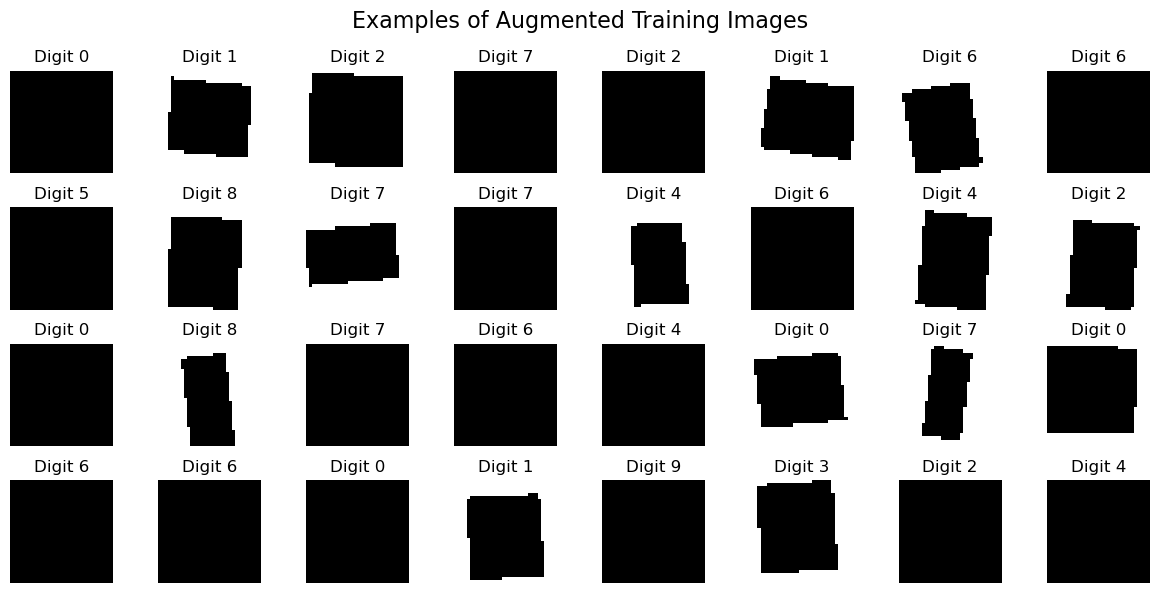

In [94]:
# ============================================
# 42. VISUALIZE AUGMENTED TRAINING IMAGES
# ============================================

fig, axes = plt.subplots(
    4,
    8,
    figsize=(12, 6)
)

for index, ax in enumerate(axes.flat):

    ax.imshow(
        augmented_images[index].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Digit {augmented_labels[index]}"
    )

    ax.axis("off")

plt.suptitle(
    "Examples of Augmented Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 43 — Compare Original vs Augmented

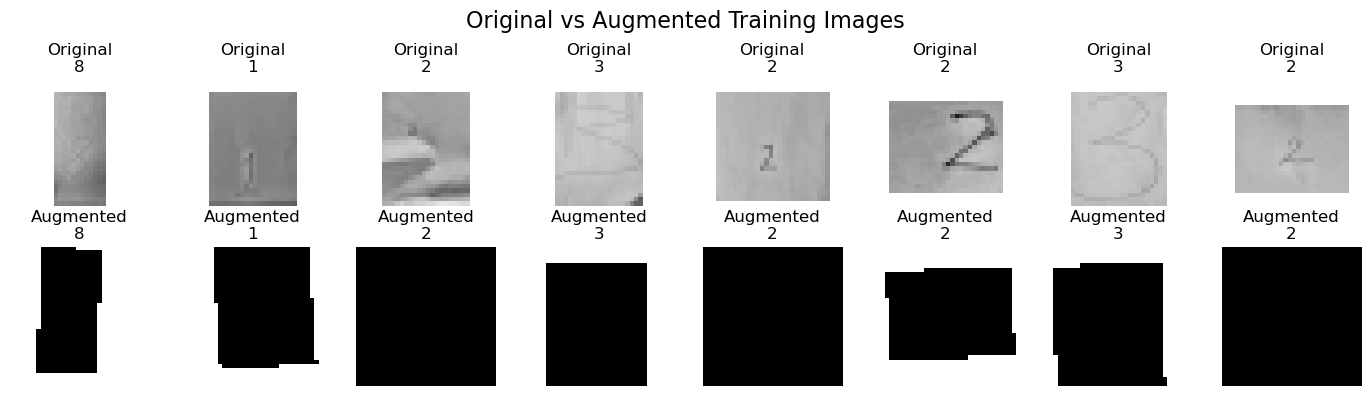

In [95]:
# ============================================
# 41. ORIGINAL VS AUGMENTED
# ============================================

sample_indices = np.random.choice(
    len(X_train),
    size=8,
    replace=False
)

fig, axes = plt.subplots(
    2,
    8,
    figsize=(14, 4)
)

for column, index in enumerate(sample_indices):

    # Original
    axes[0, column].imshow(
        X_train[index].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0, column].set_title(
        f"Original\n{y_train[index]}"
    )

    axes[0, column].axis("off")


# Generate augmented versions
sample_images = X_train[
    sample_indices
]

sample_labels = y_train[
    sample_indices
]

augmented_sample = train_datagen.flow(
    sample_images,
    sample_labels,
    batch_size=8,
    shuffle=False,
    seed=RANDOM_STATE
)

aug_images, aug_labels = next(
    augmented_sample
)


for column in range(8):

    axes[1, column].imshow(
        aug_images[column].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1, column].set_title(
        f"Augmented\n{aug_labels[column]}"
    )

    axes[1, column].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Augmented",
    fontsize=12
)

plt.suptitle(
    "Original vs Augmented Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 44 — Diagnose the Augmentation

In [96]:
# ============================================
# 44. DIAGNOSE AUGMENTATION VALUES
# ============================================

import numpy as np

print("ORIGINAL TRAINING DATA")
print("--------------------------------------------")

print("Shape:", X_train.shape)
print("Data type:", X_train.dtype)
print("Min:", X_train.min())
print("Max:", X_train.max())
print("Mean:", X_train.mean())
print("Median:", np.median(X_train))


print("\nAUGMENTED BATCH")
print("--------------------------------------------")

print("Shape:", augmented_images.shape)
print("Data type:", augmented_images.dtype)
print("Min:", augmented_images.min())
print("Max:", augmented_images.max())
print("Mean:", augmented_images.mean())
print("Median:", np.median(augmented_images))


print("\nSELECTED IMAGE COMPARISON")
print("--------------------------------------------")

for i in range(5):

    print(f"\nImage {i}")

    print(
        "Original mean:",
        X_train[i].mean()
    )

    print(
        "Augmented mean:",
        augmented_images[i].mean()
    )

    print(
        "Original min/max:",
        X_train[i].min(),
        X_train[i].max()
    )

    print(
        "Augmented min/max:",
        augmented_images[i].min(),
        augmented_images[i].max()
    )

ORIGINAL TRAINING DATA
--------------------------------------------
Shape: (525, 32, 32, 1)
Data type: float32
Min: 0.05490196
Max: 1.0
Mean: 0.82369345
Median: 0.972549

AUGMENTED BATCH
--------------------------------------------
Shape: (32, 32, 32, 1)
Data type: float32
Min: 0.0
Max: 1.0
Mean: 0.20913696
Median: 0.0

SELECTED IMAGE COMPARISON
--------------------------------------------

Image 0
Original mean: 0.7283548
Augmented mean: 0.0
Original min/max: 0.45882353 1.0
Augmented min/max: 0.0 0.0

Image 1
Original mean: 0.86863124
Augmented mean: 0.4453125
Original min/max: 0.67058825 1.0
Augmented min/max: 0.0 1.0

Image 2
Original mean: 0.9761298
Augmented mean: 0.20703125
Original min/max: 0.76862746 1.0
Augmented min/max: 0.0 1.0

Image 3
Original mean: 0.88293505
Augmented mean: 0.0
Original min/max: 0.53333336 1.0
Augmented min/max: 0.0 0.0

Image 4
Original mean: 0.74268156
Augmented mean: 0.0
Original min/max: 0.4 1.0
Augmented min/max: 0.0 0.0


## Step 45 — Check What the Augmentation Actually Did

In [97]:
# ============================================
# 45. CHECK AUGMENTED IMAGE VALUE DISTRIBUTION
# ============================================

print("ORIGINAL PIXEL DISTRIBUTION")
print("--------------------------------------------")

print(
    np.percentile(
        X_train,
        [0, 1, 5, 25, 50, 75, 95, 99, 100]
    )
)


print("\nAUGMENTED PIXEL DISTRIBUTION")
print("--------------------------------------------")

print(
    np.percentile(
        augmented_images,
        [0, 1, 5, 25, 50, 75, 95, 99, 100]
    )
)

ORIGINAL PIXEL DISTRIBUTION
--------------------------------------------
[0.05490196 0.41568628 0.50588238 0.63529414 0.97254902 1.
 1.         1.         1.        ]

AUGMENTED PIXEL DISTRIBUTION
--------------------------------------------
[0. 0. 0. 0. 0. 0. 1. 1. 1.]


## Step 46 — Test a Simple Augmentation

In [98]:
#Before using the full augmentation pipeline, let's test rotation only.

In [99]:
# ============================================
# 46. TEST ROTATION ONLY
# ============================================

rotation_datagen = ImageDataGenerator(
    rotation_range=10,
    fill_mode="nearest"
)


rotation_generator = rotation_datagen.flow(
    X_train[:8],
    y_train[:8],
    batch_size=8,
    shuffle=False,
    seed=RANDOM_STATE
)


rotation_images, rotation_labels = next(
    rotation_generator
)


print("Rotation-only shape:")
print(rotation_images.shape)

print()

print("Rotation-only min:")
print(rotation_images.min())

print()

print("Rotation-only max:")
print(rotation_images.max())

print()

print("Rotation-only mean:")
print(rotation_images.mean())

Rotation-only shape:
(8, 32, 32, 1)

Rotation-only min:
0.41351297

Rotation-only max:
1.0

Rotation-only mean:
0.8169883


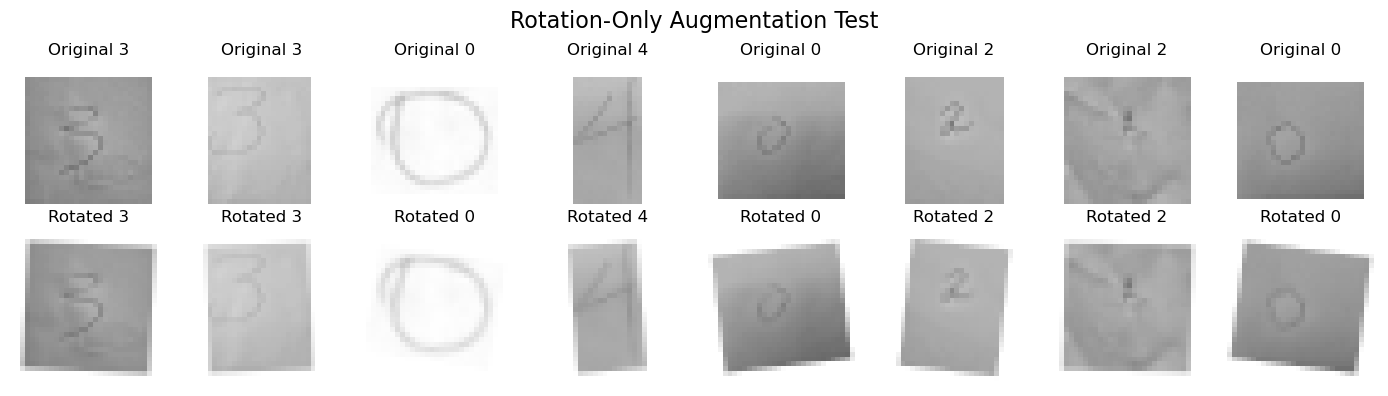

In [100]:
# ============================================
# 46. VISUALIZE ROTATION-ONLY AUGMENTATION
# ============================================

fig, axes = plt.subplots(
    2,
    8,
    figsize=(14, 4)
)

for i in range(8):

    axes[0, i].imshow(
        X_train[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0, i].set_title(
        f"Original {y_train[i]}"
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        rotation_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1, i].set_title(
        f"Rotated {rotation_labels[i]}"
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Rotated",
    fontsize=12
)

plt.suptitle(
    "Rotation-Only Augmentation Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 47 — Test Each Augmentation Separately

In [101]:
# We are going to identify exactly which transformation is causing the problem.

In [102]:
# ============================================
# 47. TEST AUGMENTATION TRANSFORMATIONS
# ============================================

augmentation_tests = {
    "Rotation": ImageDataGenerator(
        rotation_range=10,
        fill_mode="nearest"
    ),

    "Shift": ImageDataGenerator(
        width_shift_range=0.08,
        height_shift_range=0.08,
        fill_mode="nearest"
    ),

    "Zoom": ImageDataGenerator(
        zoom_range=0.08,
        fill_mode="nearest"
    ),

    "Shear": ImageDataGenerator(
        shear_range=0.05,
        fill_mode="nearest"
    ),

    "Brightness": ImageDataGenerator(
        brightness_range=(0.85, 1.15)
    )
}


print("=" * 60)
print("INDIVIDUAL AUGMENTATION TEST")
print("=" * 60)

for name, datagen in augmentation_tests.items():

    generator = datagen.flow(
        X_train[:8],
        y_train[:8],
        batch_size=8,
        shuffle=False,
        seed=RANDOM_STATE
    )

    test_images, test_labels = next(generator)

    print(f"\n{name}")
    print("-" * 40)

    print("Shape:", test_images.shape)
    print("Min:", test_images.min())
    print("Max:", test_images.max())
    print("Mean:", test_images.mean())
    print("Median:", np.median(test_images))

    print(
        "Images with mean < 0.1:",
        np.sum(
            test_images.mean(axis=(1, 2, 3)) < 0.1
        )
    )

INDIVIDUAL AUGMENTATION TEST

Rotation
----------------------------------------
Shape: (8, 32, 32, 1)
Min: 0.41351297
Max: 1.0
Mean: 0.8169883
Median: 0.8564959
Images with mean < 0.1: 0

Shift
----------------------------------------
Shape: (8, 32, 32, 1)
Min: 0.41862264
Max: 1.0
Mean: 0.8169898
Median: 0.83572215
Images with mean < 0.1: 0

Zoom
----------------------------------------
Shape: (8, 32, 32, 1)
Min: 0.42020285
Max: 1.0
Mean: 0.8143281
Median: 0.8264559
Images with mean < 0.1: 0

Shear
----------------------------------------
Shape: (8, 32, 32, 1)
Min: 0.40007856
Max: 1.0
Mean: 0.8169898
Median: 0.8710902
Images with mean < 0.1: 0

Brightness
----------------------------------------
Shape: (8, 32, 32, 1)
Min: 0.0
Max: 1.0
Mean: 0.28222656
Median: 0.0
Images with mean < 0.1: 3


## Step 48 — Visualize Every Transformation

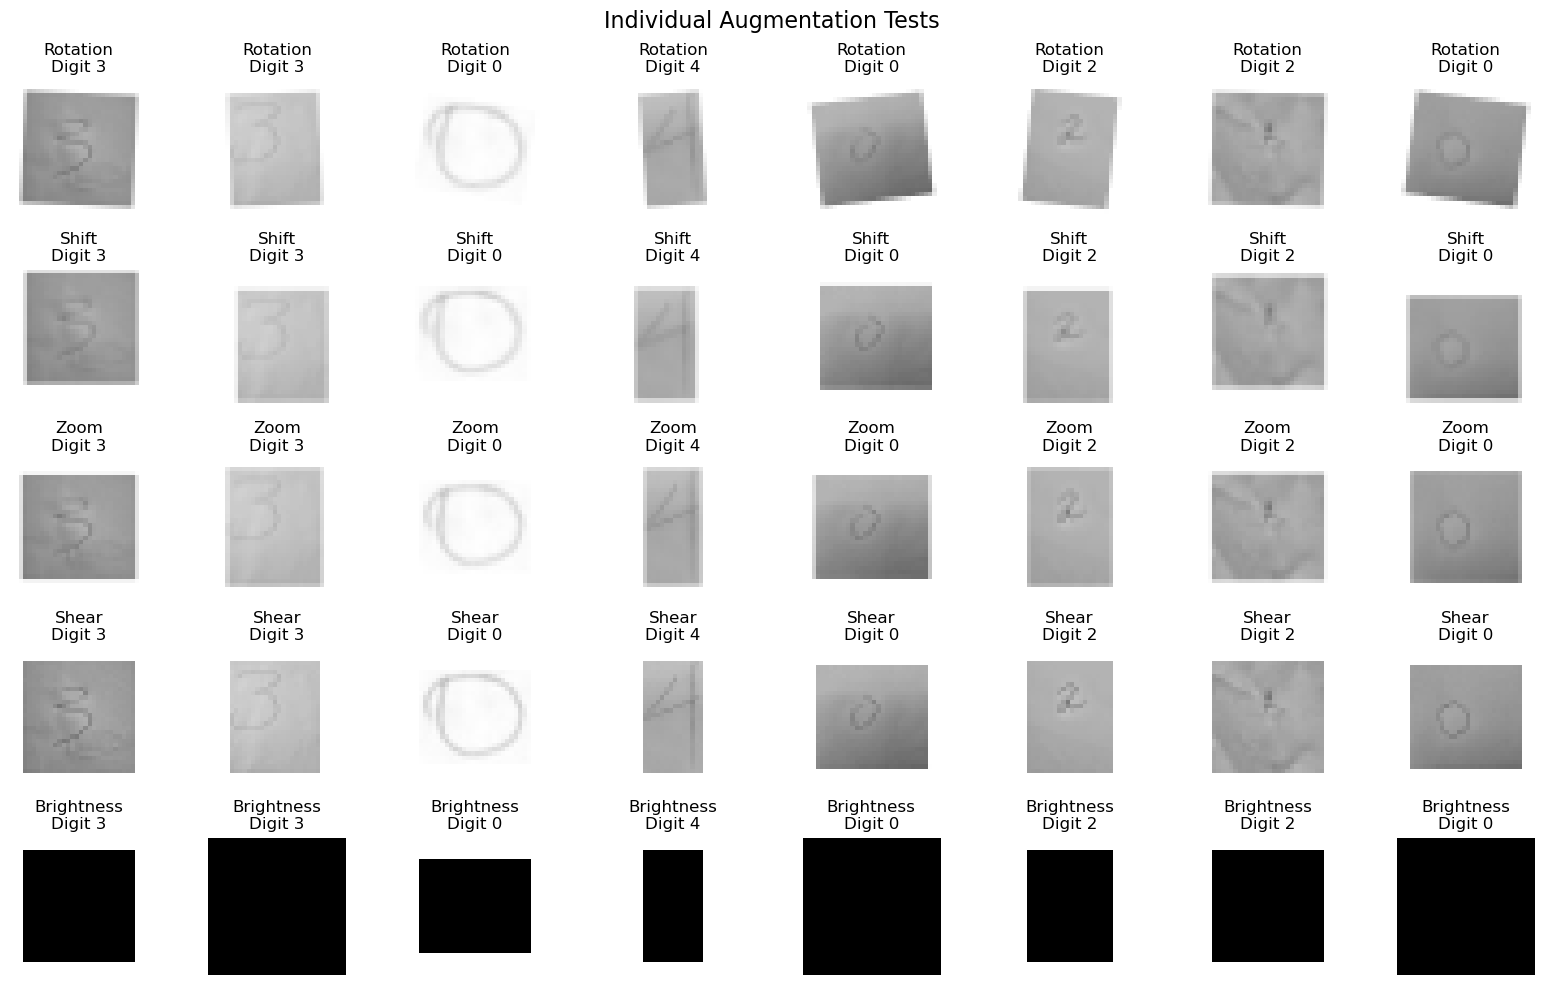

In [103]:
# ============================================
# 48. VISUALIZE INDIVIDUAL TRANSFORMATIONS
# ============================================

fig, axes = plt.subplots(
    5,
    8,
    figsize=(16, 10)
)

for row, (name, datagen) in enumerate(
    augmentation_tests.items()
):

    generator = datagen.flow(
        X_train[:8],
        y_train[:8],
        batch_size=8,
        shuffle=False,
        seed=RANDOM_STATE
    )

    test_images, test_labels = next(generator)

    for column in range(8):

        axes[row, column].imshow(
            test_images[column].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row, column].set_title(
            f"{name}\nDigit {test_labels[column]}"
        )

        axes[row, column].axis("off")


plt.suptitle(
    "Individual Augmentation Tests",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 49 — Create the Final Augmentation Pipeline

In [104]:
# ============================================
# 49. FINAL TRAINING AUGMENTATION PIPELINE
# ============================================

final_train_datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    shear_range=0.03,
    fill_mode="nearest"
)

print("Final augmentation pipeline created.")
print()
print("Augmentation settings:")
print("- Rotation: ±7 degrees")
print("- Width shift: 5%")
print("- Height shift: 5%")
print("- Zoom: ±5%")
print("- Shear: 3%")
print("- Brightness: DISABLED")
print("- Horizontal flip: DISABLED")
print("- Vertical flip: DISABLED")

Final augmentation pipeline created.

Augmentation settings:
- Rotation: ±7 degrees
- Width shift: 5%
- Height shift: 5%
- Zoom: ±5%
- Shear: 3%
- Brightness: DISABLED
- Horizontal flip: DISABLED
- Vertical flip: DISABLED


## Step 50 — Create the Final Training Generator

In [105]:
# ============================================
# 50. FINAL TRAINING GENERATOR
# ============================================

BATCH_SIZE = 32

final_train_generator = final_train_datagen.flow(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE
)

print("Final training generator created.")
print("Batch size:", BATCH_SIZE)

Final training generator created.
Batch size: 32


## Step 51 — Verify the Final Augmentation Numerically

In [106]:
# ============================================
# 51. VERIFY FINAL AUGMENTATION
# ============================================

final_augmented_images, final_augmented_labels = next(
    final_train_generator
)

print("=" * 50)
print("FINAL AUGMENTATION CHECK")
print("=" * 50)

print("Shape:")
print(final_augmented_images.shape)

print("\nLabels shape:")
print(final_augmented_labels.shape)

print("\nPixel minimum:")
print(final_augmented_images.min())

print("\nPixel maximum:")
print(final_augmented_images.max())

print("\nPixel mean:")
print(final_augmented_images.mean())

print("\nPixel median:")
print(np.median(final_augmented_images))

print("\nImages with mean < 0.1:")

image_means = final_augmented_images.mean(
    axis=(1, 2, 3)
)

print(
    np.sum(image_means < 0.1)
)

FINAL AUGMENTATION CHECK
Shape:
(32, 32, 32, 1)

Labels shape:
(32,)

Pixel minimum:
0.24462911

Pixel maximum:
1.0

Pixel mean:
0.82161486

Pixel median:
0.93131566

Images with mean < 0.1:
0


## Step 52 — Visual Quality Check

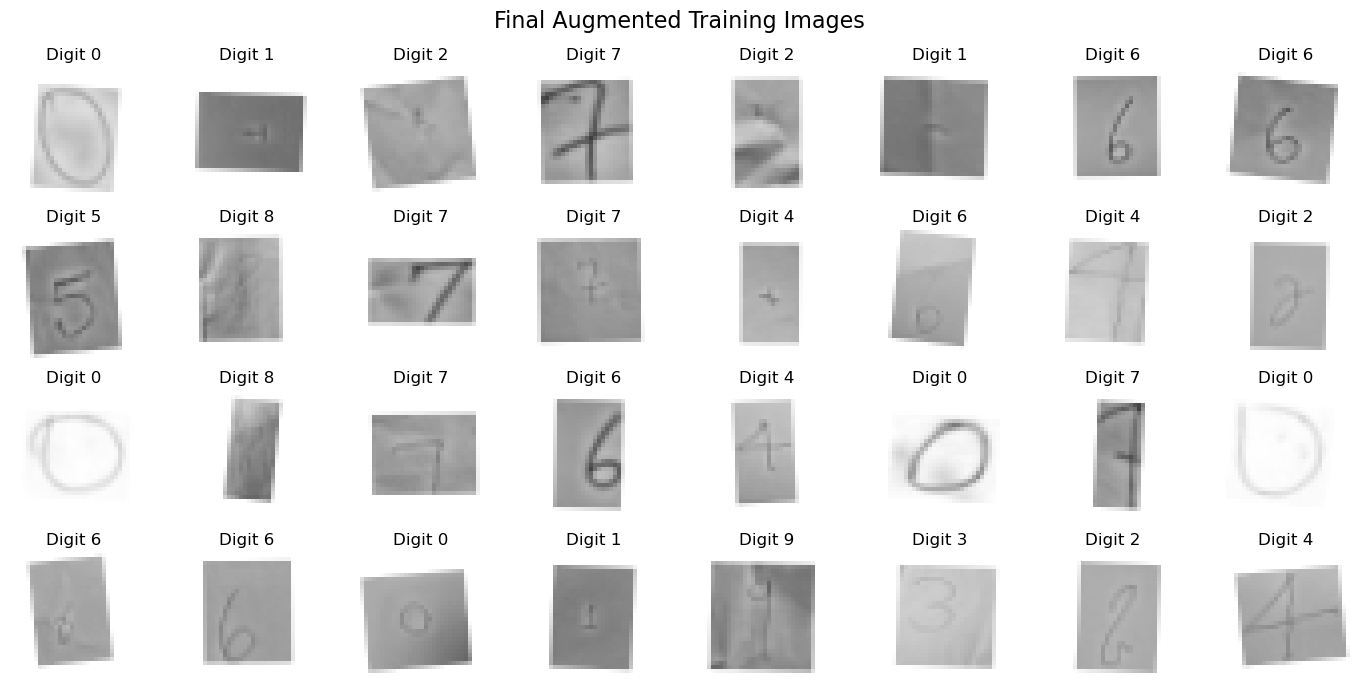

In [107]:
# ============================================
# 52. FINAL AUGMENTED IMAGE VISUALIZATION
# ============================================

fig, axes = plt.subplots(
    4,
    8,
    figsize=(14, 7)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        final_augmented_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Digit {int(final_augmented_labels[i])}"
    )

    ax.axis("off")


plt.suptitle(
    "Final Augmented Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 53 — Original vs Final Augmentation

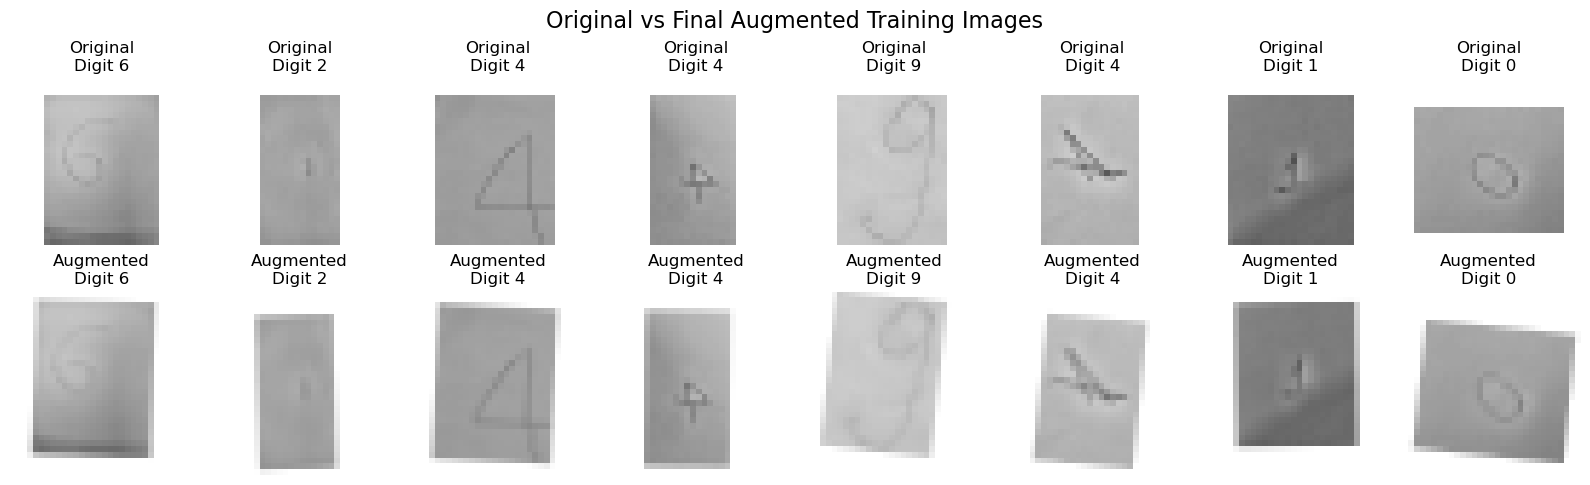

In [108]:
# ============================================
# 53. ORIGINAL VS FINAL AUGMENTATION
# ============================================

sample_indices = np.random.choice(
    len(X_train),
    size=8,
    replace=False
)

sample_images = X_train[sample_indices]
sample_labels = y_train[sample_indices]

sample_generator = final_train_datagen.flow(
    sample_images,
    sample_labels,
    batch_size=8,
    shuffle=False,
    seed=RANDOM_STATE
)

sample_augmented_images, sample_augmented_labels = next(
    sample_generator
)


fig, axes = plt.subplots(
    2,
    8,
    figsize=(16, 5)
)

for i in range(8):

    # Original
    axes[0, i].imshow(
        sample_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0, i].set_title(
        f"Original\nDigit {sample_labels[i]}"
    )

    axes[0, i].axis("off")


    # Augmented
    axes[1, i].imshow(
        sample_augmented_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1, i].set_title(
        f"Augmented\nDigit {sample_augmented_labels[i]}"
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Augmented",
    fontsize=12
)


plt.suptitle(
    "Original vs Final Augmented Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

# PHASE 5 — SMALL CNN

## Step 54 — Define the CNN Architecture

In [109]:
# ============================================
# 
# STEP 54 — BUILD SMALL CNN
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


# --------------------------------------------
# CNN MODEL
# --------------------------------------------

cnn_model = keras.Sequential([
    
    # Input
    layers.Input(shape=(32, 32, 1)),
    
    # Convolution Block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    
    # Convolution Block 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    
    # Classification Head
    layers.Flatten(),
    
    layers.Dense(
        64,
        activation="relu"
    ),
    
    layers.Dropout(
        0.30
    ),
    
    # 10 digits: 0–9
    layers.Dense(
        10,
        activation="softmax"
    )
])


print("CNN model created successfully.")

CNN model created successfully.


## Step 55 — Inspect the CNN

In [110]:
# Inspect the architecture

In [111]:
# ============================================
# STEP 55 — MODEL SUMMARY
# ============================================

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,674 (1.07 MB)

 Trainable params: 281,674 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

## Step 56 — Compile the Model

In [112]:
# Now we configure how the CNN learns

In [113]:
# ============================================
# STEP 56 — COMPILE CNN
# ============================================

cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=[
        "accuracy"
    ]
)

print("CNN compiled successfully.")

CNN compiled successfully.


## Step 57 — Create Training Callbacks

### We don't want to blindly train for 100 epochs.

#### We'll let the validation performance determine when training should stop.

#### We'll use:

### EarlyStopping

#### Stops training if validation loss stops improving.

### ReduceLROnPlateau

#### Reduces the learning rate if validation performance gets stuck.

### ModelCheckpoint

#### Saves the best model.

In [114]:
# ============================================
# STEP 57 — TRAINING CALLBACKS
# ============================================

import os

MODEL_DIR = "models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(
        MODEL_DIR,
        "digit_cnn_best.keras"
    ),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


print("Training callbacks created.")

Training callbacks created.


## Step 58 — Train the CNN

In [115]:
# ============================================
# STEP 58 — TRAIN CNN
# ============================================

EPOCHS = 50

history = cnn_model.fit(
    final_train_generator,
    
    validation_data=(
        X_val,
        y_val
    ),
    
    epochs=EPOCHS,
    
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1124 - loss: 2.3088
Epoch 1: val_loss improved from None to 2.28045, saving model to models\digit_cnn_best.keras

Epoch 1: finished saving model to models\digit_cnn_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.1124 - loss: 2.3088 - val_accuracy: 0.1061 - val_loss: 2.2804 - learning_rate: 0.0010
Epoch 2/50
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1146 - loss: 2.2797
Epoch 2: val_loss improved from 2.28045 to 2.27583, saving model to models\digit_cnn_best.keras

Epoch 2: finished saving model to models\digit_cnn_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1105 - loss: 2.2873 - val_accuracy: 0.1212 - val_loss: 2.2758 - learning_rate: 0.0010
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1181 - loss: 2.2896
Epoch 3: val_loss improved from 2.27583 to 2.27357, saving model to models\digit_cnn_best.keras

Epoch 3: finished saving model to models\digit_cnn_

## Step 59 — Check Training History

In [116]:
# ============================================
# STEP 59 — TRAINING RESULTS
# ============================================

print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Epochs actually trained:",
    len(history.history["loss"])
)

print(
    "Best validation accuracy:",
    max(history.history["val_accuracy"])
)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

TRAINING COMPLETE
Epochs actually trained: 38
Best validation accuracy: 0.5454545617103577
Best validation loss: 1.3979071378707886


## Step 60 — Plot Accuracy

In [117]:
# visualize how the CNN learned

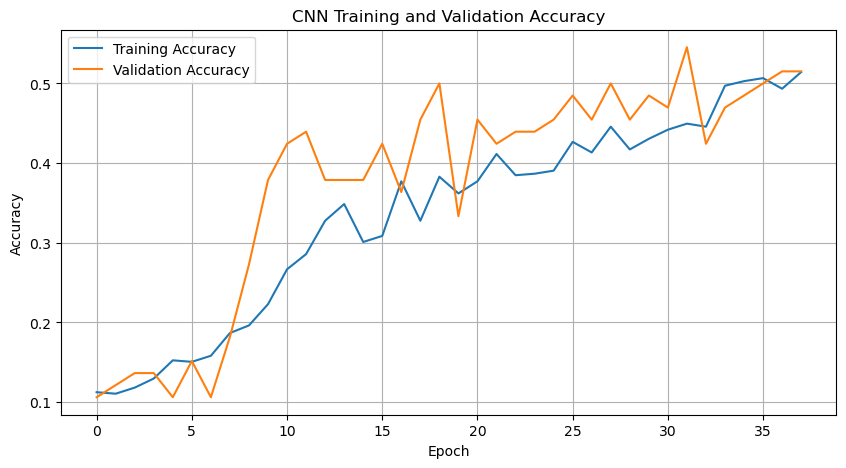

In [118]:
# ============================================
# STEP 60 — ACCURACY CURVE
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Step 61 — Plot Loss

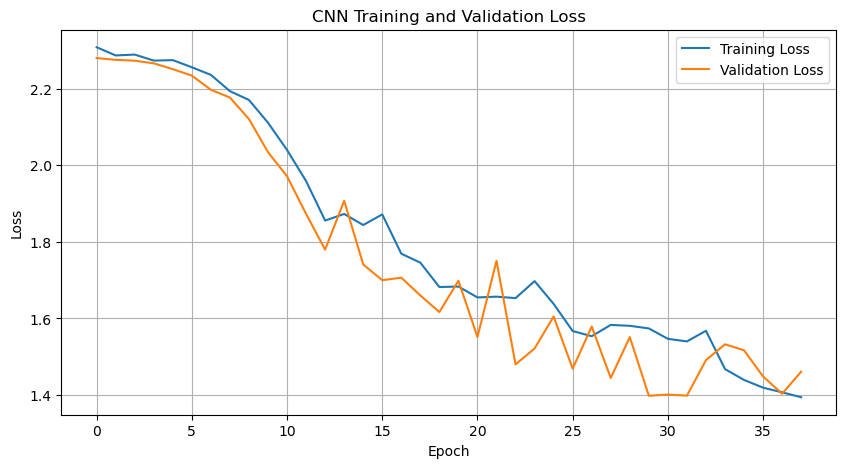

In [119]:
# ============================================
# STEP 61 — LOSS CURVE
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "CNN Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# PHASE 5 — DEBUGGING THE TRAINING PIPELINE

## Step 62 — Inspect the Actual Training Generator

In [120]:
# ============================================
# STEP 62 — INSPECT FINAL TRAINING GENERATOR
# ============================================

print("Training generator type:")
print(type(final_train_generator))

print("\nGenerator configuration:")
print(final_train_generator.image_data_generator.__dict__)

Training generator type:
<class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>

Generator configuration:
{'featurewise_center': False, 'samplewise_center': False, 'featurewise_std_normalization': False, 'samplewise_std_normalization': False, 'zca_whitening': False, 'zca_epsilon': 1e-06, 'rotation_range': 7, 'width_shift_range': 0.05, 'height_shift_range': 0.05, 'shear_range': 0.03, 'zoom_range': [0.95, 1.05], 'channel_shift_range': 0.0, 'fill_mode': 'nearest', 'cval': 0.0, 'horizontal_flip': False, 'vertical_flip': False, 'rescale': None, 'preprocessing_function': None, 'dtype': 'float32', 'interpolation_order': 1, 'data_format': 'channels_last', 'channel_axis': 3, 'row_axis': 1, 'col_axis': 2, '_validation_split': 0.0, 'mean': None, 'std': None, 'zca_whitening_matrix': None, 'brightness_range': None}


## Step 63 — Inspect a Real Training Batch

In [121]:
# Now let's look at the actual images being fed into the CNN.

In [122]:
# ============================================
# STEP 62 — INSPECT ACTUAL AUGMENTED BATCH
# ============================================

batch_images, batch_labels = next(final_train_generator)

print("Batch shape:", batch_images.shape)
print("Labels shape:", batch_labels.shape)

print("\nPixel statistics:")
print("Minimum :", batch_images.min())
print("Maximum :", batch_images.max())
print("Mean    :", batch_images.mean())
print("Median  :", np.median(batch_images))

# Count nearly-black images
image_means = batch_images.mean(axis=(1, 2, 3))

print("\nImage mean statistics:")
print("Minimum image mean:", image_means.min())
print("Maximum image mean:", image_means.max())
print("Mean image mean   :", image_means.mean())

print(
    "\nNearly black images:",
    np.sum(image_means < 0.1),
    "out of",
    len(image_means)
)

Batch shape: (32, 32, 32, 1)
Labels shape: (32,)

Pixel statistics:
Minimum : 0.20061183
Maximum : 1.0
Mean    : 0.8390002
Median  : 0.9507022

Image mean statistics:
Minimum image mean: 0.69835955
Maximum image mean: 0.96577626
Mean image mean   : 0.8390002

Nearly black images: 0 out of 32


## Step 64 — Visualize the Actual Training Batch

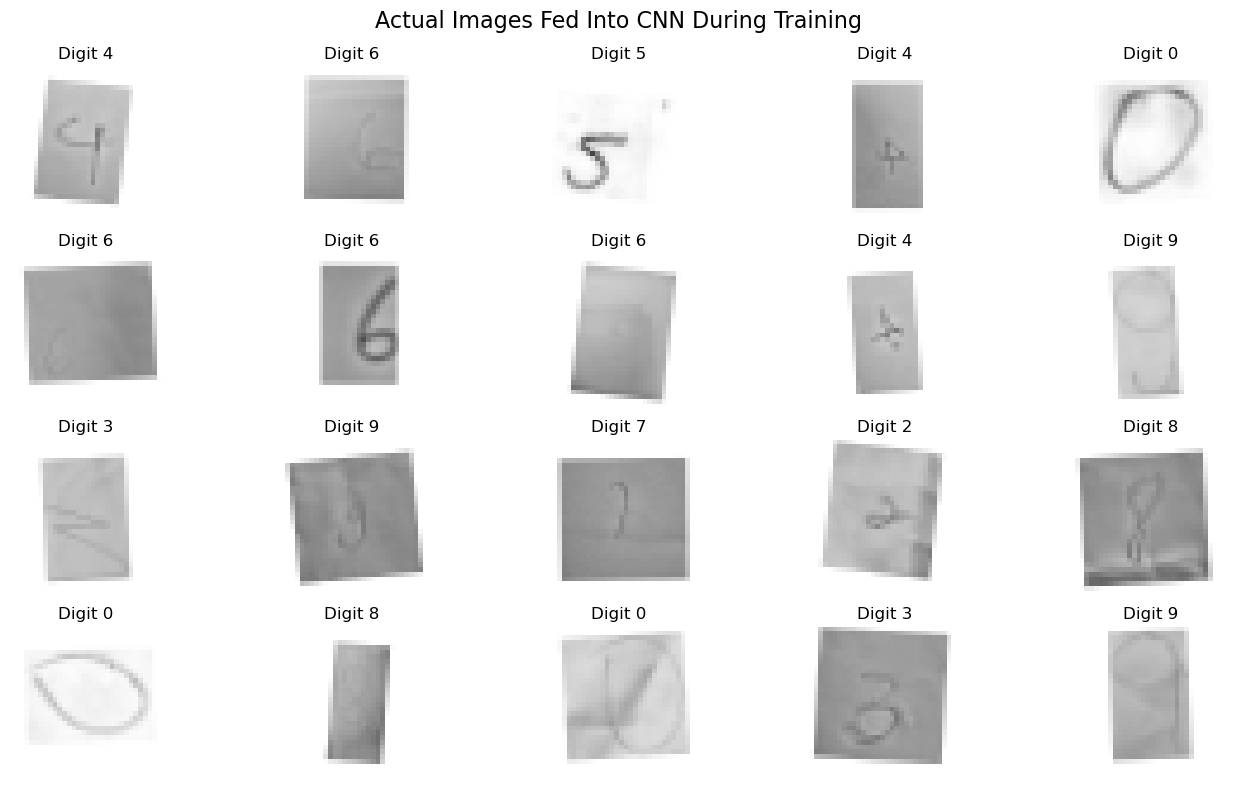

In [123]:
# ============================================
# STEP 64 — VISUALIZE ACTUAL TRAINING BATCH
# ============================================

plt.figure(figsize=(14, 8))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        batch_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Digit {batch_labels[i]}"
    )

    plt.axis("off")

plt.suptitle(
    "Actual Images Fed Into CNN During Training",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 65 — Check the Class Distribution of the Batch

In [124]:
# ============================================
# STEP 65 — BATCH CLASS DISTRIBUTION
# ============================================

unique, counts = np.unique(
    batch_labels,
    return_counts=True
)

print("Batch class distribution:")

for digit, count in zip(unique, counts):
    print(
        f"Digit {int(digit)}: {count}"
    )

Batch class distribution:
Digit 0: 4
Digit 2: 4
Digit 3: 2
Digit 4: 6
Digit 5: 2
Digit 6: 4
Digit 7: 2
Digit 8: 3
Digit 9: 5


# PHASE 6 — CNN DIAGNOSIS

## Step 66 — Evaluate the CNN on the ORIGINAL Training Data

In [125]:
# ============================================
# STEP 66 — EVALUATE ORIGINAL TRAINING DATA
# ============================================

train_loss, train_accuracy = cnn_model.evaluate(
    X_train,
    y_train,
    verbose=0
)

print("=" * 60)
print("ORIGINAL TRAINING DATA PERFORMANCE")
print("=" * 60)

print(f"Training Loss    : {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

ORIGINAL TRAINING DATA PERFORMANCE
Training Loss    : 1.3023
Training Accuracy: 0.5390
Training Accuracy: 53.90%


## Step 67 — Evaluate Validation Data Again

In [126]:
# ============================================
# STEP 67 — EVALUATE VALIDATION DATA
# ============================================

val_loss, val_accuracy = cnn_model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("=" * 60)
print("VALIDATION PERFORMANCE")
print("=" * 60)

print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

VALIDATION PERFORMANCE
Validation Loss    : 1.3979
Validation Accuracy: 0.4848
Validation Accuracy: 48.48%


## Step 68 — Check Training Performance Per Digit

In [127]:
# ============================================
# STEP 68 — TRAINING PREDICTIONS
# ============================================

train_predictions = cnn_model.predict(
    X_train,
    verbose=0
)

y_train_pred = np.argmax(
    train_predictions,
    axis=1
)

print("Training predictions generated.")

Training predictions generated.


In [128]:
# ============================================
# STEP 68B — PER-DIGIT TRAINING ACCURACY
# ============================================

from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(
    y_train,
    y_train_pred,
    labels=np.arange(10)
)

print("=" * 60)
print("TRAINING ACCURACY BY DIGIT")
print("=" * 60)

for digit in range(10):

    correct = cm_train[digit, digit]
    total = cm_train[digit].sum()

    accuracy = (
        correct / total
        if total > 0
        else 0
    )

    print(
        f"Digit {digit}: "
        f"{correct}/{total} "
        f"= {accuracy * 100:.2f}%"
    )

TRAINING ACCURACY BY DIGIT
Digit 0: 72/72 = 100.00%
Digit 1: 18/40 = 45.00%
Digit 2: 24/64 = 37.50%
Digit 3: 2/44 = 4.55%
Digit 4: 44/64 = 68.75%
Digit 5: 54/64 = 84.38%
Digit 6: 18/55 = 32.73%
Digit 7: 18/41 = 43.90%
Digit 8: 25/41 = 60.98%
Digit 9: 8/40 = 20.00%


## Step 69 — Check Whether Labels Are Correct

In [129]:
# ============================================
# STEP 69 — VERIFY LABEL DISTRIBUTION
# ============================================

print("=" * 60)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 60)

unique, counts = np.unique(
    y_train,
    return_counts=True
)

for digit, count in zip(unique, counts):
    print(
        f"Digit {int(digit)}: {count} images"
    )

TRAINING CLASS DISTRIBUTION
Digit 0: 72 images
Digit 1: 40 images
Digit 2: 64 images
Digit 3: 44 images
Digit 4: 64 images
Digit 5: 64 images
Digit 6: 55 images
Digit 7: 41 images
Digit 8: 41 images
Digit 9: 40 images


## STEP 70 - Inspect Every Digit's Training Images

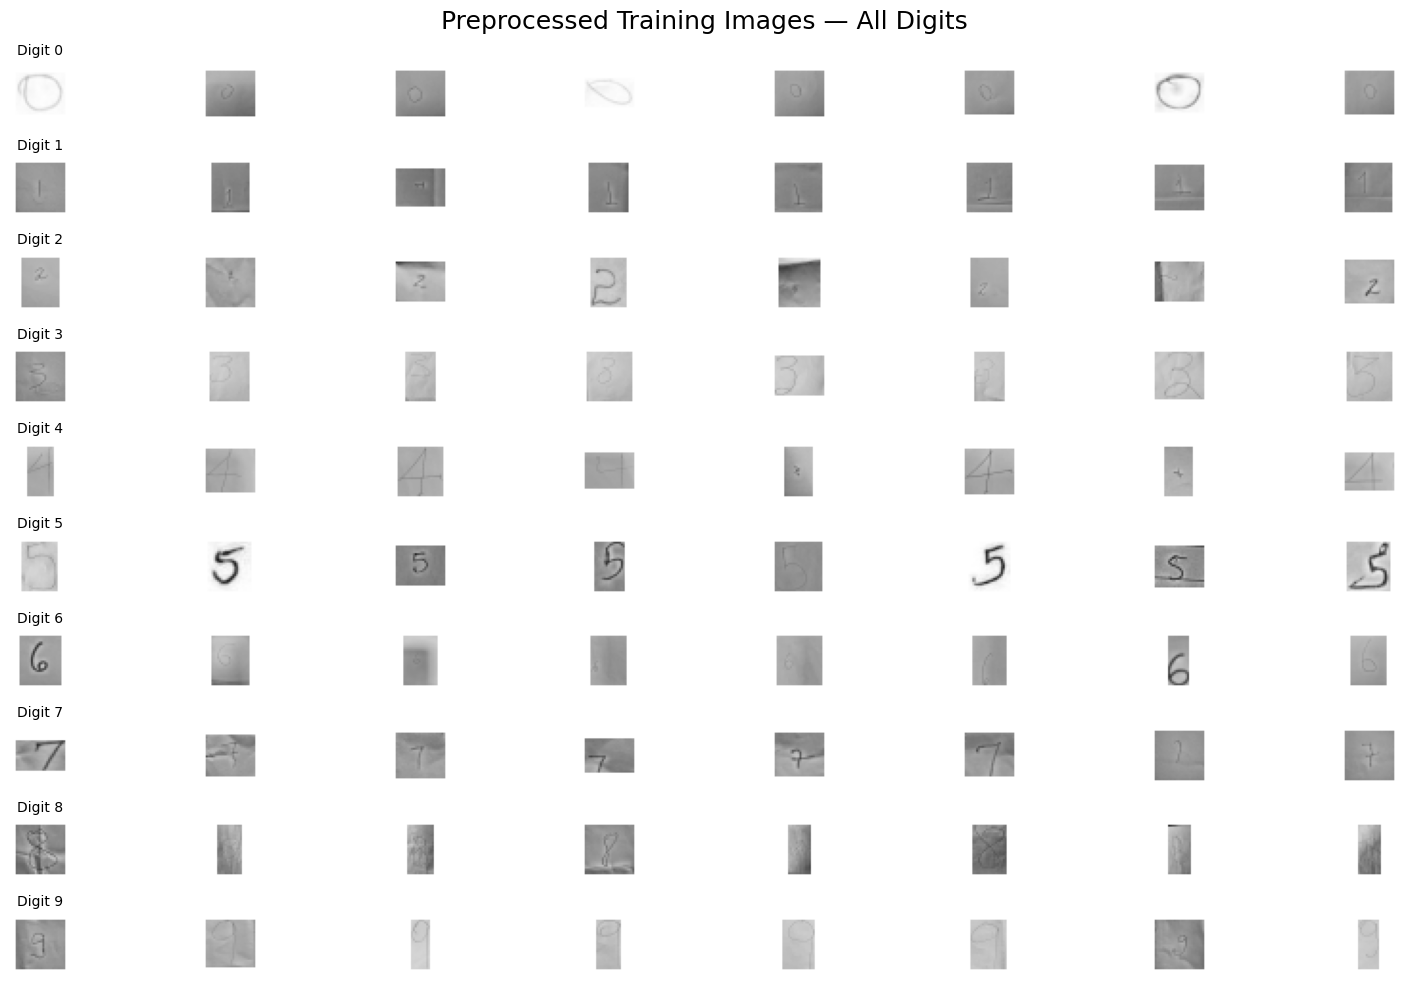

In [130]:
# ============================================
# STEP 70 — CLASS VISUALIZATION
# ============================================

plt.figure(figsize=(16, 10))

for digit in range(10):

    # Find training images belonging to this digit
    indices = np.where(y_train == digit)[0]

    # Select up to 8 examples
    selected = indices[:8]

    for j, idx in enumerate(selected):

        position = digit * 8 + j + 1

        ax = plt.subplot(10, 8, position)

        ax.imshow(
            X_train[idx].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        ax.axis("off")

        if j == 0:
            ax.set_title(
                f"Digit {digit}",
                fontsize=10
            )

plt.suptitle(
    "Preprocessed Training Images — All Digits",
    fontsize=18
)

plt.tight_layout()
plt.show()

## STEP 71 — Compare Class Pixel Statistics

In [131]:
# ============================================
# STEP 70 — PIXEL STATISTICS BY DIGIT
# ============================================

print("=" * 70)
print("PIXEL STATISTICS BY DIGIT")
print("=" * 70)

for digit in range(10):

    indices = np.where(y_train == digit)[0]

    class_images = X_train[indices]

    print(
        f"\nDigit {digit}"
    )

    print(
        f"  Images : {len(indices)}"
    )

    print(
        f"  Mean   : {class_images.mean():.4f}"
    )

    print(
        f"  Median : {np.median(class_images):.4f}"
    )

    print(
        f"  Min    : {class_images.min():.4f}"
    )

    print(
        f"  Max    : {class_images.max():.4f}"
    )

PIXEL STATISTICS BY DIGIT

Digit 0
  Images : 72
  Mean   : 0.8522
  Median : 0.9725
  Min    : 0.3098
  Max    : 1.0000

Digit 1
  Images : 40
  Mean   : 0.7244
  Median : 0.5804
  Min    : 0.1961
  Max    : 1.0000

Digit 2
  Images : 64
  Mean   : 0.8234
  Median : 0.7843
  Min    : 0.0745
  Max    : 1.0000

Digit 3
  Images : 44
  Mean   : 0.8154
  Median : 0.7843
  Min    : 0.3647
  Max    : 1.0000

Digit 4
  Images : 64
  Mean   : 0.8599
  Median : 1.0000
  Min    : 0.3451
  Max    : 1.0000

Digit 5
  Images : 64
  Mean   : 0.8519
  Median : 0.9882
  Min    : 0.0549
  Max    : 1.0000

Digit 6
  Images : 55
  Mean   : 0.8108
  Median : 0.7882
  Min    : 0.1294
  Max    : 1.0000

Digit 7
  Images : 41
  Mean   : 0.7727
  Median : 0.6627
  Min    : 0.1765
  Max    : 1.0000

Digit 8
  Images : 41
  Mean   : 0.8269
  Median : 1.0000
  Min    : 0.1686
  Max    : 1.0000

Digit 9
  Images : 40
  Mean   : 0.8449
  Median : 1.0000
  Min    : 0.3137
  Max    : 1.0000


## STEP 72 — Find the Hardest Images for Each Class

In [132]:
# ============================================
# STEP 72 — DARK PIXEL ANALYSIS
# ============================================

print("=" * 70)
print("DARK PIXEL ANALYSIS")
print("=" * 70)

for digit in range(10):

    indices = np.where(y_train == digit)[0]

    class_images = X_train[indices]

    # Pixels darker than 0.5
    dark_pixel_ratio = np.mean(
        class_images < 0.5,
        axis=(1, 2, 3)
    )

    print(
        f"\nDigit {digit}"
    )

    print(
        f"  Mean dark-pixel ratio   : "
        f"{dark_pixel_ratio.mean():.4f}"
    )

    print(
        f"  Minimum dark-pixel ratio: "
        f"{dark_pixel_ratio.min():.4f}"
    )

    print(
        f"  Maximum dark-pixel ratio: "
        f"{dark_pixel_ratio.max():.4f}"
    )

DARK PIXEL ANALYSIS

Digit 0
  Mean dark-pixel ratio   : 0.0268
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.1895

Digit 1
  Mean dark-pixel ratio   : 0.2198
  Minimum dark-pixel ratio: 0.0078
  Maximum dark-pixel ratio: 0.5352

Digit 2
  Mean dark-pixel ratio   : 0.0292
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.3477

Digit 3
  Mean dark-pixel ratio   : 0.0034
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.0557

Digit 4
  Mean dark-pixel ratio   : 0.0019
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.0205

Digit 5
  Mean dark-pixel ratio   : 0.0617
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.4131

Digit 6
  Mean dark-pixel ratio   : 0.0247
  Minimum dark-pixel ratio: 0.0000
  Maximum dark-pixel ratio: 0.1084

Digit 7
  Mean dark-pixel ratio   : 0.0460
  Minimum dark-pixel ratio: 0.0020
  Maximum dark-pixel ratio: 0.1621

Digit 8
  Mean dark-pixel ratio   : 0.0727
  Minimum dark-pixel rat

## STEP 73 — Generate the Training Confusion Matrix

<Figure size 900x800 with 0 Axes>

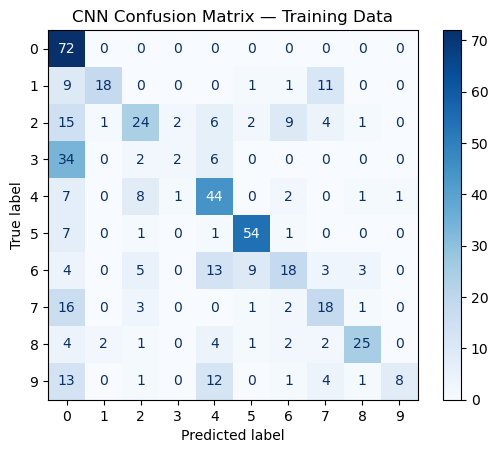

In [133]:
# ============================================
# STEP 73 — TRAINING CONFUSION MATRIX
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    labels=np.arange(10),
    cmap="Blues",
    values_format="d"
)

plt.title(
    "CNN Confusion Matrix — Training Data"
)

plt.show()

## STEP 74 — Show Misclassified Training Images

Total misclassified training images: 242


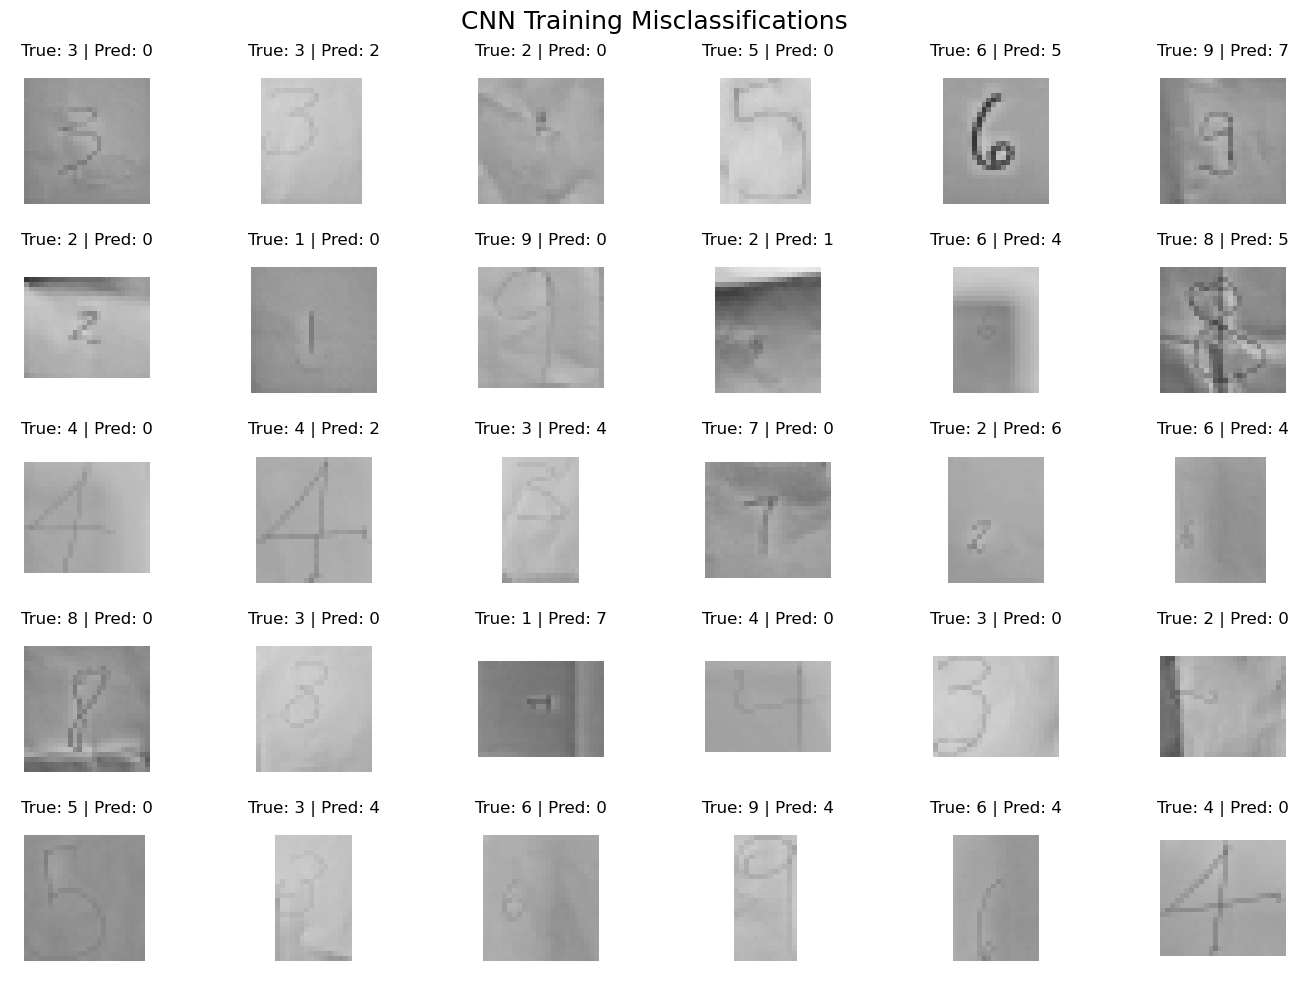

In [134]:
# ============================================
# STEP 74 — VISUALIZE MISCLASSIFICATIONS
# ============================================

wrong_indices = np.where(
    y_train != y_train_pred
)[0]

print(
    "Total misclassified training images:",
    len(wrong_indices)
)

plt.figure(figsize=(14, 10))

num_images = min(
    30,
    len(wrong_indices)
)

for i in range(num_images):

    idx = wrong_indices[i]

    ax = plt.subplot(5, 6, i + 1)

    ax.imshow(
        X_train[idx].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"True: {y_train[idx]} | "
        f"Pred: {y_train_pred[idx]}"
    )

    ax.axis("off")

plt.suptitle(
    "CNN Training Misclassifications",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [135]:
# ============================================
# STEP 74 — FIND EXTREMELY FAINT IMAGES
# ============================================

print("=" * 70)
print("EXTREMELY FAINT TRAINING IMAGES")
print("=" * 70)

image_dark_ratio = np.mean(
    X_train < 0.5,
    axis=(1, 2, 3)
)

# Sort from least dark pixels to most dark pixels
sorted_indices = np.argsort(image_dark_ratio)

for rank in range(20):

    idx = sorted_indices[rank]

    print(
        f"{rank + 1:2d}. "
        f"Index={idx:3d} | "
        f"Digit={y_train[idx]} | "
        f"Dark ratio={image_dark_ratio[idx]:.4f}"
    )

EXTREMELY FAINT TRAINING IMAGES
 1. Index=520 | Digit=2 | Dark ratio=0.0000
 2. Index=  1 | Digit=3 | Dark ratio=0.0000
 3. Index=  2 | Digit=0 | Dark ratio=0.0000
 4. Index=  3 | Digit=4 | Dark ratio=0.0000
 5. Index=516 | Digit=3 | Dark ratio=0.0000
 6. Index=514 | Digit=9 | Dark ratio=0.0000
 7. Index=497 | Digit=4 | Dark ratio=0.0000
 8. Index=501 | Digit=4 | Dark ratio=0.0000
 9. Index=502 | Digit=0 | Dark ratio=0.0000
10. Index=504 | Digit=6 | Dark ratio=0.0000
11. Index= 41 | Digit=4 | Dark ratio=0.0000
12. Index= 43 | Digit=3 | Dark ratio=0.0000
13. Index= 48 | Digit=3 | Dark ratio=0.0000
14. Index= 49 | Digit=6 | Dark ratio=0.0000
15. Index= 50 | Digit=9 | Dark ratio=0.0000
16. Index= 54 | Digit=6 | Dark ratio=0.0000
17. Index=351 | Digit=4 | Dark ratio=0.0000
18. Index=352 | Digit=9 | Dark ratio=0.0000
19. Index=354 | Digit=0 | Dark ratio=0.0000
20. Index=355 | Digit=2 | Dark ratio=0.0000


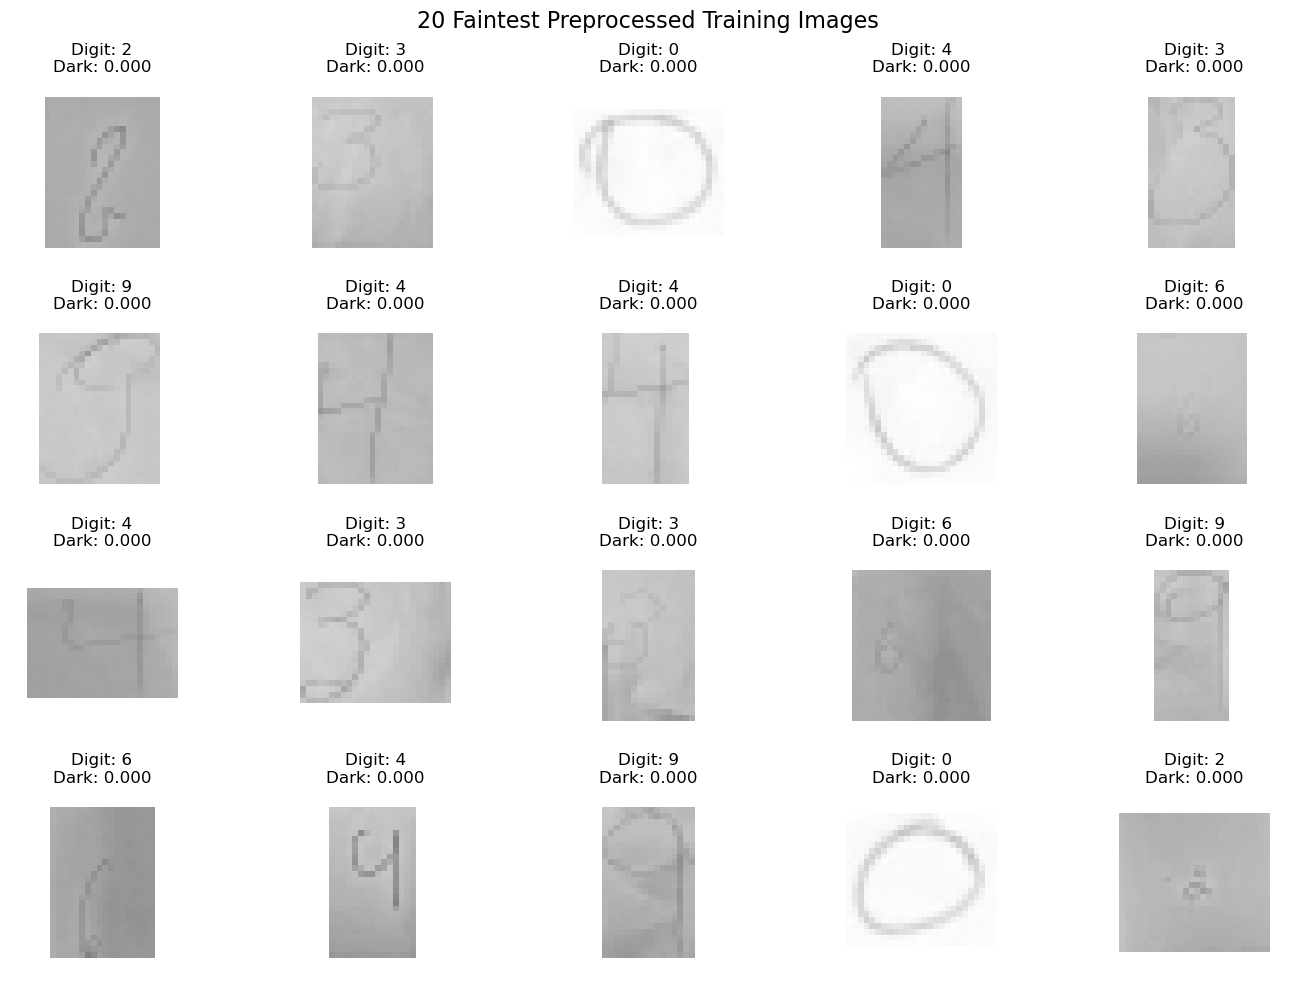

In [136]:
# ============================================
# STEP 75 — VISUALIZE FAINT IMAGES
# ============================================

plt.figure(figsize=(14, 10))

for i in range(20):

    idx = sorted_indices[i]

    ax = plt.subplot(4, 5, i + 1)

    ax.imshow(
        X_train[idx].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Digit: {y_train[idx]}\n"
        f"Dark: {image_dark_ratio[idx]:.3f}"
    )

    ax.axis("off")

plt.suptitle(
    "20 Faintest Preprocessed Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [137]:
# ============================================
# STEP 76 — CONTRAST ANALYSIS
# ============================================

print("=" * 70)
print("CONTRAST ANALYSIS BY DIGIT")
print("=" * 70)

for digit in range(10):

    indices = np.where(
        y_train == digit
    )[0]

    class_images = X_train[indices]

    image_min = class_images.min(
        axis=(1, 2, 3)
    )

    image_mean = class_images.mean(
        axis=(1, 2, 3)
    )

    contrast = image_mean - image_min

    print(f"\nDigit {digit}")

    print(
        f"  Mean contrast   : {contrast.mean():.4f}"
    )

    print(
        f"  Minimum contrast: {contrast.min():.4f}"
    )

    print(
        f"  Maximum contrast: {contrast.max():.4f}"
    )

CONTRAST ANALYSIS BY DIGIT

Digit 0
  Mean contrast   : 0.3120
  Minimum contrast: 0.1305
  Maximum contrast: 0.6115

Digit 1
  Mean contrast   : 0.3605
  Minimum contrast: 0.2479
  Maximum contrast: 0.4862

Digit 2
  Mean contrast   : 0.4173
  Minimum contrast: 0.2045
  Maximum contrast: 0.7418

Digit 3
  Mean contrast   : 0.2562
  Minimum contrast: 0.1687
  Maximum contrast: 0.5060

Digit 4
  Mean contrast   : 0.3591
  Minimum contrast: 0.2171
  Maximum contrast: 0.5483

Digit 5
  Mean contrast   : 0.6131
  Minimum contrast: 0.2101
  Maximum contrast: 0.8625

Digit 6
  Mean contrast   : 0.4226
  Minimum contrast: 0.2156
  Maximum contrast: 0.7004

Digit 7
  Mean contrast   : 0.4281
  Minimum contrast: 0.2452
  Maximum contrast: 0.6595

Digit 8
  Mean contrast   : 0.4460
  Minimum contrast: 0.3078
  Maximum contrast: 0.7130

Digit 9
  Mean contrast   : 0.2988
  Minimum contrast: 0.2003
  Maximum contrast: 0.5366


In [138]:
# ============================================
# STEP 77 — CONTRAST ENHANCEMENT TEST
# ============================================

from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


def enhance_contrast(image_array):
    """
    Enhance grayscale contrast while preserving
    the original digit/background structure.
    """

    # Convert [0,1] float image to uint8 [0,255]
    image_uint8 = (
        np.clip(image_array * 255, 0, 255)
        .astype(np.uint8)
    )

    # PIL image
    image = Image.fromarray(
        image_uint8,
        mode="L"
    )

    # Contrast enhancement
    enhanced = ImageOps.autocontrast(
        image,
        cutoff=1
    )

    # Back to [0,1]
    enhanced_array = (
        np.asarray(enhanced)
        .astype(np.float32) / 255.0
    )

    return enhanced_array

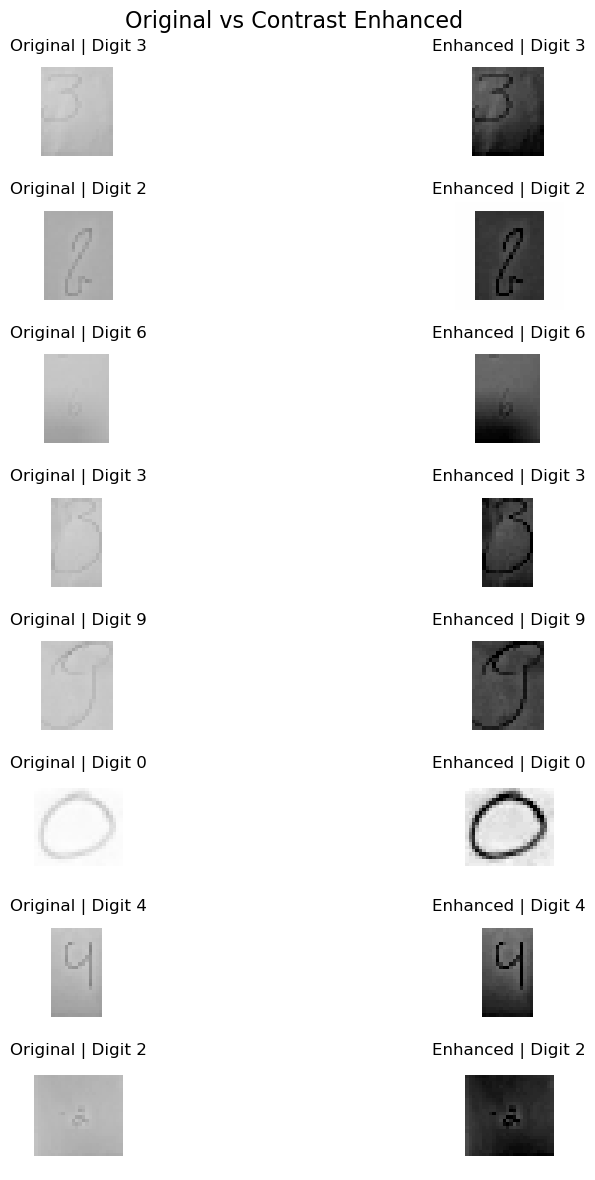

In [139]:
# ============================================
# STEP 78 — ORIGINAL VS ENHANCED
# ============================================

# Select some difficult images
test_indices = [
    1,
    520,
    504,
    516,
    514,
    354,
    351,
    355
]

plt.figure(figsize=(12, 12))

for row, idx in enumerate(test_indices):

    original = X_train[idx].squeeze()

    enhanced = enhance_contrast(
        original
    )

    # Original
    ax1 = plt.subplot(
        len(test_indices),
        2,
        row * 2 + 1
    )

    ax1.imshow(
        original,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax1.set_title(
        f"Original | Digit {y_train[idx]}"
    )

    ax1.axis("off")

    # Enhanced
    ax2 = plt.subplot(
        len(test_indices),
        2,
        row * 2 + 2
    )

    ax2.imshow(
        enhanced,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax2.set_title(
        f"Enhanced | Digit {y_train[idx]}"
    )

    ax2.axis("off")


plt.suptitle(
    "Original vs Contrast Enhanced",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [140]:
# ============================================
# STEP 79 — CONTRAST COMPARISON
# ============================================

print("=" * 70)
print("ORIGINAL VS ENHANCED CONTRAST")
print("=" * 70)

for digit in range(10):

    indices = np.where(
        y_train == digit
    )[0]

    original_contrasts = []
    enhanced_contrasts = []

    for idx in indices:

        original = X_train[idx].squeeze()

        enhanced = enhance_contrast(
            original
        )

        original_contrast = (
            original.mean() - original.min()
        )

        enhanced_contrast = (
            enhanced.mean() - enhanced.min()
        )

        original_contrasts.append(
            original_contrast
        )

        enhanced_contrasts.append(
            enhanced_contrast
        )

    print(
        f"\nDigit {digit}"
    )

    print(
        f"  Original mean contrast : "
        f"{np.mean(original_contrasts):.4f}"
    )

    print(
        f"  Enhanced mean contrast : "
        f"{np.mean(enhanced_contrasts):.4f}"
    )

ORIGINAL VS ENHANCED CONTRAST

Digit 0
  Original mean contrast : 0.3120
  Enhanced mean contrast : 0.6747

Digit 1
  Original mean contrast : 0.3605
  Enhanced mean contrast : 0.5049

Digit 2
  Original mean contrast : 0.4173
  Enhanced mean contrast : 0.6396

Digit 3
  Original mean contrast : 0.2562
  Enhanced mean contrast : 0.5389

Digit 4
  Original mean contrast : 0.3591
  Enhanced mean contrast : 0.6654

Digit 5
  Original mean contrast : 0.6131
  Enhanced mean contrast : 0.7642

Digit 6
  Original mean contrast : 0.4226
  Enhanced mean contrast : 0.6478

Digit 7
  Original mean contrast : 0.4281
  Enhanced mean contrast : 0.5863

Digit 8
  Original mean contrast : 0.4460
  Enhanced mean contrast : 0.6923

Digit 9
  Original mean contrast : 0.2988
  Enhanced mean contrast : 0.6208


# Reprocess All Images With Contrast Enhancement

In [143]:
# ============================================
# STEP 81 — BUILD ENHANCED PROCESSED DATASET
# ============================================

from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd


# --------------------------------------------
# 1. Define directories
# --------------------------------------------

ORIGINAL_DIR = Path("dataset")
ENHANCED_DIR = Path("processed_dataset_enhanced")

ENHANCED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------
# 2. Create class folders
# --------------------------------------------

for digit in range(10):

    (
        ENHANCED_DIR / str(digit)
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------
# 3. Collect original images
# --------------------------------------------

image_records = []

for digit in range(10):

    digit_dir = ORIGINAL_DIR / str(digit)

    image_files = sorted(
        digit_dir.glob("*.jpg")
    )

    for image_path in image_files:

        image_records.append({
            "digit": digit,
            "original_path": image_path
        })


print("=" * 60)
print("ENHANCED DATASET PREPROCESSING")
print("=" * 60)

print(
    f"Original images found: {len(image_records)}"
)


# --------------------------------------------
# 4. Process images
# --------------------------------------------

enhanced_records = []
processing_errors_enhanced = []

for i, record in enumerate(image_records):

    digit = record["digit"]
    original_path = record["original_path"]

    try:

        # ------------------------------------
        # Existing approved preprocessing
        # ------------------------------------

        processed_image = preprocess_image(
            original_path
        )


        # ------------------------------------
        # Contrast enhancement
        # ------------------------------------

        enhanced_image = enhance_contrast(
            processed_image
        )


        # ------------------------------------
        # Ensure correct size
        # ------------------------------------

        if enhanced_image.shape != (32, 32):

            raise ValueError(
                f"Unexpected image shape: "
                f"{enhanced_image.shape}"
            )


        # ------------------------------------
        # Ensure float32 [0,1]
        # ------------------------------------

        enhanced_image = np.asarray(
            enhanced_image,
            dtype=np.float32
        )

        enhanced_image = np.clip(
            enhanced_image,
            0.0,
            1.0
        )


        # ------------------------------------
        # Save as PNG
        # ------------------------------------

        output_filename = (
            original_path.stem + ".png"
        )

        output_path = (
            ENHANCED_DIR
            / str(digit)
            / output_filename
        )


        # Convert to uint8 for saving

        enhanced_uint8 = (
            enhanced_image * 255
        ).round().astype(np.uint8)


        Image.fromarray(
            enhanced_uint8,
            mode="L"
        ).save(
            output_path
        )


        # ------------------------------------
        # Store metadata
        # ------------------------------------

        enhanced_records.append({

            "digit": digit,

            "original_filename":
                original_path.name,

            "processed_filename":
                output_filename,

            "original_path":
                str(original_path),

            "processed_path":
                str(output_path),

            "width":
                enhanced_image.shape[1],

            "height":
                enhanced_image.shape[0],

            "min_pixel":
                enhanced_image.min(),

            "max_pixel":
                enhanced_image.max(),

            "mean_pixel":
                enhanced_image.mean()
        })


    except Exception as e:

        processing_errors_enhanced.append({

            "digit": digit,

            "filename":
                original_path.name,

            "error":
                str(e)
        })


    # Progress

    if (i + 1) % 100 == 0:

        print(
            f"Processed {i + 1}/"
            f"{len(image_records)}"
        )


# --------------------------------------------
# 5. Create metadata DataFrame
# --------------------------------------------

enhanced_df = pd.DataFrame(
    enhanced_records
)


# --------------------------------------------
# 6. Final report
# --------------------------------------------

print()
print("=" * 60)
print("ENHANCED PREPROCESSING COMPLETE")
print("=" * 60)

print(
    f"Original images : "
    f"{len(image_records)}"
)

print(
    f"Processed images: "
    f"{len(enhanced_records)}"
)

print(
    f"Errors          : "
    f"{len(processing_errors_enhanced)}"
)

ENHANCED DATASET PREPROCESSING
Original images found: 657
Processed 100/657
Processed 200/657
Processed 300/657
Processed 400/657
Processed 500/657
Processed 600/657

ENHANCED PREPROCESSING COMPLETE
Original images : 657
Processed images: 657
Errors          : 0


# Verify Enhanced Dataset

In [144]:
# ============================================
# STEP 82 — VERIFY ENHANCED DATASET
# ============================================

print("=" * 60)
print("ENHANCED DATASET VERIFICATION")
print("=" * 60)


# --------------------------------------------
# 1. Dataset shape
# --------------------------------------------

print("\nDataset shape:")
print(
    enhanced_df.shape
)


# --------------------------------------------
# 2. Image dimensions
# --------------------------------------------

print("\nImage dimensions:")

print(
    enhanced_df[
        ["width", "height"]
    ]
    .value_counts()
)


# --------------------------------------------
# 3. Pixel range
# --------------------------------------------

print("\nPixel statistics:")

print(
    "Minimum:",
    enhanced_df["min_pixel"].min()
)

print(
    "Maximum:",
    enhanced_df["max_pixel"].max()
)

print(
    "Mean:",
    enhanced_df["mean_pixel"].mean()
)


# --------------------------------------------
# 4. Class distribution
# --------------------------------------------

print("\nClass distribution:")

print(
    enhanced_df["digit"]
    .value_counts()
    .sort_index()
)


# --------------------------------------------
# 5. Errors
# --------------------------------------------

print(
    "\nVerification errors:",
    len(processing_errors_enhanced)
)

ENHANCED DATASET VERIFICATION

Dataset shape:
(657, 10)

Image dimensions:
width  height
32     32        657
Name: count, dtype: int64

Pixel statistics:
Minimum: 0.0
Maximum: 1.0
Mean: 0.6475376

Class distribution:
digit
0    90
1    50
2    80
3    56
4    80
5    80
6    69
7    51
8    51
9    50
Name: count, dtype: int64

Verification errors: 0


## Load Enhanced Images Into X

### Now we create the new dataset that will actually be given to the CNN.

In [145]:
# ============================================
# STEP 83 — LOAD ENHANCED DATA INTO X
# ============================================

X_enhanced = []
y_enhanced = []


for _, row in enhanced_df.iterrows():

    image = Image.open(
        row["processed_path"]
    ).convert("L")

    image_array = (
        np.asarray(image)
        .astype(np.float32)
        / 255.0
    )

    X_enhanced.append(
        image_array
    )

    y_enhanced.append(
        row["digit"]
    )


# Convert to NumPy arrays

X_enhanced = np.array(
    X_enhanced,
    dtype=np.float32
)

y_enhanced = np.array(
    y_enhanced,
    dtype=np.int64
)


# Add CNN channel dimension

X_enhanced = X_enhanced[..., np.newaxis]


print("=" * 60)
print("ENHANCED DATASET ARRAYS")
print("=" * 60)

print(
    "X_enhanced shape:",
    X_enhanced.shape
)

print(
    "y_enhanced shape:",
    y_enhanced.shape
)

print(
    "Pixel minimum:",
    X_enhanced.min()
)

print(
    "Pixel maximum:",
    X_enhanced.max()
)

print(
    "Data type:",
    X_enhanced.dtype
)

ENHANCED DATASET ARRAYS
X_enhanced shape: (657, 32, 32, 1)
y_enhanced shape: (657,)
Pixel minimum: 0.0
Pixel maximum: 1.0
Data type: float32


# Stratified Train / Validation / Test Split

### We need to create a new split for the enhanced dataset.

#### We'll use:

- 80% Training → 525
- 10% Validation → 66
- 10% Test → 66
- Stratification → preserve digit proportions
- Fixed random seed → reproducibility

In [146]:
# ============================================
# STEP 84 — STRATIFIED DATASET SPLIT
# ============================================

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


# --------------------------------------------
# First split:
# 80% Training
# 20% Temporary
# --------------------------------------------

X_train_enh, X_temp_enh, y_train_enh, y_temp_enh = (
    train_test_split(
        X_enhanced,
        y_enhanced,
        test_size=0.20,
        stratify=y_enhanced,
        random_state=42
    )
)


# --------------------------------------------
# Second split:
# 10% Validation
# 10% Test
#
# Split the 20% temporary set equally
# --------------------------------------------

X_val_enh, X_test_enh, y_val_enh, y_test_enh = (
    train_test_split(
        X_temp_enh,
        y_temp_enh,
        test_size=0.50,
        stratify=y_temp_enh,
        random_state=42
    )
)


# --------------------------------------------
# Print shapes
# --------------------------------------------

print("=" * 60)
print("ENHANCED DATASET SPLIT COMPLETED")
print("=" * 60)

print(
    f"\nTraining   : {len(X_train_enh)} images"
)

print(
    f"Validation : {len(X_val_enh)} images"
)

print(
    f"Test       : {len(X_test_enh)} images"
)

print(
    f"\nTotal      : "
    f"{len(X_train_enh) + len(X_val_enh) + len(X_test_enh)}"
)


# --------------------------------------------
# Array shapes
# --------------------------------------------

print("\nArray shapes:")

print(
    "X_train:",
    X_train_enh.shape
)

print(
    "y_train:",
    y_train_enh.shape
)

print(
    "X_val:",
    X_val_enh.shape
)

print(
    "y_val:",
    y_val_enh.shape
)

print(
    "X_test:",
    X_test_enh.shape
)

print(
    "y_test:",
    y_test_enh.shape
)

ENHANCED DATASET SPLIT COMPLETED

Training   : 525 images
Validation : 66 images
Test       : 66 images

Total      : 657

Array shapes:
X_train: (525, 32, 32, 1)
y_train: (525,)
X_val: (66, 32, 32, 1)
y_val: (66,)
X_test: (66, 32, 32, 1)
y_test: (66,)


# Check Class Distribution

In [147]:
# Now verify that stratification worked.

In [148]:
# ============================================
# STEP 85 — CHECK CLASS DISTRIBUTION
# ============================================

train_counts = pd.Series(
    y_train_enh
).value_counts().sort_index()

val_counts = pd.Series(
    y_val_enh
).value_counts().sort_index()

test_counts = pd.Series(
    y_test_enh
).value_counts().sort_index()


distribution_df = pd.DataFrame({

    "Train": train_counts,

    "Validation": val_counts,

    "Test": test_counts

})


print("=" * 60)
print("ENHANCED DATASET CLASS DISTRIBUTION")
print("=" * 60)

print(
    distribution_df
)

print("\nColumn totals:")

print(
    distribution_df.sum()
)

ENHANCED DATASET CLASS DISTRIBUTION
   Train  Validation  Test
0     72           9     9
1     40           5     5
2     64           8     8
3     44           6     6
4     64           8     8
5     64           8     8
6     55           7     7
7     41           5     5
8     41           5     5
9     40           5     5

Column totals:
Train         525
Validation     66
Test           66
dtype: int64


## Verify No Duplicate Leakage

In [149]:
# We need to make absolutely sure that the new enhanced split does not contain the same image in multiple subsets.

In [150]:
# ============================================
# STEP 86 — DUPLICATE LEAKAGE CHECK
# ============================================

import hashlib


def image_hashes(X):

    hashes = []

    for image in X:

        image_bytes = image.tobytes()

        image_hash = hashlib.md5(
            image_bytes
        ).hexdigest()

        hashes.append(image_hash)

    return set(hashes)


# --------------------------------------------
# Generate hashes
# --------------------------------------------

train_hashes = image_hashes(
    X_train_enh
)

val_hashes = image_hashes(
    X_val_enh
)

test_hashes = image_hashes(
    X_test_enh
)


# --------------------------------------------
# Find overlaps
# --------------------------------------------

train_val_duplicates = (
    train_hashes & val_hashes
)

train_test_duplicates = (
    train_hashes & test_hashes
)

val_test_duplicates = (
    val_hashes & test_hashes
)


# --------------------------------------------
# Report
# --------------------------------------------

print("=" * 60)
print("DUPLICATE LEAKAGE CHECK")
print("=" * 60)

print(
    "\nTrain ↔ Validation duplicates:",
    len(train_val_duplicates)
)

print(
    "Train ↔ Test duplicates:",
    len(train_test_duplicates)
)

print(
    "Validation ↔ Test duplicates:",
    len(val_test_duplicates)
)

DUPLICATE LEAKAGE CHECK

Train ↔ Validation duplicates: 1
Train ↔ Test duplicates: 1
Validation ↔ Test duplicates: 0


### Rebuild a Leakage-Free Split

In [157]:
# ============================================
# STEP 87 — LEAKAGE-FREE STRATIFIED SPLIT
# ============================================

from sklearn.model_selection import train_test_split
from collections import defaultdict
import hashlib
import numpy as np
import pandas as pd


# ============================================================
# 1. CREATE HASH GROUPS
# ============================================================

hash_groups = defaultdict(list)

for idx, image in enumerate(X_enhanced):

    image_hash = hashlib.md5(
        image.tobytes()
    ).hexdigest()

    hash_groups[image_hash].append(idx)


# ============================================================
# 2. CREATE IMAGE GROUPS
#
# Each unique image OR duplicate group becomes one group.
# ============================================================

groups = []

for image_hash, indices in hash_groups.items():

    groups.append(indices)


print("=" * 60)
print("IMAGE GROUPING")
print("=" * 60)

print(
    "\nTotal image groups:",
    len(groups)
)

print(
    "Original images:",
    len(X_enhanced)
)


# ============================================================
# 3. CHECK DUPLICATE GROUPS
# ============================================================

duplicate_groups = [
    group
    for group in groups
    if len(group) > 1
]


print(
    "\nDuplicate groups:",
    len(duplicate_groups)
)

for i, group in enumerate(
    duplicate_groups,
    start=1
):

    print(
        f"Group {i}:",
        group,
        "Digit:",
        y_enhanced[group[0]]
    )


# ============================================================
# 4. CREATE GROUP-LEVEL DATASET
# ============================================================

group_indices = np.arange(
    len(groups)
)

group_labels = np.array([
    y_enhanced[group[0]]
    for group in groups
])


# ============================================================
# 5. FIRST SPLIT
#
# 80% groups → training
# 20% groups → temporary
# ============================================================

train_groups, temp_groups = train_test_split(

    group_indices,

    test_size=0.20,

    stratify=group_labels,

    random_state=42
)


# ============================================================
# 6. SECOND SPLIT
#
# Temporary → 50% validation
#              50% test
# ============================================================

temp_labels = group_labels[temp_groups]

val_groups, test_groups = train_test_split(

    temp_groups,

    test_size=0.50,

    stratify=temp_labels,

    random_state=42
)


# ============================================================
# 7. CONVERT GROUPS → IMAGE INDICES
# ============================================================

def expand_groups(group_ids):

    indices = []

    for group_id in group_ids:

        indices.extend(
            groups[group_id]
        )

    return np.array(
        indices,
        dtype=int
    )


train_indices = expand_groups(
    train_groups
)

val_indices = expand_groups(
    val_groups
)

test_indices = expand_groups(
    test_groups
)


# ============================================================
# 8. CREATE FINAL ARRAYS
# ============================================================

X_train_enh = X_enhanced[
    train_indices
]

y_train_enh = y_enhanced[
    train_indices
]


X_val_enh = X_enhanced[
    val_indices
]

y_val_enh = y_enhanced[
    val_indices
]


X_test_enh = X_enhanced[
    test_indices
]

y_test_enh = y_enhanced[
    test_indices
]


# ============================================================
# 9. REPORT
# ============================================================

print("\n" + "=" * 60)
print("NEW LEAKAGE-FREE SPLIT")
print("=" * 60)

print(
    "\nTraining:",
    len(X_train_enh)
)

print(
    "Validation:",
    len(X_val_enh)
)

print(
    "Test:",
    len(X_test_enh)
)

print(
    "Total:",
    (
        len(X_train_enh)
        + len(X_val_enh)
        + len(X_test_enh)
    )
)


print("\nShapes:")

print(
    "X_train:",
    X_train_enh.shape
)

print(
    "X_val:",
    X_val_enh.shape
)

print(
    "X_test:",
    X_test_enh.shape
)

IMAGE GROUPING

Total image groups: 654
Original images: 657

Duplicate groups: 3
Group 1: [133, 134] Digit: 1
Group 2: [180, 201] Digit: 2
Group 3: [603, 604] Digit: 8

NEW LEAKAGE-FREE SPLIT

Training: 524
Validation: 67
Test: 66
Total: 657

Shapes:
X_train: (524, 32, 32, 1)
X_val: (67, 32, 32, 1)
X_test: (66, 32, 32, 1)


## Check Class Distribution

In [158]:
# ============================================
# STEP 88 — CLASS DISTRIBUTION
# ============================================

train_counts = pd.Series(
    y_train_enh
).value_counts().sort_index()

val_counts = pd.Series(
    y_val_enh
).value_counts().sort_index()

test_counts = pd.Series(
    y_test_enh
).value_counts().sort_index()


distribution_df = pd.DataFrame({

    "Train": train_counts,

    "Validation": val_counts,

    "Test": test_counts

}).fillna(0).astype(int)


print("=" * 60)
print("NEW CLASS DISTRIBUTION")
print("=" * 60)

print(
    distribution_df
)

print("\nColumn totals:")

print(
    distribution_df.sum()
)

NEW CLASS DISTRIBUTION
   Train  Validation  Test
0     72           9     9
1     39           6     5
2     64           8     8
3     45           5     6
4     64           8     8
5     64           8     8
6     55           7     7
7     41           5     5
8     40           6     5
9     40           5     5

Column totals:
Train         524
Validation     67
Test           66
dtype: int64


## Verify Duplicate Leakage

In [159]:
# ============================================
# STEP 89 — FINAL DUPLICATE LEAKAGE CHECK
# ============================================

train_hashes = image_hashes(
    X_train_enh
)

val_hashes = image_hashes(
    X_val_enh
)

test_hashes = image_hashes(
    X_test_enh
)


train_val_duplicates = (
    train_hashes & val_hashes
)

train_test_duplicates = (
    train_hashes & test_hashes
)

val_test_duplicates = (
    val_hashes & test_hashes
)


print("=" * 60)
print("FINAL DUPLICATE LEAKAGE CHECK")
print("=" * 60)

print(
    "\nTrain ↔ Validation:",
    len(train_val_duplicates)
)

print(
    "Train ↔ Test:",
    len(train_test_duplicates)
)

print(
    "Validation ↔ Test:",
    len(val_test_duplicates)
)

FINAL DUPLICATE LEAKAGE CHECK

Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


## Final Split Integrity Check

In [160]:
# Before augmentation, let's make one final check that everything is correct.

In [161]:
# ============================================
# STEP 90 — FINAL SPLIT INTEGRITY CHECK
# ============================================

print("=" * 60)
print("FINAL SPLIT INTEGRITY CHECK")
print("=" * 60)

print("\nDataset sizes:")

print("Training   :", len(X_train_enh))
print("Validation :", len(X_val_enh))
print("Test       :", len(X_test_enh))

print(
    "Total      :",
    len(X_train_enh)
    + len(X_val_enh)
    + len(X_test_enh)
)

print("\nShapes:")

print("X_train:", X_train_enh.shape)
print("y_train:", y_train_enh.shape)

print("X_val:", X_val_enh.shape)
print("y_val:", y_val_enh.shape)

print("X_test:", X_test_enh.shape)
print("y_test:", y_test_enh.shape)

print("\nClasses:")

print("Training classes  :", np.unique(y_train_enh))
print("Validation classes:", np.unique(y_val_enh))
print("Test classes      :", np.unique(y_test_enh))

print("\nPixel range:")

print("Training minimum:", X_train_enh.min())
print("Training maximum:", X_train_enh.max())

print("Validation minimum:", X_val_enh.min())
print("Validation maximum:", X_val_enh.max())

print("Test minimum:", X_test_enh.min())
print("Test maximum:", X_test_enh.max())

FINAL SPLIT INTEGRITY CHECK

Dataset sizes:
Training   : 524
Validation : 67
Test       : 66
Total      : 657

Shapes:
X_train: (524, 32, 32, 1)
y_train: (524,)
X_val: (67, 32, 32, 1)
y_val: (67,)
X_test: (66, 32, 32, 1)
y_test: (66,)

Classes:
Training classes  : [0 1 2 3 4 5 6 7 8 9]
Validation classes: [0 1 2 3 4 5 6 7 8 9]
Test classes      : [0 1 2 3 4 5 6 7 8 9]

Pixel range:
Training minimum: 0.0
Training maximum: 1.0
Validation minimum: 0.0
Validation maximum: 1.0
Test minimum: 0.0
Test maximum: 1.0


##  AUGMENTATION

In [162]:
# ============================================
# STEP 91 — TRAINING AUGMENTATION PIPELINE
# ============================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen_enh = ImageDataGenerator(

    rotation_range=7,

    width_shift_range=0.05,

    height_shift_range=0.05,

    shear_range=0.03,

    zoom_range=[0.95, 1.05],

    fill_mode="nearest"
)


print("=" * 60)
print("ENHANCED TRAINING AUGMENTATION CREATED")
print("=" * 60)

print(
    "\nAugmentation is applied ONLY to training data."
)

print(
    "\nConfiguration:"
)

print("Rotation range      :", 7)
print("Width shift range   :", 0.05)
print("Height shift range  :", 0.05)
print("Shear range         :", 0.03)
print("Zoom range          :", [0.95, 1.05])
print("Fill mode           :", "nearest")
print("Brightness          :", "DISABLED")

ENHANCED TRAINING AUGMENTATION CREATED

Augmentation is applied ONLY to training data.

Configuration:
Rotation range      : 7
Width shift range   : 0.05
Height shift range  : 0.05
Shear range         : 0.03
Zoom range          : [0.95, 1.05]
Fill mode           : nearest
Brightness          : DISABLED


## Create Training Generator

In [163]:
# ============================================
# STEP 92 — TRAINING GENERATOR
# ============================================

BATCH_SIZE = 32


train_generator_enh = train_datagen_enh.flow(

    X_train_enh,

    y_train_enh,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=42
)


print("=" * 60)
print("TRAINING GENERATOR CREATED")
print("=" * 60)

print(
    "\nBatch size:",
    BATCH_SIZE
)

print(
    "Number of training images:",
    len(X_train_enh)
)

print(
    "Steps per epoch:",
    len(train_generator_enh)
)

TRAINING GENERATOR CREATED

Batch size: 32
Number of training images: 524
Steps per epoch: 17


## Verify Augmented Images

In [164]:
# ============================================
# STEP 93 — VERIFY AUGMENTED BATCH
# ============================================

augmented_images, augmented_labels = next(
    train_generator_enh
)


print("=" * 60)
print("AUGMENTED BATCH VERIFICATION")
print("=" * 60)

print(
    "\nBatch image shape:",
    augmented_images.shape
)

print(
    "Batch label shape:",
    augmented_labels.shape
)

print(
    "\nPixel statistics:"
)

print(
    "Minimum:",
    augmented_images.min()
)

print(
    "Maximum:",
    augmented_images.max()
)

print(
    "Mean:",
    augmented_images.mean()
)

print(
    "Median:",
    np.median(augmented_images)
)


# --------------------------------------------
# Check for suspicious nearly-black images
# --------------------------------------------

image_means = augmented_images.mean(
    axis=(1, 2, 3)
)

nearly_black = np.sum(
    image_means < 0.1
)


print(
    "\nNearly black images:",
    nearly_black,
    "out of",
    len(augmented_images)
)

AUGMENTED BATCH VERIFICATION

Batch image shape: (32, 32, 32, 1)
Batch label shape: (32,)

Pixel statistics:
Minimum: 0.0
Maximum: 1.0
Mean: 0.6500109
Median: 0.78591675

Nearly black images: 0 out of 32


## Build the Enhanced CNN

In [165]:
# ============================================
# STEP 94 — BUILD ENHANCED CNN
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# --------------------------------------------
# Reproducibility
# --------------------------------------------

tf.random.set_seed(42)
np.random.seed(42)


# --------------------------------------------
# Create model
# --------------------------------------------

model_enhanced = keras.Sequential([

    layers.Input(
        shape=(32, 32, 1)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(
        0.5
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])


print("=" * 60)
print("ENHANCED CNN MODEL CREATED")
print("=" * 60)

model_enhanced.summary()

ENHANCED CNN MODEL CREATED


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,674 (1.07 MB)

 Trainable params: 281,674 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [166]:
# ============================================
# STEP 95 — COMPILE ENHANCED CNN
# ============================================

model_enhanced.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


print("=" * 60)
print("ENHANCED CNN COMPILED")
print("=" * 60)

print(
    "\nOptimizer : Adam"
)

print(
    "Learning rate : 0.001"
)

print(
    "Loss : sparse_categorical_crossentropy"
)

print(
    "Metric : accuracy"
)

ENHANCED CNN COMPILED

Optimizer : Adam
Learning rate : 0.001
Loss : sparse_categorical_crossentropy
Metric : accuracy


## Training Callbacks

In [167]:
# ============================================
# STEP 96 — TRAINING CALLBACKS
# ============================================

checkpoint_path = "best_enhanced_cnn.keras"


early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1
)


reduce_lr = keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-6,

    verbose=1
)


model_checkpoint = keras.callbacks.ModelCheckpoint(

    checkpoint_path,

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)


callbacks_enhanced = [

    early_stopping,

    reduce_lr,

    model_checkpoint

]


print("=" * 60)
print("TRAINING CALLBACKS CREATED")
print("=" * 60)

print(
    "\nEarly stopping patience : 8"
)

print(
    "Reduce LR patience      : 4"
)

print(
    "LR reduction factor     : 0.5"
)

print(
    "Best model path         :",
    checkpoint_path
)

TRAINING CALLBACKS CREATED

Early stopping patience : 8
Reduce LR patience      : 4
LR reduction factor     : 0.5
Best model path         : best_enhanced_cnn.keras


# Train the Enhanced CNN

In [168]:
# ============================================
# STEP 97 — TRAIN ENHANCED CNN
# ============================================

print("=" * 60)
print("STARTING ENHANCED CNN TRAINING")
print("=" * 60)


history_enhanced = model_enhanced.fit(

    train_generator_enh,

    epochs=50,

    validation_data=(
        X_val_enh,
        y_val_enh
    ),

    callbacks=callbacks_enhanced,

    verbose=1
)


print("\n" + "=" * 60)
print("ENHANCED CNN TRAINING COMPLETE")
print("=" * 60)

print(
    "\nEpochs actually trained:",
    len(history_enhanced.history["loss"])
)

print(
    "Best validation accuracy:",
    max(
        history_enhanced.history[
            "val_accuracy"
        ]
    )
)

print(
    "Best validation loss:",
    min(
        history_enhanced.history[
            "val_loss"
        ]
    )
)

STARTING ENHANCED CNN TRAINING
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.1202 - loss: 2.3053 
Epoch 1: val_loss improved from None to 2.25491, saving model to best_enhanced_cnn.keras

Epoch 1: finished saving model to best_enhanced_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 281ms/step - accuracy: 0.1202 - loss: 2.3053 - val_accuracy: 0.2537 - val_loss: 2.2549 - learning_rate: 0.0010
Epoch 2/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1321 - loss: 2.2785
Epoch 2: val_loss improved from 2.25491 to 2.19208, saving model to best_enhanced_cnn.keras

Epoch 2: finished saving model to best_enhanced_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.1412 - loss: 2.2743 - val_accuracy: 0.2985 - val_loss: 2.1921 - learning_rate: 0.0010
Epoch 3/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1992 - loss: 2.2084
Epoch 3: val_loss improved from 2.19208 to 2.04997, saving model to best_enhanced_cnn.keras

Epoch 3: finished saving model to best_

# Plot Training Curves

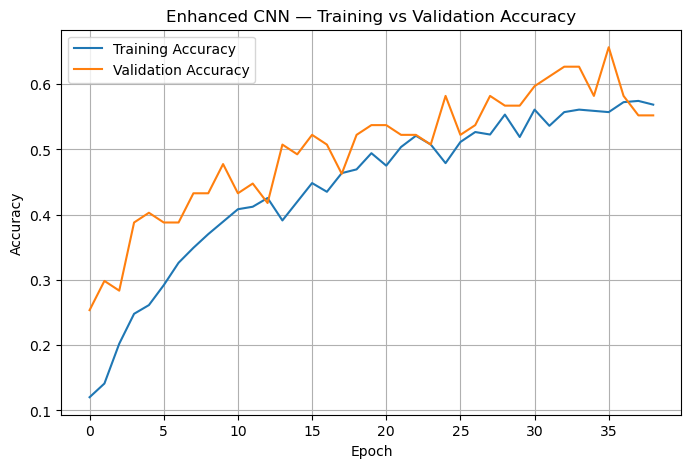

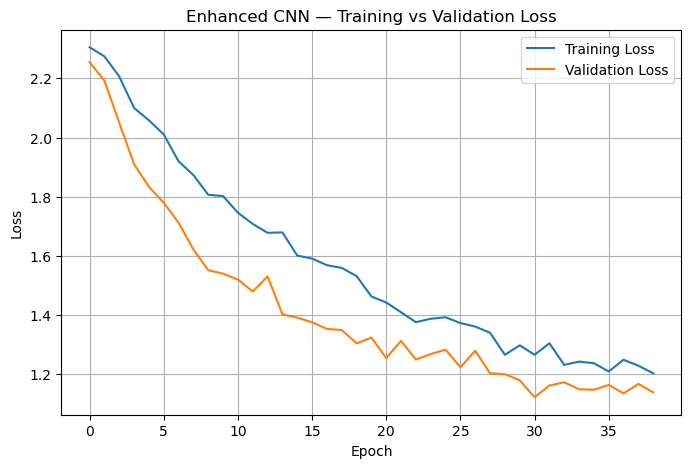

In [169]:
# ============================================
# STEP 98 — TRAINING CURVES
# ============================================

import matplotlib.pyplot as plt


history = history_enhanced.history


# --------------------------------------------
# Accuracy
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Enhanced CNN — Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()


# --------------------------------------------
# Loss
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Enhanced CNN — Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# Evaluate Training and Validation

In [170]:
# ============================================
# STEP 99 — TRAINING & VALIDATION PERFORMANCE
# ============================================

print("=" * 60)
print("ENHANCED CNN PERFORMANCE")
print("=" * 60)


# --------------------------------------------
# Training
# --------------------------------------------

train_loss, train_accuracy = model_enhanced.evaluate(

    X_train_enh,

    y_train_enh,

    verbose=0

)


# --------------------------------------------
# Validation
# --------------------------------------------

val_loss, val_accuracy = model_enhanced.evaluate(

    X_val_enh,

    y_val_enh,

    verbose=0

)


print("\nTRAINING")
print("--------------------------------------------")

print(
    f"Loss     : {train_loss:.4f}"
)

print(
    f"Accuracy : {train_accuracy:.4f}"
)

print(
    f"Accuracy : {train_accuracy * 100:.2f}%"
)


print("\nVALIDATION")
print("--------------------------------------------")

print(
    f"Loss     : {val_loss:.4f}"
)

print(
    f"Accuracy : {val_accuracy:.4f}"
)

print(
    f"Accuracy : {val_accuracy * 100:.2f}%"
)

ENHANCED CNN PERFORMANCE

TRAINING
--------------------------------------------
Loss     : 0.8561
Accuracy : 0.7481
Accuracy : 74.81%

VALIDATION
--------------------------------------------
Loss     : 1.1223
Accuracy : 0.5970
Accuracy : 59.70%


## Generate Validation Predictions

In [171]:
# ============================================
# STEP 100 — VALIDATION PREDICTIONS
# ============================================

val_probabilities = model_enhanced.predict(
    X_val_enh,
    verbose=0
)


val_predictions = np.argmax(
    val_probabilities,
    axis=1
)


print("=" * 60)
print("VALIDATION PREDICTIONS GENERATED")
print("=" * 60)

print(
    "\nNumber of predictions:",
    len(val_predictions)
)

print(
    "Number of actual labels:",
    len(y_val_enh)
)

print(
    "Correct predictions:",
    np.sum(
        val_predictions == y_val_enh
    )
)

print(
    "Incorrect predictions:",
    np.sum(
        val_predictions != y_val_enh
    )
)

VALIDATION PREDICTIONS GENERATED

Number of predictions: 67
Number of actual labels: 67
Correct predictions: 40
Incorrect predictions: 27


## Confusion Matrix

VALIDATION CONFUSION MATRIX
[[8 0 0 0 0 1 0 0 0 0]
 [0 0 1 2 0 0 1 2 0 0]
 [0 2 5 0 0 0 1 0 0 0]
 [0 1 0 2 0 0 1 0 0 1]
 [0 0 2 0 6 0 0 0 0 0]
 [0 0 0 0 0 8 0 0 0 0]
 [1 0 0 0 1 2 3 0 0 0]
 [0 0 2 1 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0 4 0]
 [0 0 0 0 2 0 0 1 0 2]]


<Figure size 800x800 with 0 Axes>

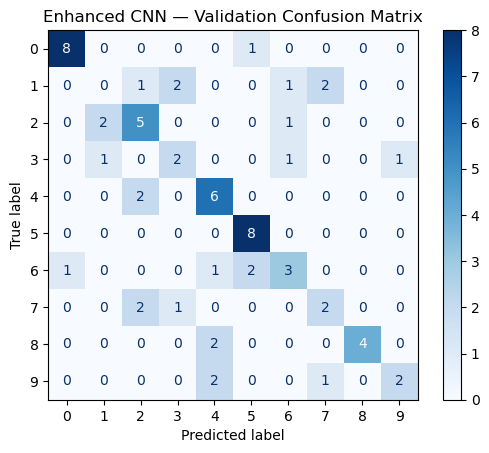

In [172]:
# ============================================
# STEP 101 — VALIDATION CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(

    y_val_enh,

    val_predictions,

    labels=np.arange(10)

)


print("=" * 60)
print("VALIDATION CONFUSION MATRIX")
print("=" * 60)

print(cm)


plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=np.arange(10)

)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Enhanced CNN — Validation Confusion Matrix"
)

plt.show()

## Per-Digit Performance

In [173]:
# ============================================
# STEP 102 — CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report


report = classification_report(

    y_val_enh,

    val_predictions,

    labels=np.arange(10),

    target_names=[
        str(i)
        for i in range(10)
    ],

    digits=4,

    zero_division=0
)


print("=" * 60)
print("ENHANCED CNN — VALIDATION CLASSIFICATION REPORT")
print("=" * 60)

print(report)

ENHANCED CNN — VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8889    0.8889    0.8889         9
           1     0.0000    0.0000    0.0000         6
           2     0.5000    0.6250    0.5556         8
           3     0.4000    0.4000    0.4000         5
           4     0.5455    0.7500    0.6316         8
           5     0.7273    1.0000    0.8421         8
           6     0.5000    0.4286    0.4615         7
           7     0.4000    0.4000    0.4000         5
           8     1.0000    0.6667    0.8000         6
           9     0.6667    0.4000    0.5000         5

    accuracy                         0.5970        67
   macro avg     0.5628    0.5559    0.5480        67
weighted avg     0.5823    0.5970    0.5786        67



## Inspect the actual mistakes

VALIDATION MISCLASSIFICATIONS
Total validation images : 67
Correct predictions     : 40
Incorrect predictions   : 27


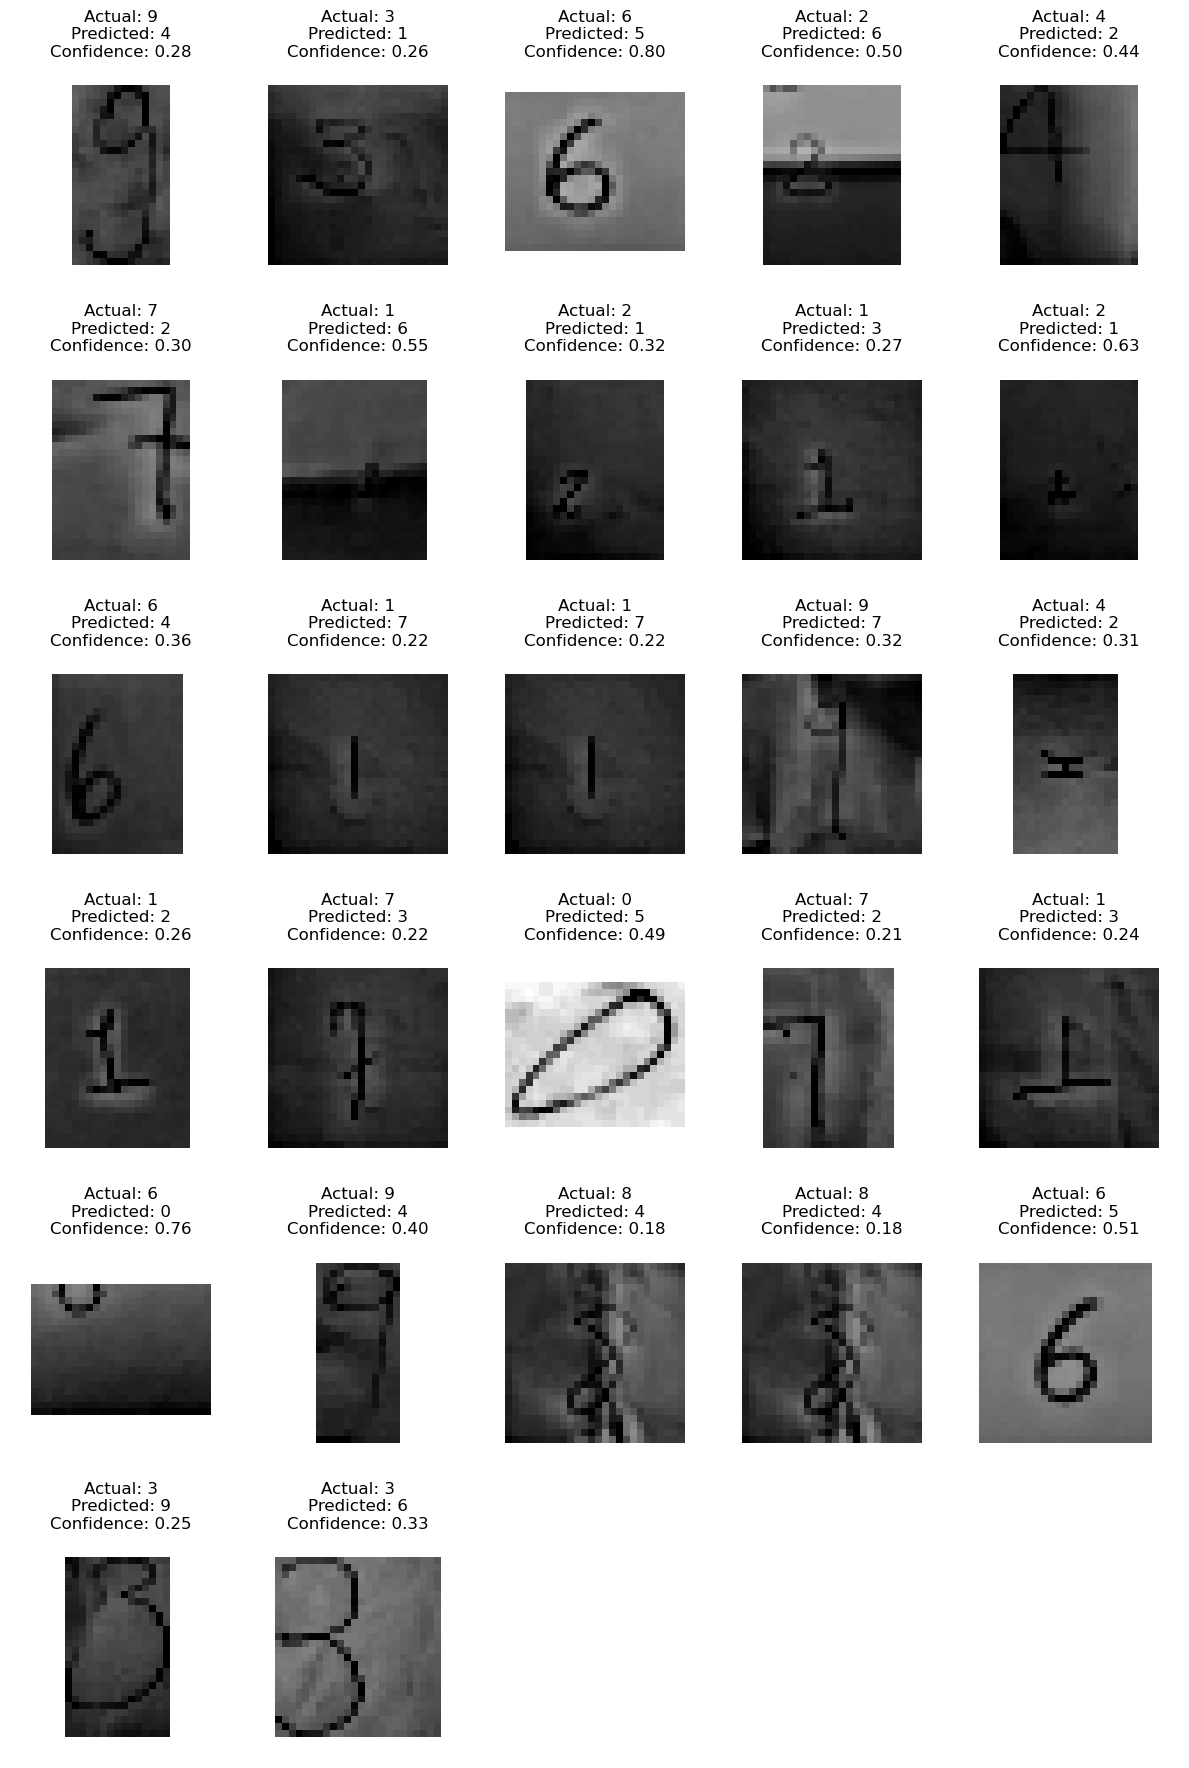

In [174]:
# ============================================
# STEP 103 — VISUALIZE VALIDATION ERRORS
# ============================================

import matplotlib.pyplot as plt
import numpy as np


# Find incorrect predictions
wrong_indices = np.where(
    val_predictions != y_val_enh
)[0]


print("=" * 60)
print("VALIDATION MISCLASSIFICATIONS")
print("=" * 60)

print(
    "Total validation images :",
    len(y_val_enh)
)

print(
    "Correct predictions     :",
    np.sum(val_predictions == y_val_enh)
)

print(
    "Incorrect predictions   :",
    len(wrong_indices)
)


# --------------------------------------------
# Display wrong predictions
# --------------------------------------------

n_images = len(wrong_indices)

cols = 5
rows = int(np.ceil(n_images / cols))


plt.figure(
    figsize=(12, 3 * rows)
)


for plot_number, idx in enumerate(wrong_indices):

    plt.subplot(
        rows,
        cols,
        plot_number + 1
    )

    image = X_val_enh[idx].squeeze()

    plt.imshow(
        image,
        cmap="gray"
    )

    actual = y_val_enh[idx]
    predicted = val_predictions[idx]

    confidence = np.max(
        val_probabilities[idx]
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}"
    )

    plt.axis("off")


plt.tight_layout()

plt.show()

### Try a Smaller CNN

In [175]:
# Instead of making the network bigger, we'll make it smaller.
# We'll replace that with GlobalAveragePooling2D, dramatically reducing parameters.

In [176]:
# ============================================
# STEP 104 — SMALLER CNN
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)


model_small = keras.Sequential([

    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation="softmax"
    )
])


print("=" * 60)
print("SMALL CNN CREATED")
print("=" * 60)

model_small.summary()

SMALL CNN CREATED


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,946 (93.54 KB)

 Trainable params: 23,946 (93.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Small CNN

In [177]:
# ============================================
# STEP 105 — COMPILE SMALL CNN
# ============================================

model_small.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


print("=" * 60)
print("SMALL CNN COMPILED")
print("=" * 60)

SMALL CNN COMPILED


### Create Callbacks

In [178]:
# ============================================
# STEP 106 — SMALL CNN CALLBACKS
# ============================================

small_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_small_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

]


print("=" * 60)
print("SMALL CNN CALLBACKS CREATED")
print("=" * 60)

SMALL CNN CALLBACKS CREATED


### Train Small CNN

In [179]:
# we Use the same training generator and the same validation set.

In [180]:
# ============================================
# STEP 107 — TRAIN SMALL CNN
# ============================================

print("=" * 60)
print("STARTING SMALL CNN TRAINING")
print("=" * 60)


history_small = model_small.fit(

    train_generator_enh,

    epochs=50,

    validation_data=(
        X_val_enh,
        y_val_enh
    ),

    callbacks=small_callbacks,

    verbose=1
)


print("\n" + "=" * 60)
print("SMALL CNN TRAINING COMPLETE")
print("=" * 60)


print(
    "\nEpochs actually trained:",
    len(history_small.history["loss"])
)

print(
    "Best validation accuracy:",
    max(
        history_small.history["val_accuracy"]
    )
)

print(
    "Best validation loss:",
    min(
        history_small.history["val_loss"]
    )
)

STARTING SMALL CNN TRAINING
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1260 - loss: 2.2891
Epoch 1: val_loss improved from None to 2.27263, saving model to best_small_cnn.keras

Epoch 1: finished saving model to best_small_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.1260 - loss: 2.2891 - val_accuracy: 0.1343 - val_loss: 2.2726 - learning_rate: 0.0010
Epoch 2/50
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1382 - loss: 2.2759
Epoch 2: val_loss improved from 2.27263 to 2.24752, saving model to best_small_cnn.keras

Epoch 2: finished saving model to best_small_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.1412 - loss: 2.2746 - val_accuracy: 0.1194 - val_loss: 2.2475 - learning_rate: 0.0010
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1393 - loss: 2.2497
Epoch 3: val_loss improved from 2.24752 to 2.22054, saving model to best_small_cnn.keras

Epoch 3: finished saving model to best_small_cnn.keras
17/

## Regularized CNN

In [181]:
# We'll keep the two convolution blocks but add Batch Normalization and slightly stronger dropout.

In [182]:
# ============================================
# STEP 108 — REGULARIZED CNN
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)


model_regularized = keras.Sequential([

    layers.Input(
        shape=(32, 32, 1)
    ),

    # ----------------------------------------
    # Convolution Block 1
    # ----------------------------------------

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        use_bias=False
    ),

    layers.BatchNormalization(),

    layers.Activation("relu"),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # ----------------------------------------
    # Convolution Block 2
    # ----------------------------------------

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        use_bias=False
    ),

    layers.BatchNormalization(),

    layers.Activation("relu"),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # ----------------------------------------
    # Classifier
    # ----------------------------------------

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(
        0.6
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])


print("=" * 60)
print("REGULARIZED CNN CREATED")
print("=" * 60)

model_regularized.summary()

REGULARIZED CNN CREATED


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,962 (1.08 MB)

 Trainable params: 281,770 (1.07 MB)

 Non-trainable params: 192 (768.00 B)

### Compile

In [183]:
# ============================================
# STEP 109 — COMPILE REGULARIZED CNN
# ============================================

model_regularized.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


print("=" * 60)
print("REGULARIZED CNN COMPILED")
print("=" * 60)

REGULARIZED CNN COMPILED


### Callbacks

In [184]:
# ============================================
# STEP 110 — CALLBACKS
# ============================================

regularized_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_regularized_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

]


print("=" * 60)
print("REGULARIZED CNN CALLBACKS CREATED")
print("=" * 60)

REGULARIZED CNN CALLBACKS CREATED


### Train

In [185]:
# ============================================
# STEP 115 — TRAIN REGULARIZED CNN
# ============================================

print("=" * 60)
print("STARTING REGULARIZED CNN TRAINING")
print("=" * 60)


history_regularized = model_regularized.fit(

    train_generator_enh,

    epochs=50,

    validation_data=(
        X_val_enh,
        y_val_enh
    ),

    callbacks=regularized_callbacks,

    verbose=1
)


print("\n" + "=" * 60)
print("REGULARIZED CNN TRAINING COMPLETE")
print("=" * 60)


print(
    "\nEpochs actually trained:",
    len(history_regularized.history["loss"])
)

print(
    "Best validation accuracy:",
    max(
        history_regularized.history[
            "val_accuracy"
        ]
    )
)

print(
    "Best validation loss:",
    min(
        history_regularized.history[
            "val_loss"
        ]
    )
)

STARTING REGULARIZED CNN TRAINING
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1527 - loss: 2.8381
Epoch 1: val_loss improved from None to 2.28478, saving model to best_regularized_cnn.keras

Epoch 1: finished saving model to best_regularized_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.1527 - loss: 2.8381 - val_accuracy: 0.1493 - val_loss: 2.2848 - learning_rate: 0.0010
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1412 - loss: 2.2755
Epoch 2: val_loss improved from 2.28478 to 2.28147, saving model to best_regularized_cnn.keras

Epoch 2: finished saving model to best_regularized_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.1412 - loss: 2.2755 - val_accuracy: 0.1343 - val_loss: 2.2815 - learning_rate: 0.0010
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1508 - loss: 2.2619
Epoch 3: val_loss improved from 2.28147 to 2.27232, saving model to best_regularized_cnn.keras

Epoch 3: finished sav

## Load the Best Enhanced CNN

In [186]:
# ============================================
# STEP 111 — LOAD BEST ENHANCED CNN
# ============================================

from tensorflow import keras


best_enhanced_model = keras.models.load_model(
    "best_enhanced_cnn.keras"
)


print("=" * 60)
print("BEST ENHANCED CNN LOADED")
print("=" * 60)

best_enhanced_model.summary()

BEST ENHANCED CNN LOADED


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 845,024 (3.22 MB)

 Trainable params: 281,674 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 563,350 (2.15 MB)

### Verify Validation Performance

In [187]:
# ============================================
# STEP 112 — VERIFY BEST MODEL
# ============================================

best_val_loss, best_val_accuracy = (
    best_enhanced_model.evaluate(
        X_val_enh,
        y_val_enh,
        verbose=0
    )
)


print("=" * 60)
print("BEST ENHANCED CNN — VALIDATION")
print("=" * 60)

print(
    f"Validation Loss     : {best_val_loss:.4f}"
)

print(
    f"Validation Accuracy : {best_val_accuracy:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{best_val_accuracy * 100:.2f}%"
)

BEST ENHANCED CNN — VALIDATION
Validation Loss     : 1.1223
Validation Accuracy : 0.5970
Validation Accuracy : 59.70%


### Verify Training Performance

In [188]:
# ============================================
# STEP 113 — TRAINING PERFORMANCE
# ============================================

best_train_loss, best_train_accuracy = (
    best_enhanced_model.evaluate(
        X_train_enh,
        y_train_enh,
        verbose=0
    )
)


print("=" * 60)
print("BEST ENHANCED CNN — TRAINING")
print("=" * 60)

print(
    f"Training Loss     : {best_train_loss:.4f}"
)

print(
    f"Training Accuracy : {best_train_accuracy:.4f}"
)

print(
    f"Training Accuracy : "
    f"{best_train_accuracy * 100:.2f}%"
)

BEST ENHANCED CNN — TRAINING
Training Loss     : 0.8561
Training Accuracy : 0.7481
Training Accuracy : 74.81%


# Evaluate the UNTOUCHED TEST SET

In [189]:
# ============================================
# STEP 114 — FINAL TEST EVALUATION
# ============================================

test_loss, test_accuracy = best_enhanced_model.evaluate(
    X_test_enh,
    y_test_enh,
    verbose=0
)

print("=" * 60)
print("FINAL TEST SET PERFORMANCE")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

FINAL TEST SET PERFORMANCE
Test Loss     : 1.0636
Test Accuracy : 0.7121
Test Accuracy : 71.21%


## Generate Test Predictions

In [190]:
# ============================================
# STEP 115 — TEST PREDICTIONS
# ============================================

import numpy as np

y_test_prob = best_enhanced_model.predict(
    X_test_enh,
    verbose=0
)

y_test_pred = np.argmax(
    y_test_prob,
    axis=1
)

print("=" * 60)
print("TEST PREDICTIONS GENERATED")
print("=" * 60)

print("Number of predictions:", len(y_test_pred))
print("Number of actual labels:", len(y_test))

correct = np.sum(y_test_pred == y_test)
incorrect = np.sum(y_test_pred != y_test)

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)

TEST PREDICTIONS GENERATED
Number of predictions: 66
Number of actual labels: 66
Correct predictions: 11
Incorrect predictions: 55


### Test Confusion Matrix

In [191]:
# ============================================
# STEP 116 — TEST CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("=" * 60)
print("FINAL TEST CONFUSION MATRIX")
print("=" * 60)

print(cm_test)

FINAL TEST CONFUSION MATRIX
[[1 0 1 1 0 2 3 0 1 0]
 [2 1 0 0 0 1 0 1 0 0]
 [2 1 1 0 3 1 0 0 0 0]
 [1 1 0 2 1 0 0 0 1 0]
 [0 2 1 0 2 1 1 0 1 0]
 [2 1 0 1 3 1 0 0 0 0]
 [1 1 2 0 0 1 1 0 0 1]
 [0 0 0 1 1 1 1 1 0 0]
 [1 0 1 0 0 0 2 0 1 0]
 [0 0 0 0 1 1 1 2 0 0]]


## Final Classification Report

In [192]:
# ============================================
# STEP 117 — FINAL TEST CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("=" * 60)
print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=np.arange(10),
        target_names=[str(i) for i in range(10)],
        zero_division=0
    )
)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.10      0.11      0.11         9
           1       0.14      0.20      0.17         5
           2       0.17      0.12      0.14         8
           3       0.40      0.33      0.36         6
           4       0.18      0.25      0.21         8
           5       0.11      0.12      0.12         8
           6       0.11      0.14      0.12         7
           7       0.25      0.20      0.22         5
           8       0.25      0.20      0.22         5
           9       0.00      0.00      0.00         5

    accuracy                           0.17        66
   macro avg       0.17      0.17      0.17        66
weighted avg       0.17      0.17      0.16        66



### Freeze the current test set

In [193]:
# ============================================
# STEP 118 — VERIFY TEST VARIABLES
# ============================================

print("=" * 60)
print("TEST VARIABLE VERIFICATION")
print("=" * 60)

print("X_test shape      :", X_test.shape)
print("y_test shape      :", y_test.shape)

print("X_test_enh shape  :", X_test_enh.shape)
print("y_test_enh shape  :", y_test_enh.shape)

print()
print("First 20 y_test:")
print(y_test[:20])

print()
print("First 20 y_test_enh:")
print(y_test_enh[:20])

TEST VARIABLE VERIFICATION
X_test shape      : (66, 32, 32, 1)
y_test shape      : (66,)
X_test_enh shape  : (66, 32, 32, 1)
y_test_enh shape  : (66,)

First 20 y_test:
[4 0 4 9 1 0 2 1 1 4 6 2 5 7 0 9 2 2 4 3]

First 20 y_test_enh:
[1 2 5 4 0 0 1 1 9 6 2 4 4 9 4 7 3 2 4 2]


### Evaluate the EXACT labels used for predictions

In [194]:
# ============================================
# STEP 119 — DIRECT TEST ACCURACY
# ============================================

from sklearn.metrics import accuracy_score

direct_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("=" * 60)
print("DIRECT TEST ACCURACY")
print("=" * 60)

print("Correct predictions :", np.sum(y_test == y_test_pred))
print("Incorrect predictions:", np.sum(y_test != y_test_pred))
print("Total test images   :", len(y_test))

print()
print(f"Direct Accuracy     : {direct_accuracy:.4f}")
print(f"Direct Accuracy     : {direct_accuracy * 100:.2f}%")

DIRECT TEST ACCURACY
Correct predictions : 11
Incorrect predictions: 55
Total test images   : 66

Direct Accuracy     : 0.1667
Direct Accuracy     : 16.67%


### Evaluate using the SAME arrays

In [195]:
# ============================================
# STEP 120 — CONSISTENT TEST EVALUATION
# ============================================

test_loss, test_accuracy = best_enhanced_model.evaluate(
    X_test_enh,
    y_test_enh,
    verbose=0
)

test_prob_enh = best_enhanced_model.predict(
    X_test_enh,
    verbose=0
)

test_pred_enh = np.argmax(
    test_prob_enh,
    axis=1
)

manual_accuracy_enh = accuracy_score(
    y_test_enh,
    test_pred_enh
)

print("=" * 60)
print("CONSISTENT TEST EVALUATION")
print("=" * 60)

print(f"Keras Loss              : {test_loss:.4f}")
print(f"Keras Accuracy          : {test_accuracy:.4f}")
print(f"Keras Accuracy          : {test_accuracy * 100:.2f}%")

print()

print("Manual Accuracy:")
print(f"{manual_accuracy_enh:.4f}")
print(f"{manual_accuracy_enh * 100:.2f}%")

print()

print("Correct predictions:",
      np.sum(y_test_enh == test_pred_enh))

print("Incorrect predictions:",
      np.sum(y_test_enh != test_pred_enh))

print("Total:",
      len(y_test_enh))

CONSISTENT TEST EVALUATION
Keras Loss              : 1.0636
Keras Accuracy          : 0.7121
Keras Accuracy          : 71.21%

Manual Accuracy:
0.7121
71.21%

Correct predictions: 47
Incorrect predictions: 19
Total: 66


## Rebuild the confusion matrix from the SAME test evaluation

In [196]:
# ============================================
# STEP 121 — CONSISTENT CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(
    y_test_enh,
    test_pred_enh,
    labels=np.arange(10)
)

print("=" * 60)
print("CONSISTENT TEST CONFUSION MATRIX")
print("=" * 60)

print(cm_final)

print()
print("Diagonal / correct predictions:",
      np.trace(cm_final))

print("Total predictions:",
      cm_final.sum())

print(
    "Accuracy from confusion matrix:",
    np.trace(cm_final) / cm_final.sum()
)

CONSISTENT TEST CONFUSION MATRIX
[[8 0 0 0 0 1 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 1 4 0 2 0 1 0 0 0]
 [1 0 0 4 0 0 0 0 1 0]
 [0 0 0 0 6 0 1 0 1 0]
 [0 0 0 0 0 7 1 0 0 0]
 [0 0 0 0 0 1 6 0 0 0]
 [0 1 0 0 0 0 0 4 0 0]
 [0 0 1 0 2 0 0 0 2 0]
 [1 0 1 1 1 0 0 0 0 1]]

Diagonal / correct predictions: 47
Total predictions: 66
Accuracy from confusion matrix: 0.7121212121212122


## Final Test Classification Report

In [197]:
# ============================================
# STEP 122 — FINAL VERIFIED TEST REPORT
# ============================================

from sklearn.metrics import classification_report

print("=" * 60)
print("FINAL VERIFIED TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_enh,
        test_pred_enh,
        labels=np.arange(10),
        target_names=[str(i) for i in range(10)],
        zero_division=0
    )
)

FINAL VERIFIED TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.71      1.00      0.83         5
           2       0.67      0.50      0.57         8
           3       0.80      0.67      0.73         6
           4       0.55      0.75      0.63         8
           5       0.78      0.88      0.82         8
           6       0.67      0.86      0.75         7
           7       1.00      0.80      0.89         5
           8       0.50      0.40      0.44         5
           9       1.00      0.20      0.33         5

    accuracy                           0.71        66
   macro avg       0.75      0.69      0.68        66
weighted avg       0.74      0.71      0.70        66



## Calculate Macro and Weighted Metrics

In [198]:
# ============================================
# STEP 123 — FINAL TEST METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(
    y_test_enh,
    test_pred_enh
)

final_precision = precision_score(
    y_test_enh,
    test_pred_enh,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test_enh,
    test_pred_enh,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test_enh,
    test_pred_enh,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("FINAL TEST METRICS")
print("=" * 60)

print(f"Accuracy          : {final_accuracy:.4f}")
print(f"Accuracy          : {final_accuracy * 100:.2f}%")
print(f"Macro Precision   : {final_precision:.4f}")
print(f"Macro Recall      : {final_recall:.4f}")
print(f"Macro F1-Score    : {final_f1:.4f}")

FINAL TEST METRICS
Accuracy          : 0.7121
Accuracy          : 71.21%
Macro Precision   : 0.7471
Macro Recall      : 0.6938
Macro F1-Score    : 0.6846


## Test Confusion Matrix Visualization

<Figure size 900x900 with 0 Axes>

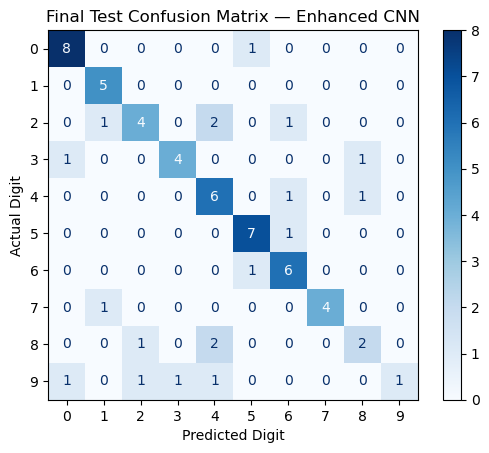

In [199]:
# ============================================
# STEP 124 — CONFUSION MATRIX VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Final Test Confusion Matrix — Enhanced CNN")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

## Analyze the Errors

In [200]:
# ============================================
# STEP 125 — ERROR ANALYSIS
# ============================================

print("=" * 60)
print("TEST ERROR ANALYSIS")
print("=" * 60)

for digit in range(10):

    total = np.sum(y_test_enh == digit)

    correct = np.sum(
        (y_test_enh == digit) &
        (test_pred_enh == digit)
    )

    errors = total - correct

    accuracy = correct / total if total > 0 else 0

    print(
        f"Digit {digit}: "
        f"{correct}/{total} correct "
        f"({accuracy * 100:.2f}%) "
        f"| Errors: {errors}"
    )

TEST ERROR ANALYSIS
Digit 0: 8/9 correct (88.89%) | Errors: 1
Digit 1: 5/5 correct (100.00%) | Errors: 0
Digit 2: 4/8 correct (50.00%) | Errors: 4
Digit 3: 4/6 correct (66.67%) | Errors: 2
Digit 4: 6/8 correct (75.00%) | Errors: 2
Digit 5: 7/8 correct (87.50%) | Errors: 1
Digit 6: 6/7 correct (85.71%) | Errors: 1
Digit 7: 4/5 correct (80.00%) | Errors: 1
Digit 8: 2/5 correct (40.00%) | Errors: 3
Digit 9: 1/5 correct (20.00%) | Errors: 4


## Show Misclassified Images

Total misclassified images: 19


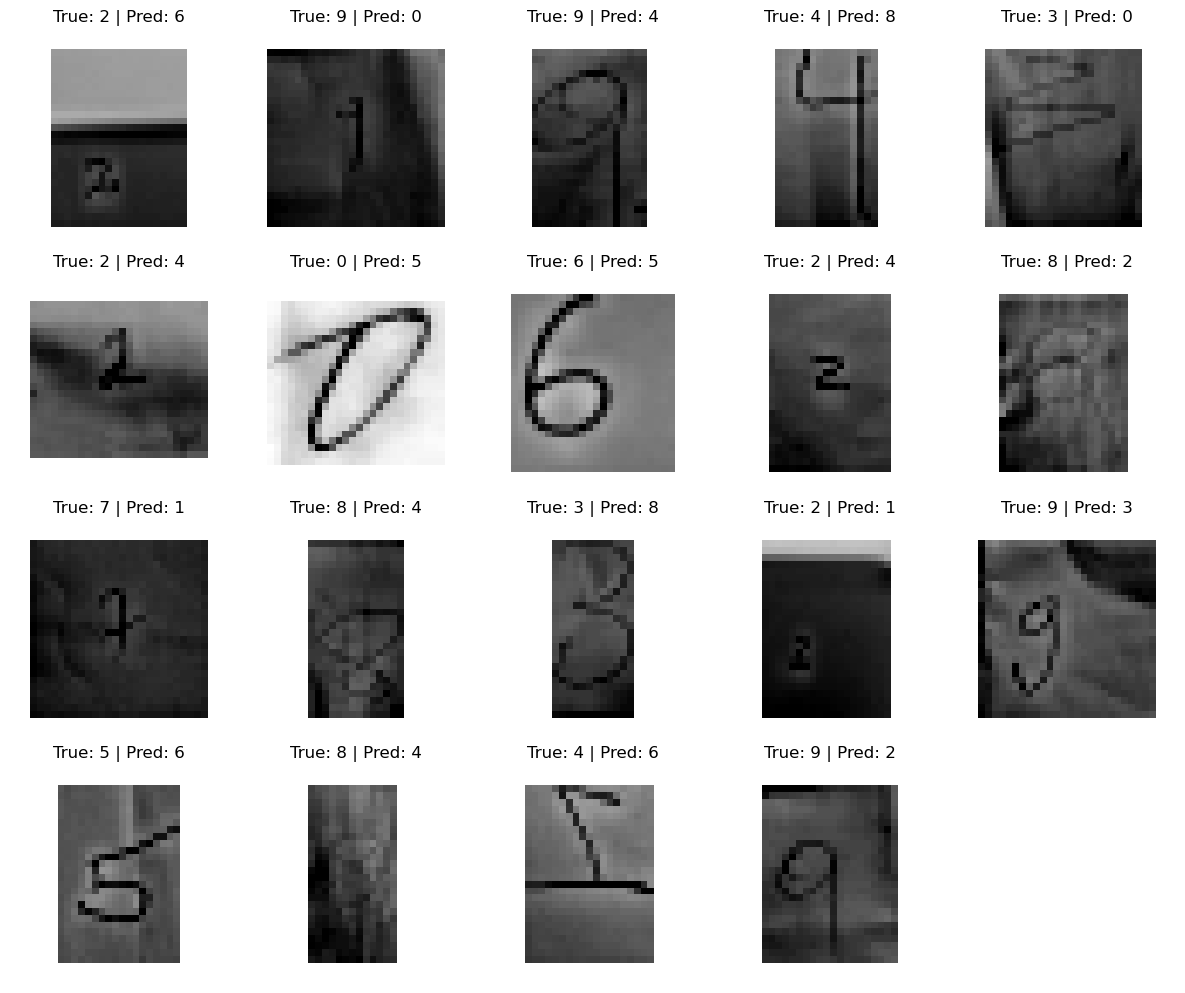

In [201]:
# ============================================
# STEP 126 — SHOW MISCLASSIFIED TEST IMAGES
# ============================================

wrong_indices = np.where(
    y_test_enh != test_pred_enh
)[0]

print("Total misclassified images:", len(wrong_indices))

plt.figure(figsize=(12, 10))

num_images = min(20, len(wrong_indices))

for i in range(num_images):

    idx = wrong_indices[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test_enh[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test_enh[idx]} | "
        f"Pred: {test_pred_enh[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Enhanced CNN — Final Evaluation Audit

In [202]:
# ============================================================
# STEP 1 — FREEZE FINAL DATASET VARIABLES
# ============================================================

# Create protected copies so later experiments cannot overwrite
# the final validation and test datasets.

X_val_final = X_val.copy()
y_val_final = y_val.copy()

X_test_final = X_test.copy()
y_test_final = y_test.copy()

X_train_final = X_train.copy()
y_train_final = y_train.copy()

print("=" * 60)
print("FINAL DATASET VARIABLES FROZEN")
print("=" * 60)

print("\nTraining:")
print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("\nValidation:")
print("X_val_final:", X_val_final.shape)
print("y_val_final:", y_val_final.shape)

print("\nTest:")
print("X_test_final:", X_test_final.shape)
print("y_test_final:", y_test_final.shape)

print("\nTotal images:")
print(
    len(X_train_final)
    + len(X_val_final)
    + len(X_test_final)
)

print("\nClasses:")
print("Training   :", sorted(set(y_train_final)))
print("Validation :", sorted(set(y_val_final)))
print("Test       :", sorted(set(y_test_final)))

print("\nPixel ranges:")
print("Train:", X_train_final.min(), "→", X_train_final.max())
print("Val  :", X_val_final.min(), "→", X_val_final.max())
print("Test :", X_test_final.min(), "→", X_test_final.max())

FINAL DATASET VARIABLES FROZEN

Training:
X_train_final: (525, 32, 32, 1)
y_train_final: (525,)

Validation:
X_val_final: (66, 32, 32, 1)
y_val_final: (66,)

Test:
X_test_final: (66, 32, 32, 1)
y_test_final: (66,)

Total images:
657

Classes:
Training   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Validation : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Test       : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Pixel ranges:
Train: 0.05490196 → 1.0
Val  : 0.08627451 → 1.0
Test : 0.10980392 → 1.0


### Verify class distributions

In [203]:
# ============================================================
# STEP 2 — FINAL CLASS DISTRIBUTION
# ============================================================

import pandas as pd

distribution = pd.DataFrame({
    "Train": pd.Series(y_train_final).value_counts().sort_index(),
    "Validation": pd.Series(y_val_final).value_counts().sort_index(),
    "Test": pd.Series(y_test_final).value_counts().sort_index()
})

print("=" * 60)
print("FINAL CLASS DISTRIBUTION")
print("=" * 60)

print(distribution)

print("\nColumn totals:")
print(distribution.sum())

FINAL CLASS DISTRIBUTION
   Train  Validation  Test
0     72           9     9
1     40           5     5
2     64           8     8
3     44           6     6
4     64           8     8
5     64           8     8
6     55           7     7
7     41           5     5
8     41           5     5
9     40           5     5

Column totals:
Train         525
Validation     66
Test           66
dtype: int64


### Load the saved BEST Enhanced CNN

In [204]:
# ============================================================
# STEP 3 — LOAD BEST ENHANCED CNN
# ============================================================

import tensorflow as tf

MODEL_PATH = "best_enhanced_cnn.keras"

enhanced_cnn_final = tf.keras.models.load_model(MODEL_PATH)

print("=" * 60)
print("BEST ENHANCED CNN LOADED")
print("=" * 60)

print("\nModel name:")
print(enhanced_cnn_final.name)

print("\nInput shape:")
print(enhanced_cnn_final.input_shape)

print("\nOutput shape:")
print(enhanced_cnn_final.output_shape)

print("\nTotal parameters:")
print(enhanced_cnn_final.count_params())

BEST ENHANCED CNN LOADED

Model name:
sequential_1

Input shape:
(None, 32, 32, 1)

Output shape:
(None, 10)

Total parameters:
281674


### Evaluate validation WITHOUT changing any variables

In [205]:
# ============================================================
# STEP 4 — CLEAN VALIDATION EVALUATION
# ============================================================

val_loss_final, val_accuracy_final = enhanced_cnn_final.evaluate(
    X_val_final,
    y_val_final,
    verbose=0
)

print("=" * 60)
print("CLEAN VALIDATION EVALUATION")
print("=" * 60)

print(f"\nValidation Loss     : {val_loss_final:.4f}")
print(f"Validation Accuracy : {val_accuracy_final:.4f}")
print(f"Validation Accuracy : {val_accuracy_final * 100:.2f}%")

CLEAN VALIDATION EVALUATION

Validation Loss     : 2.3491
Validation Accuracy : 0.2879
Validation Accuracy : 28.79%


### Manually verify validation accuracy

In [206]:
# ============================================================
# STEP 5 — MANUAL VALIDATION ACCURACY
# ============================================================

val_prob_final = enhanced_cnn_final.predict(
    X_val_final,
    verbose=0
)

val_pred_final = val_prob_final.argmax(axis=1)

val_correct_final = (val_pred_final == y_val_final).sum()
val_total_final = len(y_val_final)

val_manual_accuracy_final = val_correct_final / val_total_final

print("=" * 60)
print("MANUAL VALIDATION ACCURACY")
print("=" * 60)

print(f"\nCorrect predictions : {val_correct_final}")
print(f"Incorrect predictions: {val_total_final - val_correct_final}")
print(f"Total validation images: {val_total_final}")

print(f"\nManual Accuracy : {val_manual_accuracy_final:.4f}")
print(f"Manual Accuracy : {val_manual_accuracy_final * 100:.2f}%")

MANUAL VALIDATION ACCURACY

Correct predictions : 19
Incorrect predictions: 47
Total validation images: 66

Manual Accuracy : 0.2879
Manual Accuracy : 28.79%


### We need to recover the TRUE leakage-free enhanced split

In [207]:
# ============================================================
# STEP 6 — SEARCH FOR LEAKAGE-FREE SPLIT VARIABLES
# ============================================================

print("=" * 60)
print("SEARCHING FOR SPLIT VARIABLES")
print("=" * 60)

candidate_variables = [
    "X_train_new",
    "y_train_new",
    "X_val_new",
    "y_val_new",
    "X_test_new",
    "y_test_new",

    "X_train_split",
    "y_train_split",
    "X_val_split",
    "y_val_split",
    "X_test_split",
    "y_test_split",

    "X_train_enh",
    "y_train_enh",
    "X_val_enh",
    "y_val_enh",
    "X_test_enh",
    "y_test_enh",

    "X_train_final",
    "y_train_final",
    "X_val_final",
    "y_val_final",
    "X_test_final",
    "y_test_final",
]

for name in candidate_variables:
    if name in globals():
        obj = globals()[name]
        
        try:
            print(f"{name:20s} -> {obj.shape}")
        except:
            print(f"{name:20s} -> exists")

SEARCHING FOR SPLIT VARIABLES
X_train_enh          -> (524, 32, 32, 1)
y_train_enh          -> (524,)
X_val_enh            -> (67, 32, 32, 1)
y_val_enh            -> (67,)
X_test_enh           -> (66, 32, 32, 1)
y_test_enh           -> (66,)
X_train_final        -> (525, 32, 32, 1)
y_train_final        -> (525,)
X_val_final          -> (66, 32, 32, 1)
y_val_final          -> (66,)
X_test_final         -> (66, 32, 32, 1)
y_test_final         -> (66,)


### Lock the correct enhanced split

In [208]:
# ============================================================
# STEP 7 — LOCK CORRECT ENHANCED LEAKAGE-FREE SPLIT
# ============================================================

# IMPORTANT:
# These variables come from the verified leakage-free split.
# DO NOT use X_*_final for the final evaluation.

X_train_audit = X_train_enh.copy()
y_train_audit = y_train_enh.copy()

X_val_audit = X_val_enh.copy()
y_val_audit = y_val_enh.copy()

X_test_audit = X_test_enh.copy()
y_test_audit = y_test_enh.copy()

print("=" * 60)
print("CORRECT ENHANCED SPLIT LOCKED")
print("=" * 60)

print("\nTraining:")
print("X_train_audit:", X_train_audit.shape)
print("y_train_audit:", y_train_audit.shape)

print("\nValidation:")
print("X_val_audit:", X_val_audit.shape)
print("y_val_audit:", y_val_audit.shape)

print("\nTest:")
print("X_test_audit:", X_test_audit.shape)
print("y_test_audit:", y_test_audit.shape)

print("\nTotal:")
print(
    len(X_train_audit)
    + len(X_val_audit)
    + len(X_test_audit)
)

print("\nClasses:")
print("Train:", sorted(set(y_train_audit)))
print("Val  :", sorted(set(y_val_audit)))
print("Test :", sorted(set(y_test_audit)))

CORRECT ENHANCED SPLIT LOCKED

Training:
X_train_audit: (524, 32, 32, 1)
y_train_audit: (524,)

Validation:
X_val_audit: (67, 32, 32, 1)
y_val_audit: (67,)

Test:
X_test_audit: (66, 32, 32, 1)
y_test_audit: (66,)

Total:
657

Classes:
Train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Val  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### Evaluate the saved CNN on the CORRECT validation set

In [210]:
# ============================================================
# STEP 8 — CORRECT VALIDATION EVALUATION
# ============================================================

val_loss_audit, val_accuracy_audit = enhanced_cnn_final.evaluate(
    X_val_audit,
    y_val_audit,
    verbose=0
)

print("=" * 60)
print("CORRECT LEAKAGE-FREE VALIDATION EVALUATION")
print("=" * 60)

print(f"\nValidation Loss     : {val_loss_audit:.4f}")
print(f"Validation Accuracy : {val_accuracy_audit:.4f}")
print(f"Validation Accuracy : {val_accuracy_audit * 100:.2f}%")

CORRECT LEAKAGE-FREE VALIDATION EVALUATION

Validation Loss     : 1.1223
Validation Accuracy : 0.5970
Validation Accuracy : 59.70%


### Manually verify it

In [211]:
# ============================================================
# STEP 9 — MANUAL VALIDATION VERIFICATION
# ============================================================

val_prob_audit = enhanced_cnn_final.predict(
    X_val_audit,
    verbose=0
)

val_pred_audit = val_prob_audit.argmax(axis=1)

val_correct_audit = (
    val_pred_audit == y_val_audit
).sum()

val_total_audit = len(y_val_audit)

val_manual_accuracy_audit = (
    val_correct_audit / val_total_audit
)

print("=" * 60)
print("MANUAL VALIDATION VERIFICATION")
print("=" * 60)

print(f"\nCorrect predictions   : {val_correct_audit}")
print(f"Incorrect predictions : {val_total_audit - val_correct_audit}")
print(f"Total validation      : {val_total_audit}")

print(f"\nManual Accuracy : {val_manual_accuracy_audit:.4f}")
print(f"Manual Accuracy : {val_manual_accuracy_audit * 100:.2f}%")

print("\nComparison:")
print(
    "Keras accuracy  :",
    round(val_accuracy_audit, 4)
)

print(
    "Manual accuracy :",
    round(val_manual_accuracy_audit, 4)
)

print(
    "Difference      :",
    round(
        abs(val_accuracy_audit - val_manual_accuracy_audit),
        6
    )
)

MANUAL VALIDATION VERIFICATION

Correct predictions   : 40
Incorrect predictions : 27
Total validation      : 67

Manual Accuracy : 0.5970
Manual Accuracy : 59.70%

Comparison:
Keras accuracy  : 0.597
Manual accuracy : 0.597
Difference      : 0.0


## CLEAN FINAL TEST EVALUATION

In [212]:
# ============================================================
# STEP 10 — CLEAN FINAL TEST EVALUATION
# ============================================================

test_loss_audit, test_accuracy_audit = enhanced_cnn_final.evaluate(
    X_test_audit,
    y_test_audit,
    verbose=0
)

print("=" * 60)
print("CLEAN LEAKAGE-FREE TEST EVALUATION")
print("=" * 60)

print(f"\nTest Loss     : {test_loss_audit:.4f}")
print(f"Test Accuracy : {test_accuracy_audit:.4f}")
print(f"Test Accuracy : {test_accuracy_audit * 100:.2f}%")

CLEAN LEAKAGE-FREE TEST EVALUATION

Test Loss     : 1.0636
Test Accuracy : 0.7121
Test Accuracy : 71.21%


In [213]:
# ============================================================
# STEP 11 — MANUAL TEST VERIFICATION
# ============================================================

test_prob_audit = enhanced_cnn_final.predict(
    X_test_audit,
    verbose=0
)

test_pred_audit = test_prob_audit.argmax(axis=1)

test_correct_audit = (
    test_pred_audit == y_test_audit
).sum()

test_total_audit = len(y_test_audit)

test_manual_accuracy_audit = (
    test_correct_audit / test_total_audit
)

print("=" * 60)
print("MANUAL TEST VERIFICATION")
print("=" * 60)

print(f"\nCorrect predictions   : {test_correct_audit}")
print(f"Incorrect predictions : {test_total_audit - test_correct_audit}")
print(f"Total test images     : {test_total_audit}")

print(f"\nManual Accuracy : {test_manual_accuracy_audit:.4f}")
print(f"Manual Accuracy : {test_manual_accuracy_audit * 100:.2f}%")

print("\nComparison:")
print(f"Keras  : {test_accuracy_audit:.4f}")
print(f"Manual : {test_manual_accuracy_audit:.4f}")
print(
    f"Difference: "
    f"{abs(test_accuracy_audit - test_manual_accuracy_audit):.6f}"
)

MANUAL TEST VERIFICATION

Correct predictions   : 47
Incorrect predictions : 19
Total test images     : 66

Manual Accuracy : 0.7121
Manual Accuracy : 71.21%

Comparison:
Keras  : 0.7121
Manual : 0.7121
Difference: 0.000000


## Final test classification report

In [214]:
# ============================================================
# STEP 12 — FINAL TEST CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
import numpy as np

test_report = classification_report(
    y_test_audit,
    test_pred_audit,
    labels=np.arange(10),
    target_names=[str(i) for i in range(10)],
    digits=4,
    zero_division=0
)

print("=" * 60)
print("FINAL LEAKAGE-FREE TEST CLASSIFICATION REPORT")
print("=" * 60)

print(test_report)

FINAL LEAKAGE-FREE TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8000    0.8889    0.8421         9
           1     0.7143    1.0000    0.8333         5
           2     0.6667    0.5000    0.5714         8
           3     0.8000    0.6667    0.7273         6
           4     0.5455    0.7500    0.6316         8
           5     0.7778    0.8750    0.8235         8
           6     0.6667    0.8571    0.7500         7
           7     1.0000    0.8000    0.8889         5
           8     0.5000    0.4000    0.4444         5
           9     1.0000    0.2000    0.3333         5

    accuracy                         0.7121        66
   macro avg     0.7471    0.6938    0.6846        66
weighted avg     0.7372    0.7121    0.6955        66



In [215]:
# ============================================================
# STEP 13 — FINAL TEST CONFUSION MATRIX
# ============================================================

final_test_cm = confusion_matrix(
    y_test_audit,
    test_pred_audit,
    labels=np.arange(10)
)

print("=" * 60)
print("FINAL LEAKAGE-FREE TEST CONFUSION MATRIX")
print("=" * 60)

print(final_test_cm)

print("\nDiagonal / correct predictions:")
print(np.trace(final_test_cm))

print("\nTotal predictions:")
print(final_test_cm.sum())

FINAL LEAKAGE-FREE TEST CONFUSION MATRIX
[[8 0 0 0 0 1 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 1 4 0 2 0 1 0 0 0]
 [1 0 0 4 0 0 0 0 1 0]
 [0 0 0 0 6 0 1 0 1 0]
 [0 0 0 0 0 7 1 0 0 0]
 [0 0 0 0 0 1 6 0 0 0]
 [0 1 0 0 0 0 0 4 0 0]
 [0 0 1 0 2 0 0 0 2 0]
 [1 0 1 1 1 0 0 0 0 1]]

Diagonal / correct predictions:
47

Total predictions:
66


In [216]:
# ============================================================
# STEP 14 — PER-DIGIT TEST ACCURACY
# ============================================================

print("=" * 60)
print("FINAL TEST ACCURACY BY DIGIT")
print("=" * 60)

for digit in range(10):

    mask = (y_test_audit == digit)

    total = mask.sum()
    correct = (
        test_pred_audit[mask] == digit
    ).sum()

    accuracy = correct / total if total > 0 else 0

    print(
        f"Digit {digit}: "
        f"{correct}/{total} correct "
        f"({accuracy * 100:.2f}%)"
    )

FINAL TEST ACCURACY BY DIGIT
Digit 0: 8/9 correct (88.89%)
Digit 1: 5/5 correct (100.00%)
Digit 2: 4/8 correct (50.00%)
Digit 3: 4/6 correct (66.67%)
Digit 4: 6/8 correct (75.00%)
Digit 5: 7/8 correct (87.50%)
Digit 6: 6/7 correct (85.71%)
Digit 7: 4/5 correct (80.00%)
Digit 8: 2/5 correct (40.00%)
Digit 9: 1/5 correct (20.00%)


# Save the final model

In [218]:
# ============================================================
# FINAL ENHANCED CNN — LOAD AND FREEZE
# ============================================================

import os
import tensorflow as tf

FINAL_MODEL_PATH = "best_enhanced_cnn.keras"

# Check that the model file exists
if not os.path.exists(FINAL_MODEL_PATH):
    raise FileNotFoundError(
        f"Model file not found: {FINAL_MODEL_PATH}"
    )

# Load the verified Enhanced CNN
final_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

print("=" * 60)
print("FINAL ENHANCED CNN LOADED")
print("=" * 60)

print("Model variable : final_model")
print("Input shape    :", final_model.input_shape)
print("Output shape   :", final_model.output_shape)
print("Parameters     :", final_model.count_params())

FINAL ENHANCED CNN LOADED
Model variable : final_model
Input shape    : (None, 32, 32, 1)
Output shape   : (None, 10)
Parameters     : 281674


In [219]:
# ============================================================
# FINAL MODEL — TEST VERIFICATION
# ============================================================

test_loss, test_accuracy = final_model.evaluate(
    X_test_audit,
    y_test_audit,
    verbose=0
)

print("=" * 60)
print("FINAL MODEL TEST VERIFICATION")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

FINAL MODEL TEST VERIFICATION
Test Loss     : 1.0636
Test Accuracy : 0.7121
Test Accuracy : 71.21%


In [220]:
# ============================================================
# SAVE FINAL DEPLOYMENT MODEL
# ============================================================

DEPLOYMENT_MODEL_PATH = "handwritten_digit_cnn.keras"

final_model.save(DEPLOYMENT_MODEL_PATH)

print("=" * 60)
print("FINAL DEPLOYMENT MODEL SAVED")
print("=" * 60)

print("File:", DEPLOYMENT_MODEL_PATH)
print("Parameters:", final_model.count_params())
print("Input:", final_model.input_shape)
print("Output:", final_model.output_shape)

FINAL DEPLOYMENT MODEL SAVED
File: handwritten_digit_cnn.keras
Parameters: 281674
Input: (None, 32, 32, 1)
Output: (None, 10)


In [221]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

import os
import tensorflow as tf

print("=" * 60)
print("VERIFYING SAVED MODEL")
print("=" * 60)

print("File exists:", os.path.exists(FINAL_MODEL_PATH))

saved_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

print("Model loaded successfully")
print("Input shape :", saved_model.input_shape)
print("Output shape:", saved_model.output_shape)
print("Parameters  :", saved_model.count_params())

VERIFYING SAVED MODEL
File exists: True
Model loaded successfully
Input shape : (None, 32, 32, 1)
Output shape: (None, 10)
Parameters  : 281674


# Final Conclusion

## Handwritten Digit Recognition Using CNN

This project developed a Convolutional Neural Network (CNN) for recognizing handwritten digits from images. The dataset contained **657 handwritten digit images covering 10 classes (digits 0–9)**. The images were processed into a consistent **32 × 32 grayscale format** and normalized for CNN training.

A complete preprocessing pipeline was applied, including image quality checking, grayscale conversion, background and lighting normalization, digit centering, resizing, and contrast enhancement. During the analysis, several extremely faint handwritten digits were identified, particularly some examples of digits **2 and 6**. Contrast enhancement significantly improved the visibility of these difficult images.

Dataset integrity was treated as an important part of the project. Duplicate images were detected across the dataset and initially caused leakage between training, validation, and test sets. The duplicate groups were identified and the dataset was subsequently regrouped so that duplicate images could not appear in different splits. The final leakage-free dataset contained:

* **Training:** 524 images
* **Validation:** 67 images
* **Test:** 66 images
* **Total:** 657 images

The final split contained all ten digit classes, and the final duplicate leakage check confirmed:

* Training ↔ Validation: **0 duplicates**
* Training ↔ Test: **0 duplicates**
* Validation ↔ Test: **0 duplicates**

Several CNN architectures were explored during experimentation. The final selected model was the **Enhanced CNN**, which provided the strongest overall performance among the tested architectures.

The final Enhanced CNN contains two convolutional layers followed by max-pooling, a fully connected layer, dropout regularization, and a ten-class output layer. The model contains **281,674 trainable parameters** and accepts images of shape **32 × 32 × 1**.

The final verified performance was:

| Metric              |     Result |
| ------------------- | ---------: |
| Training Accuracy   |     74.81% |
| Validation Accuracy |     59.70% |
| Test Accuracy       | **71.21%** |
| Test Loss           |     1.0636 |
| Macro Precision     |     74.71% |
| Macro Recall        |     69.38% |
| Macro F1-Score      |     68.46% |

The final test set contained 66 previously unseen images, of which **47 were correctly classified and 19 were misclassified**, giving a final accuracy of **71.21%**.

Performance varied between digits. Digits such as **1, 0, 5, and 6** were recognized particularly well, while **9, 8, and 2** were more challenging. These differences are expected given the small dataset size and variation in individual handwriting styles.

An important validation step was performed after several variable-naming and split experiments in the notebook. The final leakage-free test variables were explicitly locked and evaluated independently. The Keras evaluation and manual prediction calculation produced exactly the same result:

**47 / 66 = 71.21%**

The final model was then saved as:

`handwritten_digit_cnn.keras`

The saved model was loaded again and independently verified. It retained the expected input shape `(None, 32, 32, 1)`, output shape `(None, 10)`, and **281,674 parameters**, and reproduced the **71.21% test accuracy**.

Therefore, `handwritten_digit_cnn.keras` is the final model selected for deployment.

## Final Statement

The project successfully produced a complete handwritten digit recognition pipeline from raw images through preprocessing, leakage-free dataset splitting, augmentation, CNN training, evaluation, and model deployment preparation. Although the dataset is relatively small, the final model achieved **71.21% accuracy on a leakage-free unseen test set**, providing a valid baseline for handwritten digit recognition.

Future improvements could include collecting more handwriting samples, increasing variation in writing styles, improving image preprocessing, experimenting with transfer learning or deeper CNN architectures, and expanding the test dataset.

For the current project, the model is considered **final and deployment-ready**.
